# Notebook orientation & scope

**System.** Hybrid anomaly+supervised classifier — a denoising **autoencoder** anomaly percentile blended with an **uncalibrated CatBoost** probability (α = 0.95, i.e. ~95% CatBoost) — feeding a **PPO** agent that sets *amount-conditioned* accept / review / reject thresholds, optimised for financial **Profit Gain**.

**On the filename / "calibration".** The classifier is intentionally **uncalibrated**: the RL action space relies on the raw CatBoost score spread, and calibration (isotonic-on-val) was explored in an earlier session and **reverted** because it widened the val→test gap. The word "calibration" in the filename is historical — there is no probability calibration step here.

**Superseded heuristic.** An earlier (grid-search-era) note held that the hybrid score mean must stay below ~0.30 or the three-zone system breaks. That no longer governs: with **amount-conditioning** plus the per-transaction accept floor `effective_T_low = max(T_low, rc/(flm·A))`, the current mean (~0.38) is fine. Treat that old rule as **superseded**.

In [13]:
# Install required packages (run once)
# !pip install -q pandas numpy matplotlib seaborn scikit-learn tqdm tensorflow lightgbm catboost

import os
import warnings
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers

import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

# PPO
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm import tqdm

warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps") if torch.backends.mps.is_available() else device
print(f"Using device: {device}")


Using device: mps


In [14]:
TRANS_PATH = 'ieee-fraud-detection/train_transaction.csv'
IDENT_PATH  = 'ieee-fraud-detection/train_identity.csv'

print("Loading transaction data...")
train_transaction = pd.read_csv(TRANS_PATH)
print(f"Transaction shape: {train_transaction.shape}")

print("\nLoading identity data...")
train_identity = pd.read_csv(IDENT_PATH)
print(f"Identity shape: {train_identity.shape}")

print("\nMerging datasets...")
train_df = train_transaction.merge(train_identity, on='TransactionID', how='left')
print(f"Merged shape: {train_df.shape}")

# Enforce chronological order so the positional 70/85 split is a GENUINE temporal split
train_df = train_df.sort_values('TransactionDT', kind='stable').reset_index(drop=True)

n_total = len(train_df)
train_end = int(n_total * 0.70)
val_end   = int(n_total * 0.85)

raw_train_df = train_df.iloc[:train_end].copy()
raw_val_df   = train_df.iloc[train_end:val_end].copy()
raw_test_df  = train_df.iloc[val_end:].copy()

print("\nChronological split:")
print(f"  Train: {raw_train_df.shape}  fraud={raw_train_df['isFraud'].mean()*100:.2f}%")
print(f"  Val  : {raw_val_df.shape}  fraud={raw_val_df['isFraud'].mean()*100:.2f}%")
print(f"  Test : {raw_test_df.shape}  fraud={raw_test_df['isFraud'].mean()*100:.2f}%")


Loading transaction data...
Transaction shape: (590540, 394)

Loading identity data...
Identity shape: (144233, 41)

Merging datasets...
Merged shape: (590540, 434)

Chronological split:
  Train: (413378, 434)  fraud=3.52%
  Val  : (88581, 434)  fraud=3.43%
  Test : (88581, 434)  fraud=3.48%


In [15]:
target_col = 'isFraud'
id_col     = 'TransactionID'

def _sanitize_cat_value(v):
    return str(v).replace(' ','_').replace('/','_').replace(':','_').replace('.','_')

def add_past_aggregate_features(df, history_df=None):
    out = df.copy()
    out['_row_id_local'] = np.arange(len(out))
    # DEFENSIVE: drop pre-existing _past cols so re-runs / stale history can't collide
    out = out.drop(columns=[c for c in out.columns if c.endswith('_past')], errors='ignore')
    if history_df is not None:
        history_df = history_df.drop(columns=[c for c in history_df.columns if c.endswith('_past')], errors='ignore')
    if history_df is None:
        hist = out.copy(); hist['_is_history'] = 0
    else:
        hist = history_df.copy(); hist['_is_history'] = 1
        out['_is_history'] = 0
        hist = pd.concat([hist, out], axis=0, ignore_index=True)
    sort_cols = ['TransactionDT'] if 'TransactionDT' in hist.columns else []
    if sort_cols:
        hist = hist.sort_values(sort_cols).reset_index(drop=True)
    for card_col in ['card1', 'card2']:
        if card_col not in hist.columns: continue
        key = hist[card_col].fillna(-1)
        amt = hist['TransactionAmt_log'].fillna(0.0)
        hist[f'{card_col}_txn_count_past'] = key.groupby(key).cumcount()
        grp_cumsum = amt.groupby(key).cumsum() - amt
        grp_count  = key.groupby(key).cumcount()
        hist[f'{card_col}_amt_mean_past'] = np.where(grp_count > 0, grp_cumsum/grp_count, np.nan)
        hist[f'{card_col}_amt_mean_past'] = hist[f'{card_col}_amt_mean_past'].fillna(0.0)
    if history_df is None:
        out_hist = hist.copy()
    else:
        out_hist = hist[hist['_is_history']==0].copy()
        out_hist = out_hist.sort_values('_row_id_local').reset_index(drop=True)
    keep_cols = [c for c in out_hist.columns if c.endswith('_past')]
    result = out.copy()
    for c in keep_cols:
        result[c] = out_hist[c].values   # align by position
    return result.drop(columns=['_row_id_local'], errors='ignore')

def add_past_day_median_feature(df, history_df=None):
    out = df.copy()
    out['_row_id_local'] = np.arange(len(out))
    if history_df is None:
        hist = out.copy(); hist['_is_history'] = 0
    else:
        hist = history_df.copy(); hist['_is_history'] = 1
        out['_is_history'] = 0
        hist = pd.concat([hist, out], axis=0, ignore_index=True)
    if 'TransactionDT' in hist.columns:
        hist = hist.sort_values('TransactionDT').reset_index(drop=True)
    day_key    = hist['DT_day_index'].fillna(-1)
    amt        = hist['TransactionAmt_log'].fillna(0.0)
    day_cumsum = amt.groupby(day_key).cumsum() - amt
    day_count  = day_key.groupby(day_key).cumcount()
    hist['day_amt_median_past_approx'] = np.where(day_count>0, day_cumsum/day_count, np.nan)
    hist['day_amt_median_past_approx'] = hist['day_amt_median_past_approx'].fillna(0.0)
    hist['amt_dev_from_day_median']    = (hist['TransactionAmt_log'] - hist['day_amt_median_past_approx']).abs()
    if history_df is None:
        out_hist = hist.copy()
    else:
        out_hist = hist[hist['_is_history']==0].copy()
        out_hist = out_hist.sort_values('_row_id_local').reset_index(drop=True)
    result = out.copy()
    result['amt_dev_from_day_median'] = out_hist['amt_dev_from_day_median'].values
    return result.drop(columns=['_row_id_local'], errors='ignore')

def fit_preprocess_stats(train_raw):
    stats = {}; tr = train_raw.copy()
    tr['TransactionAmt_log'] = np.log1p(tr['TransactionAmt'].clip(lower=0))
    tr['DT_hour']      = ((tr['TransactionDT']//3600)%24).astype(int)
    tr['DT_day_index'] = (tr['TransactionDT']//(3600*24)).astype(int)
    tr['is_night']     = ((tr['DT_hour']<6)|(tr['DT_hour']>=22)).astype(int)
    tr['DT_hour_sin']  = np.sin(2*np.pi*tr['DT_hour']/24.0)
    tr['DT_hour_cos']  = np.cos(2*np.pi*tr['DT_hour']/24.0)
    tr['DT_day_bucket_mod7'] = (tr['DT_day_index']%7).astype(int)
    stats['freq_maps'] = {}
    for col in ['card1','card2','card3','card5','addr1','addr2']:
        if col in tr.columns:
            stats['freq_maps'][col] = tr[col].value_counts(dropna=False)/len(tr)
    stats['cat_freq_maps'] = {}; stats['onehot_top_values'] = {}
    low_card_cats = ['ProductCD','card4','card6','P_emaildomain','R_emaildomain',
                     'M1','M2','M3','M4','M5','M6','M7','M8','M9','DeviceType']
    for col in low_card_cats:
        if col in tr.columns:
            vals = tr[col].fillna('__missing__').astype(str)
            freq = vals.value_counts(normalize=True)
            stats['cat_freq_maps'][col] = freq
            top_vals = [v for v in freq.head(12).index.tolist() if v!='__missing__']
            stats['onehot_top_values'][col] = top_vals
    if 'DeviceInfo' in tr.columns:
        stats['deviceinfo_freq'] = tr['DeviceInfo'].fillna('__missing__').value_counts()/len(tr)
    else:
        stats['deviceinfo_freq'] = pd.Series(dtype=float)
    missing_pct = tr.isna().mean().sort_values(ascending=False)
    stats['missing_flag_cols'] = missing_pct[missing_pct>=0.30].head(30).index.tolist()
    return stats

def apply_preprocess(df_raw, stats, history_df=None):
    df = df_raw.copy()
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'].clip(lower=0))
    df['DT_hour']      = ((df['TransactionDT']//3600)%24).astype(int)
    df['DT_day_index'] = (df['TransactionDT']//(3600*24)).astype(int)
    df['is_night']     = ((df['DT_hour']<6)|(df['DT_hour']>=22)).astype(int)
    df['DT_hour_sin']  = np.sin(2*np.pi*df['DT_hour']/24.0)
    df['DT_hour_cos']  = np.cos(2*np.pi*df['DT_hour']/24.0)
    df['DT_day_bucket_mod7'] = (df['DT_day_index']%7).astype(int)
    df['P_R_email_match'] = (df['P_emaildomain'].fillna('__missing__')==df['R_emaildomain'].fillna('__missing__')).astype(int)
    amt = df['TransactionAmt']
    df['TransactionAmt_is_round'] = (amt.notna()&np.isclose(amt%1,0)).astype(int)
    for col, fmap in stats['freq_maps'].items():
        if col in df.columns:
            df[f'{col}_freq'] = df[col].map(fmap).fillna(0.0)
    for col, fmap in stats.get('cat_freq_maps',{}).items():
        if col in df.columns:
            series = df[col].fillna('__missing__').astype(str)
            df[f'{col}_freq'] = series.map(fmap).fillna(0.0)
            for v in stats.get('onehot_top_values',{}).get(col,[]):
                safe_v = _sanitize_cat_value(v)
                df[f'{col}_is_{safe_v}'] = (series==v).astype(int)
    if 'DeviceInfo' in df.columns:
        df['DeviceInfo_freq'] = df['DeviceInfo'].fillna('__missing__').map(stats['deviceinfo_freq']).fillna(0.0)
    if history_df is None:
        for gcol in ['card1','card2']:
            if gcol in df.columns:
                med = df.groupby(gcol)['TransactionAmt_log'].transform('median')
                df[f'amt_dev_from_{gcol}_median'] = (df['TransactionAmt_log']-med).abs()
    else:
        for gcol in ['card1','card2']:
            if gcol in df.columns and gcol in history_df.columns:
                train_med = history_df.groupby(gcol)['TransactionAmt_log'].median()
                df[f'amt_dev_from_{gcol}_median'] = (df['TransactionAmt_log']-df[gcol].map(train_med)).abs().fillna(0.0)
    df = add_past_day_median_feature(df, history_df=history_df)
    df = add_past_aggregate_features(df, history_df=history_df)
    for col in stats['missing_flag_cols']:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isna().astype(int)
    return df

print("Fitting preprocessing on train only...")
train_pre_stats = fit_preprocess_stats(raw_train_df)

train_tmp  = apply_preprocess(raw_train_df, train_pre_stats, history_df=None)
val_tmp    = apply_preprocess(raw_val_df,   train_pre_stats, history_df=train_tmp.copy())
test_tmp   = apply_preprocess(raw_test_df,  train_pre_stats,
                              history_df=pd.concat([train_tmp, val_tmp], ignore_index=True))
print("Preprocessing done. Train:", train_tmp.shape)

Fitting preprocessing on train only...
Preprocessing done. Train: (413378, 558)


In [16]:
numeric_cols_all = train_tmp.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols     = [id_col, target_col, 'TransactionAmt', 'TransactionDT']
candidate_features = [c for c in numeric_cols_all
                      if c not in exclude_cols and train_tmp[c].nunique(dropna=True) > 3]

impute_medians = train_tmp[candidate_features].median()
clip_low       = train_tmp[candidate_features].quantile(0.001)
clip_high      = train_tmp[candidate_features].quantile(0.999)

def finalize_features(df_tmp, feat_cols):
    Xd = df_tmp[feat_cols].copy()
    Xd = Xd.fillna(impute_medians[feat_cols])
    for c in feat_cols:
        lo, hi = clip_low[c], clip_high[c]
        if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
            Xd[c] = Xd[c].clip(lo, hi)
    return Xd

X_train_full_df = finalize_features(train_tmp, candidate_features)
X_val_df        = finalize_features(val_tmp,   candidate_features)
X_test_df       = finalize_features(test_tmp,  candidate_features)

y_train_full = raw_train_df[target_col].values
y_val        = raw_val_df[target_col].values
y_test       = raw_test_df[target_col].values

# Correlation pruning
corr_matrix = X_train_full_df[candidate_features].corr().abs()
feature_cols = []
max_corr_threshold = 0.92
for feat in candidate_features:
    if not feature_cols:
        feature_cols.append(feat); continue
    if corr_matrix.loc[feat, feature_cols].max() < max_corr_threshold:
        feature_cols.append(feat)

print(f"Features after correlation filter: {len(feature_cols)}")

# ── DROP the 4 card-history drift carriers from the ENTIRE pipeline ──
# (adversarial AUC 0.97→0.71). Removing here excludes them from BOTH the
# AE input (X_*_scaled) and CatBoost (num_idx derives from feature_cols).
DRIFT_DROP = ['card1_txn_count_past','card2_txn_count_past',
                  'card1_amt_mean_past','card2_amt_mean_past']

# ── capture the 4 drift features BEFORE dropping (for adversarial-AUC ablation) ──
_present = [f for f in DRIFT_DROP if f in feature_cols]
if _present:
    from sklearn.preprocessing import StandardScaler as _SS
    _ds = _SS()
    DRIFT_COLS_VAL  = _ds.fit_transform(X_val_df[_present].values)   # scale on val (matches eval split)
    DRIFT_COLS_TEST = _ds.transform(X_test_df[_present].values)
    DRIFT_COL_NAMES = list(_present)
else:
    DRIFT_COLS_VAL = DRIFT_COLS_TEST = None; DRIFT_COL_NAMES = []

_before = len(feature_cols)
feature_cols = [f for f in feature_cols if f not in DRIFT_DROP]
print(f"Dropped {_before - len(feature_cols)} card-history drift features; {len(feature_cols)} remain")

X_train_full_df = X_train_full_df[feature_cols]
X_val_df        = X_val_df[feature_cols]
X_test_df       = X_test_df[feature_cols]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full_df)
X_val_scaled   = scaler.transform(X_val_df)
X_test_scaled  = scaler.transform(X_test_df)

print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")


Features after correlation filter: 320
Dropped 4 card-history drift features; 316 remain
Train: (413378, 316), Val: (88581, 316), Test: (88581, 316)


## Training Flags

In [17]:
# ════════════════════════════════════════════════════════════════════
# EXPERIMENT CONFIGURATION — controls what is COMPUTED vs LOADED.
# Default (all False): a clean "Run All" LOADS every cached artifact and
# reproduces all results in seconds. Flip a flag to True to recompute that
# stage from scratch (and overwrite its checkpoint).
#
# Each model has TWO flags:
#   *_SINGLE → seed-42 point estimate (used by the comparison table & plots; cheap)
#   *_MULTI  → 5-seed robustness mean±std (reported in thesis; slower)
#
# FIRST-TIME SETUP: with no checkpoints, set REGENERATE_ALL = True once to
# train & save everything, then set it back to False.
# ════════════════════════════════════════════════════════════════════

REGENERATE_ALL = True        # True = recompute & save EVERYTHING once, then set back to False

# ── Classifier ──────────────────────────────────────────────────────
TRAIN_CLASSIFIER          = True   # AE + CatBoost hybrid (single model, no seeds)

# ── PPO amount-continuous (batched) ──────────────────────────────
TRAIN_CAB_SEED            = True   # seed-42 → cab params  (used by comparison)
TRAIN_CAB_MULTI           = True   # 5-seed robustness ($68,392 ± $80)

# ── Drift diagnostics (adversarial AUC, negative control, etc.) ─────
RUN_DRIFT_DIAGNOSTICS     = False   # slow; only when refreshing the drift evidence

# ── Sensitivity ablations rc + holdout — off for normal Run-All
RUN_ABLATIONS = False   

# Master switch forces everything on
if REGENERATE_ALL:
    TRAIN_CLASSIFIER = True
    TRAIN_CAB_SEED = TRAIN_CAB_MULTI = True
    RUN_DRIFT_DIAGNOSTICS = True
    RUN_ABLATIONS = True

CLASSIFIER_DIR = 'saved_classifier/'; PPO_DIR = 'saved_ppo'
os.makedirs(CLASSIFIER_DIR, exist_ok=True); os.makedirs(PPO_DIR, exist_ok=True)

print(f"Config: REGENERATE_ALL={REGENERATE_ALL}")
print(f"  classifier   : {'TRAIN' if TRAIN_CLASSIFIER else 'load'}")
print(f"  batched   : seed={'TRAIN' if TRAIN_CAB_SEED else 'load'}  multi={'TRAIN' if TRAIN_CAB_MULTI else 'load'}")
print(f"  drift-diag   : {'RUN' if RUN_DRIFT_DIAGNOSTICS else 'load'}")
print(f"  ablations    : {'RUN' if RUN_ABLATIONS else 'skip'}")

Config: REGENERATE_ALL=True
  classifier   : TRAIN
  batched   : seed=TRAIN  multi=TRAIN
  drift-diag   : RUN
  ablations    : RUN


## Shared Cost Parameters
All three approaches (Hybrid AE+CatBoost baseline, Grid Search thresholds, PPO) use the same cost parameters so their Profit Gain scores are directly comparable.

In [18]:
# ── Cost / reward parameters (Section 3 of the paper) ──────────────────────
COST_PARAMS = dict(
    pr   = 0.02,
    ltv  = 5,
    flm  = 3,
    rc   = 3.5,   # lowered review cost (was 15)
    prev = 1.0,   # assume reviewers are always correct
)
print("Cost parameters:", COST_PARAMS)

Cost parameters: {'pr': 0.02, 'ltv': 5, 'flm': 3, 'rc': 3.5, 'prev': 1.0}


In [19]:
# Labels and transaction amounts for the val/test splits (needed by classifier α-selection + metrics)
true_val_labels  = y_val
true_test_labels = y_test

def get_amounts(raw_df, n):
    if 'TransactionAmt' in raw_df.columns:
        return raw_df['TransactionAmt'].fillna(100.0).values[:n].astype(float)
    return np.ones(n) * 100.0

# length is the number of rows in each split (use y_val/y_test length — pre-normalization)
val_amounts  = get_amounts(raw_val_df,  len(y_val))
test_amounts = get_amounts(raw_test_df, len(y_test))

# Frozen log-amount normalisation (fit on VALIDATION amounts; A9) — used wherever z(A) is computed
_vlogA = np.log1p(np.asarray(val_amounts, float))
Z_LOGA_MEAN = float(_vlogA.mean()); Z_LOGA_STD = float(_vlogA.std() + 1e-9)


In [20]:
def transaction_cost(d, y, A, cp):
    """Per-transaction cost (negative profit). d: 0=accept, 1=reject, 2=review. Single source of truth (B3)."""
    pr, ltv, flm, rc, prev = cp['pr'], cp['ltv'], cp['flm'], cp['rc'], cp['prev']
    A = np.asarray(A, float); y = np.asarray(y, int)
    return np.where(d==0, np.where(y==1, flm*A, -pr*A),
           np.where(d==1, np.where(y==1, 0.0,   pr*A*ltv),
           np.where(y==0, rc + pr*A*((1-prev)*ltv - prev), rc + (1-prev)*flm*A)))


def compute_financial_metrics(probs, labels, amounts, T_low, T_high, cp=COST_PARAMS):
    pr, ltv, flm, rc, prev = cp['pr'], cp['ltv'], cp['flm'], cp['rc'], cp['prev']
    T_low  = float(np.clip(T_low,  0.0, 1.0))
    T_high = float(np.clip(T_high, max(T_low, 0.0), 1.0))

    A = np.asarray(amounts, dtype=float)
    y = np.asarray(labels,  dtype=int)

    # Amount-aware routing only — NO capacity constraint here
    effective_T_low = np.maximum(T_low, rc / (flm * A + 1e-6))
    effective_T_low = np.minimum(effective_T_low, T_high - 0.01)
    d = np.where(probs < effective_T_low, 0, np.where(probs < T_high, 2, 1))

    cost = transaction_cost(d, y, A, cp)

    model_profit    = -cost.sum()
    no_fraud_profit = -(np.where(y == 1, flm * A, -pr * A)).sum()
    oracle_profit   = -(np.where(y == 1, 0.0,     -pr * A)).sum()
    denom           = oracle_profit - no_fraud_profit
    pg              = (model_profit - no_fraud_profit) / denom if denom != 0 else np.nan

    y_pred_f1 = np.where(d == 0, 0, np.where(d == 1, 1, y))
    return {
        'model_profit': model_profit, 'no_fraud_profit': no_fraud_profit,
        'oracle_profit': oracle_profit, 'profit_gain': pg,
        'f1':        f1_score(y, y_pred_f1, zero_division=0),
        'precision': precision_score(y, y_pred_f1, zero_division=0),
        'recall':    recall_score(y, y_pred_f1, zero_division=0),
        'T_low': T_low, 'T_high': T_high, 'decisions': d,
    }

In [21]:
def compute_action_bounds(val_probs, val_labels, val_amounts, cp, n_bins=50):
    rc, flm, pr, ltv = cp['rc'], cp['flm'], cp['pr'], cp['ltv']
    bins = np.linspace(0, 1, n_bins + 1)

    bin_stats = []
    for i in range(n_bins):
        mask = (val_probs >= bins[i]) & (val_probs < bins[i+1])
        if mask.sum() < 15:
            bin_stats.append(None)
            continue
        bin_stats.append({
            'p_fraud': val_labels[mask].mean(),
            'A_mean':  val_amounts[mask].mean(),
            't_lo': bins[i], 't_hi': bins[i+1],
        })


    # MIN_T_LOW: last consecutive bin where accept beats review
    # before the first clear "review wins" bin
    min_t_low = 0.0
    for b in bin_stats:
        if b is None:
            continue
        if b['p_fraud'] * flm * b['A_mean'] < rc:
            min_t_low = b['t_hi']
        else:
            break   # found the natural boundary — stop here
                    # (noisy sparse bins are already filtered by mask.sum() < 15)
    # MAX_T_HIGH: first consecutive bin from top where reject beats review
    max_t_high = 0.95
    for b in reversed(bin_stats):
        if b is None:
            continue
        insult = (1 - b['p_fraud']) * pr * ltv * b['A_mean']
        review = rc - (1 - b['p_fraud']) * pr * b['A_mean']
        if insult < review:
            max_t_high = b['t_lo']
        else:
            break   # found natural boundary — same logic as forward scan

    min_t_low  = float(np.clip(min_t_low,  0.0, 0.95))
    max_t_high = float(np.clip(max_t_high, max(min_t_low + 0.10, 0.20), 0.98))
    return min_t_low, max_t_high

In [22]:
def grid_search_thresholds(probs, labels, amounts, cp=COST_PARAMS,
                            step=0.01, min_t_low=None, max_t_high=None, verbose=True):
    """
    Exhaustive grid search over (T_low, T_high) with the given step size.
    Respects data-calibrated bounds (min_t_low, max_t_high).
    Returns the best (T_low, T_high) by Profit Gain, plus the full results DataFrame.
    """
    min_t_low  = float(min_t_low)  if min_t_low  is not None else 0.0
    max_t_high = float(max_t_high) if max_t_high is not None else 1.0

    grid  = np.arange(0.0, 1.0 + step, step)
    rows  = []
    total = sum(1 for tl in grid for th in grid
                if tl >= min_t_low and tl < th <= max_t_high)

    with tqdm(total=total, desc="Grid Search", disable=not verbose) as pbar:
        for T_low in grid:
            if T_low < min_t_low or T_low >= max_t_high:
                continue
            for T_high in grid:
                if T_high <= T_low or T_high > max_t_high + 1e-9:
                    continue
                m = compute_financial_metrics(probs, labels, amounts, T_low, T_high, cp)
                rows.append(m)
                pbar.update(1)

    results_df = pd.DataFrame(rows)
    best_idx   = results_df['profit_gain'].idxmax()
    best_row   = results_df.loc[best_idx]

    if verbose:
        print(f"\nGrid Search best result (val set):")
        print(f"  T_low  = {best_row['T_low']:.3f}  (bounded: [{min_t_low:.3f}, {max_t_high:.3f}])")
        print(f"  T_high = {best_row['T_high']:.3f}")
        print(f"  PG     = {best_row['profit_gain']:.4f}")
        print(f"  F1     = {best_row['f1']:.4f}")
    return best_row['T_low'], best_row['T_high'], results_df

## Classifier

In [23]:

# ── derive categorical/numeric splits UNCONDITIONALLY (needed by load AND train modes) ──
RAW_CATS = ['card1','card2','card3','card4','card5','card6','addr1','addr2',
            'ProductCD','P_emaildomain','R_emaildomain','DeviceType','DeviceInfo',
            'M1','M2','M3','M4','M5','M6','M7','M8','M9',
            'id_12','id_15','id_16','id_28','id_29','id_31','id_35','id_36','id_37','id_38']
RAW_CATS    = [c for c in RAW_CATS if c in raw_train_df.columns]
exclude_num = {f'{c}_freq' for c in RAW_CATS} | set(RAW_CATS)
num_feats   = [f for f in feature_cols if f not in exclude_num]
num_idx     = [feature_cols.index(f) for f in num_feats]

if not TRAIN_CLASSIFIER and os.path.exists(CLASSIFIER_DIR + 'cb_model.cbm'):
    # ── LOAD MODE: skip training, load everything from disk ──────────
    print("Loading saved classifier artifacts...")

    # Load AE models
    ae_hybrid      = tf.keras.models.load_model(CLASSIFIER_DIR + 'ae_model.keras')

    # Load CatBoost model
    cb_model = CatBoostClassifier()
    cb_model.load_model(CLASSIFIER_DIR + 'cb_model.cbm')

    # Load all computed scores
    scores = np.load(CLASSIFIER_DIR + 'scores.npz')
    _k = lambda key: scores[key] if key in scores.files else scores[key.replace('_cb_','_lgb_')]  # back-compat
    train_ae_pct   = scores['train_ae_pct']
    val_ae_pct     = scores['val_ae_pct']
    test_ae_pct    = scores['test_ae_pct']
    train_cb_prob = _k('train_cb_prob')
    val_cb_prob   = _k('val_cb_prob')
    test_cb_prob  = _k('test_cb_prob')
    train_cb_mm   = _k('train_cb_mm')
    val_cb_mm     = _k('val_cb_mm')
    test_cb_mm    = _k('test_cb_mm')
    val_probs_raw  = scores['val_probs_raw']
    test_probs_raw = scores['test_probs_raw']

    with open(CLASSIFIER_DIR + 'blend_alpha.pkl', 'rb') as f:
        best_alpha = pickle.load(f)

    print(f"Loaded. best_alpha={best_alpha:.2f}")
    print(f"Val hybrid  mean={val_probs_raw.mean():.4f}")
    print(f"Test hybrid mean={test_probs_raw.mean():.4f}")
    print(f"AUC of loaded hybrid model on val: {roc_auc_score(y_val, val_probs_raw):.4f}")
    print(f"AUC of loaded hybrid model on test: {roc_auc_score(y_test, test_probs_raw):.4f}")
else:
    # ── TRAIN MODE: run full training ────────────────────────────────

    # Hybrid AE + Catboost classifier

    tf.keras.utils.set_random_seed(42)

    def build_hybrid_autoencoder(input_dim, encoding_dim=48, hidden_layers=(256, 128)):
        inp = layers.Input(shape=(input_dim,), name='hybrid_ae_input')
        x = layers.GaussianNoise(0.03, name='hybrid_noise')(inp)

        for i, units in enumerate(hidden_layers):
            x = layers.Dense(
                units,
                activation='relu',
                kernel_regularizer=regularizers.l2(1e-5),
                name=f'hybrid_enc_dense_{i+1}',
            )(x)
            x = layers.LayerNormalization(name=f'hybrid_enc_ln_{i+1}')(x)
            x = layers.Dropout(0.08, name=f'hybrid_enc_do_{i+1}')(x)

        bottleneck = layers.Dense(
            encoding_dim,
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-5),
            activity_regularizer=regularizers.l1(1e-5),
            name='hybrid_bottleneck',
        )(x)

        x = bottleneck
        for i, units in enumerate(reversed(hidden_layers)):
            x = layers.Dense(
                units,
                activation='relu',
                kernel_regularizer=regularizers.l2(1e-5),
                name=f'hybrid_dec_dense_{i+1}',
            )(x)
            x = layers.LayerNormalization(name=f'hybrid_dec_ln_{i+1}')(x)

        out = layers.Dense(input_dim, activation='linear', name='hybrid_reconstruction')(x)

        ae_model = Model(inp, out, name='hybrid_autoencoder')
        return ae_model

    def ae_score_components(x_true, x_pred):
        sq_err = np.square(x_true - x_pred)
        mean_err = sq_err.mean(axis=1)
        top_k = max(3, int(0.10 * sq_err.shape[1]))
        topk_err = np.partition(sq_err, -top_k, axis=1)[:, -top_k:].mean(axis=1)
        max_err = sq_err.max(axis=1)
        return 0.55 * mean_err + 0.30 * topk_err + 0.15 * max_err

    def percentile_score(raw_scores, ref_scores):
        ref_sorted = np.sort(ref_scores)
        ranks = np.searchsorted(ref_sorted, raw_scores, side='right')
        return ranks / max(1, len(ref_sorted))

    # Train AE on normal train samples only
    normal_mask = (y_train_full == 0)
    X_train_normal = X_train_scaled[normal_mask]

    idx = np.arange(len(X_train_normal))
    idx_train, idx_hold = train_test_split(idx, test_size=0.1, random_state=42)
    X_ae_train = X_train_normal[idx_train]
    X_ae_hold = X_train_normal[idx_hold]

    input_dim = X_train_scaled.shape[1]
    encoding_dim = max(24, min(64, input_dim // 3))
    ae_hybrid = build_hybrid_autoencoder(
        input_dim=input_dim,
        encoding_dim=encoding_dim,
        hidden_layers=(256, 128),
    )

    ae_hybrid.compile(optimizer=keras.optimizers.Adam(learning_rate=8e-4), loss='mse')

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0),
    ]

    _ = ae_hybrid.fit(
        X_ae_train,
        X_ae_train,
        epochs=40,
        batch_size=512,
        validation_data=(X_ae_hold, X_ae_hold),
        callbacks=callbacks,
        verbose=0,
    )

    # AE predictions on chronological splits
    train_pred = ae_hybrid.predict(X_train_scaled, verbose=0)
    val_pred = ae_hybrid.predict(X_val_scaled, verbose=0)
    test_pred = ae_hybrid.predict(X_test_scaled, verbose=0)

    train_ae_raw = ae_score_components(X_train_scaled, train_pred)
    val_ae_raw = ae_score_components(X_val_scaled, val_pred)
    test_ae_raw = ae_score_components(X_test_scaled, test_pred)

    normal_ref = train_ae_raw[y_train_full == 0]
    train_ae_pct = percentile_score(train_ae_raw, normal_ref)
    val_ae_pct = percentile_score(val_ae_raw, normal_ref)
    test_ae_pct = percentile_score(test_ae_raw, normal_ref)

    # ════════════════════════════════════════════════════════════════════
    # --- 3. SUPERVISED COMPONENT: The Maximum Profit CatBoost ---
    # ════════════════════════════════════════════════════════════════════

    def _build_cb_frame(raw_df, X_scaled):
        cat_part = raw_df[RAW_CATS].copy()
        for c in RAW_CATS:
            cat_part[c] = cat_part[c].astype(str).fillna('NA').replace('nan', 'NA')
            
        num_part = pd.DataFrame(X_scaled[:, num_idx], columns=num_feats, index=cat_part.index)
        return pd.concat([cat_part.reset_index(drop=True),
                          num_part.reset_index(drop=True)], axis=1)

    # Pulling directly from X_train_scaled, X_val_scaled, X_test_scaled
    cb_train_X = _build_cb_frame(raw_train_df.reset_index(drop=True), X_train_scaled)
    cb_val_X   = _build_cb_frame(raw_val_df.reset_index(drop=True),   X_val_scaled)
    cb_test_X  = _build_cb_frame(raw_test_df.reset_index(drop=True),  X_test_scaled)
    
    print(f"CatBoost-native: {len(RAW_CATS)} raw categoricals + {len(num_feats)} numerics")

    cb_model = CatBoostClassifier(
        iterations=800, depth=6, learning_rate=0.03, l2_leaf_reg=3.0,
        random_seed=42, verbose=0, auto_class_weights='Balanced', eval_metric='AUC')
    
    cb_model.fit(Pool(cb_train_X, y_train_full, cat_features=RAW_CATS))

    # Native CatBoost predictions (The uncalibrated spread the RL agents expect!)
    train_cb_prob = cb_model.predict_proba(cb_train_X)[:, 1]
    val_cb_prob   = cb_model.predict_proba(cb_val_X)[:, 1]
    test_cb_prob  = cb_model.predict_proba(cb_test_X)[:, 1]
    
    print(f"CatBoost-native AUC — val: {roc_auc_score(y_val, val_cb_prob):.4f}, "
          f"test: {roc_auc_score(y_test, test_cb_prob):.4f}")
    # --- 4. sqrt + minmax (distribution-shaping) ---
    from sklearn.preprocessing import MinMaxScaler
    cb_scaler = MinMaxScaler()
    val_cb_mm   = cb_scaler.fit_transform(np.sqrt(val_cb_prob).reshape(-1,1)).ravel()
    train_cb_mm = cb_scaler.transform(np.sqrt(train_cb_prob).reshape(-1,1)).ravel()
    test_cb_mm  = cb_scaler.transform(np.sqrt(test_cb_prob).reshape(-1,1)).ravel()

    # --- 5. Select blend alpha by VALIDATION PROFIT ---
    from sklearn.preprocessing import MinMaxScaler as _MM
    best_vprofit, best_alpha, best_alpha_auc = -np.inf, 1.00, 0.0
    print("\nSelecting blend α by VALIDATION PROFIT (α·CatBoost + (1-α)·AE_pct):")
    for alpha in np.arange(0.50, 1.01, 0.05):
        vblend = alpha * val_cb_mm + (1 - alpha) * val_ae_pct
        ps = _MM(); vpr = ps.fit_transform(vblend.reshape(-1,1)).ravel()
        auc = roc_auc_score(y_val, vblend)
        mlo, mhi = compute_action_bounds(vpr, true_val_labels, val_amounts, COST_PARAMS)
        gtl, gth, _ = grid_search_thresholds(vpr, true_val_labels, val_amounts,
                                             min_t_low=mlo, max_t_high=mhi, verbose=False)
        vm = compute_financial_metrics(vpr, true_val_labels, val_amounts, T_low=gtl, T_high=gth)
        mark = " ←" if vm['model_profit'] > best_vprofit else ""
        print(f"  α={alpha:.2f}: val_profit=${vm['model_profit']:>9,.0f}  val_AUC={auc:.4f}{mark}")
        if vm['model_profit'] > best_vprofit:
            best_vprofit, best_alpha, best_alpha_auc = vm['model_profit'], alpha, auc
    print(f"✓ α={best_alpha:.2f} selected by val profit "
          f"(val_profit=${best_vprofit:,.0f}, val_AUC={best_alpha_auc:.4f})")

    # --- 6. Build hybrid scores ---
    hybrid_train_score = best_alpha * train_cb_mm + (1 - best_alpha) * train_ae_pct
    hybrid_val_score   = best_alpha * val_cb_mm   + (1 - best_alpha) * val_ae_pct
    hybrid_test_score  = best_alpha * test_cb_mm  + (1 - best_alpha) * test_ae_pct
    val_probs_raw  = hybrid_val_score
    test_probs_raw = hybrid_test_score

    val_auc_final  = roc_auc_score(y_val,  hybrid_val_score)
    test_auc_final = roc_auc_score(y_test, hybrid_test_score)
    print(f"\n=== Chosen classifier: CatBoost-native hybrid (α={best_alpha:.2f}) ===")
    print(f"  Val  AUC: {val_auc_final:.4f}")
    print(f"  Test AUC: {test_auc_final:.4f}")
    print(f"  (CatBoost-only AUC — val: {roc_auc_score(y_val, val_cb_prob):.4f}, "
          f"test: {roc_auc_score(y_test, test_cb_prob):.4f})")
    print(f"\nHybrid val  — mean={hybrid_val_score.mean():.4f}  std={hybrid_val_score.std():.4f}")
    print(f"Hybrid test — mean={hybrid_test_score.mean():.4f}  std={hybrid_test_score.std():.4f}")

    # ── SAVE all artifacts ───────────────────────────────────────────
    print("\nSaving classifier artifacts...")

    ae_hybrid.save(CLASSIFIER_DIR + 'ae_model.keras')
    cb_model.save_model(CLASSIFIER_DIR + 'cb_model.cbm')

    np.savez(CLASSIFIER_DIR + 'scores.npz',
             train_ae_pct   = train_ae_pct,
             val_ae_pct     = val_ae_pct,
             test_ae_pct    = test_ae_pct,
             train_cb_prob = train_cb_prob,
             val_cb_prob   = val_cb_prob,
             test_cb_prob  = test_cb_prob,
             train_cb_mm   = train_cb_mm,
             val_cb_mm     = val_cb_mm,
             test_cb_mm    = test_cb_mm,
             val_probs_raw  = val_probs_raw,
             test_probs_raw = test_probs_raw,
             )

    with open(CLASSIFIER_DIR + 'blend_alpha.pkl', 'wb') as f:
        pickle.dump(best_alpha, f)

    print(f"Saved to {CLASSIFIER_DIR}")

CatBoost-native: 32 raw categoricals + 299 numerics
CatBoost-native AUC — val: 0.9313, test: 0.9117

Selecting blend α by VALIDATION PROFIT (α·CatBoost + (1-α)·AE_pct):
  α=0.50: val_profit=$  -47,809  val_AUC=0.8921 ←
  α=0.55: val_profit=$  -42,530  val_AUC=0.9009 ←
  α=0.60: val_profit=$  -26,245  val_AUC=0.9088 ←
  α=0.65: val_profit=$   -1,910  val_AUC=0.9156 ←
  α=0.70: val_profit=$   27,548  val_AUC=0.9211 ←
  α=0.75: val_profit=$   44,493  val_AUC=0.9254 ←
  α=0.80: val_profit=$   53,167  val_AUC=0.9285 ←
  α=0.85: val_profit=$   62,871  val_AUC=0.9305 ←
  α=0.90: val_profit=$   62,488  val_AUC=0.9316
  α=0.95: val_profit=$   64,991  val_AUC=0.9318 ←
  α=1.00: val_profit=$   64,943  val_AUC=0.9313
✓ α=0.95 selected by val profit (val_profit=$64,991, val_AUC=0.9318)

=== Chosen classifier: CatBoost-native hybrid (α=0.95) ===
  Val  AUC: 0.9318
  Test AUC: 0.9127
  (CatBoost-only AUC — val: 0.9313, test: 0.9117)

Hybrid val  — mean=0.3846  std=0.2006
Hybrid test — mean=0.3929  st

### Note: the AE is a *minor* component (α = 0.95)

The blend selects α = 0.95 on validation profit, and the val-profit curve is **flat across α ∈ [0.85, 1.0]** — pure CatBoost (α = 1.0) lands within ~\$50 of the hybrid. So the autoencoder percentile contributes a small anomaly signal on top of a CatBoost-dominant system; the AE *latent* path was dead code and has been removed. Pure CatBoost is a fair, simpler baseline to report alongside the hybrid.

In [24]:
# CORRECT check: does the AE's ACTUAL input (X_train_scaled / feature_cols) contain the 4?
four = ['card1_txn_count_past','card2_txn_count_past','card1_amt_mean_past','card2_amt_mean_past']
ae_input_has_them = [f for f in four if f in feature_cols]
print(f"AE input (feature_cols) STILL contains: {ae_input_has_them}")
# CatBoost's real input:
cb_has_them = [f for f in four if f in num_feats]
print(f"CatBoost input (num_feats) contains: {cb_has_them}")

AE input (feature_cols) STILL contains: []
CatBoost input (num_feats) contains: []


## 1. Normalise Hybrid AE + CatBoost Output to [0, 1]
The hybrid model produces blended fraud scores by combining supervised CatBoost probability with AE anomaly percentile. We apply **min-max normalisation** using validation scores only, then transform test scores with the same scaler to avoid leakage.

Val  scores — min=0.0000  max=1.0000  mean=0.3522
Test scores — min=0.0039  max=1.0000  mean=0.3610


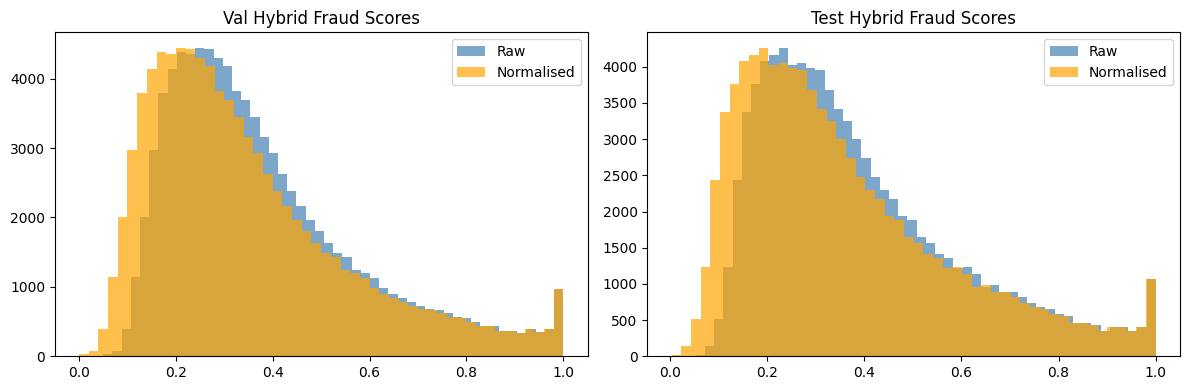

In [25]:
# Fit min-max scaler on VALIDATION hybrid scores only (no test leakage)
# val_probs_raw / test_probs_raw come from the classifier cell above
prob_scaler = MinMaxScaler()
val_probs  = prob_scaler.fit_transform(val_probs_raw.reshape(-1, 1)).flatten()
test_probs = prob_scaler.transform(test_probs_raw.reshape(-1, 1)).flatten()

print(f"Val  scores — min={val_probs.min():.4f}  max={val_probs.max():.4f}  mean={val_probs.mean():.4f}")
print(f"Test scores — min={test_probs.min():.4f}  max={test_probs.max():.4f}  mean={test_probs.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(val_probs_raw, bins=50, color='steelblue', alpha=0.7, label='Raw')
axes[0].hist(val_probs,     bins=50, color='orange',    alpha=0.7, label='Normalised')
axes[0].set_title('Val Hybrid Fraud Scores'); axes[0].legend()
axes[1].hist(test_probs_raw, bins=50, color='steelblue', alpha=0.7, label='Raw')
axes[1].hist(test_probs,     bins=50, color='orange',    alpha=0.7, label='Normalised')
axes[1].set_title('Test Hybrid Fraud Scores'); axes[1].legend()
plt.tight_layout(); plt.show()

## Financial Metrics: Profit Gain (PG) and F-measure

**Profit Gain** (from the paper):

$$PG = \frac{\$_m - \$_{\text{no-fraud-mgmt}}}{\$_{\text{oracle}} - \$_{\text{no-fraud-mgmt}}}$$

* **No-fraud-management** — accept every transaction (maximum fraud loss, zero customer insults).
* **Oracle** — accept every legitimate order, reject every fraud (zero loss everywhere except accepted legitimate profit).
* **F-measure** — computed assuming reviewers are perfect: *review → accept* for legitimate, *review → reject* for fraud.

All review outcomes are computed as **expected values** (not random draws) for reproducible, deterministic evaluation.


## Grid Search Over Thresholds

We sweep a fine grid of (T_low, T_high) pairs, compute the **Profit Gain** on the validation set for each pair, and keep the best. This is the classical optimisation baseline that the RL agent must beat.


In [26]:
# Compute data-calibrated action bounds
MIN_T_LOW, MAX_T_HIGH = compute_action_bounds(
    val_probs, true_val_labels, val_amounts, COST_PARAMS
)
print(f"\nData-calibrated action bounds:")
print(f"  MIN_T_LOW  = {MIN_T_LOW:.3f}  (below this: accepting beats reviewing)")
print(f"  MAX_T_HIGH = {MAX_T_HIGH:.3f}  (above this: rejecting beats reviewing)")

# Sanity check: what fraction of val scores sit outside these bounds?
n_accept_zone = (val_probs < MIN_T_LOW).sum()
n_reject_zone = (val_probs >= MAX_T_HIGH).sum()
n_review_zone = len(val_probs) - n_accept_zone - n_reject_zone
print(f"\nVal score distribution under these bounds:")
print(f"  Accept zone (p < {MIN_T_LOW:.3f}):  {n_accept_zone} ({100*n_accept_zone/len(val_probs):.1f}%)")
print(f"  Review zone:                         {n_review_zone} ({100*n_review_zone/len(val_probs):.1f}%)")
print(f"  Reject zone (p ≥ {MAX_T_HIGH:.3f}): {n_reject_zone} ({100*n_reject_zone/len(val_probs):.1f}%)")

# Run grid search on validation set with data-calibrated bounds
gs_T_low, gs_T_high, gs_results = grid_search_thresholds(
    val_probs, true_val_labels, val_amounts, step=0.01,
    min_t_low=MIN_T_LOW, max_t_high=MAX_T_HIGH
)


Data-calibrated action bounds:
  MIN_T_LOW  = 0.360  (below this: accepting beats reviewing)
  MAX_T_HIGH = 0.980  (above this: rejecting beats reviewing)

Val score distribution under these bounds:
  Accept zone (p < 0.360):  54747 (61.8%)
  Review zone:                         32865 (37.1%)
  Reject zone (p ≥ 0.980): 969 (1.1%)


Grid Search: 100%|██████████| 1953/1953 [01:49<00:00, 17.88it/s]


Grid Search best result (val set):
  T_low  = 0.370  (bounded: [0.360, 0.980])
  T_high = 0.980
  PG     = 0.8900
  F1     = 0.9571


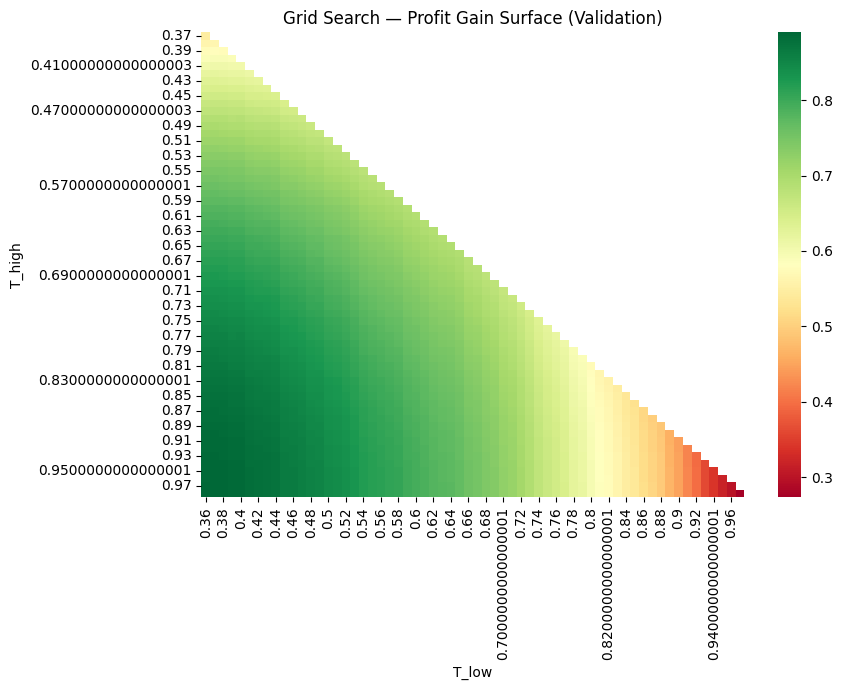

In [27]:
# Visualise the PG surface
pivot = gs_results.pivot_table(values='profit_gain', index='T_high', columns='T_low')
plt.figure(figsize=(9, 7))
sns.heatmap(pivot, annot=False, fmt='.3f', cmap='RdYlGn',
            xticklabels=2, yticklabels=2)
plt.title('Grid Search — Profit Gain Surface (Validation)')
plt.xlabel('T_low');  plt.ylabel('T_high')
plt.tight_layout(); plt.show()


## Review Capacity

In [28]:
# Compute the ACTUAL time span of the test set from TransactionDT (seconds)
# so employee→review-rate is exact, not guessed
# raw_test_df should have TransactionDT
test_dt = raw_test_df['TransactionDT'].values
span_seconds = test_dt.max() - test_dt.min()
span_days = span_seconds / 86400
txns_per_day = len(raw_test_df) / span_days
print(f"Test set spans {span_days:.1f} days ({len(raw_test_df):,} transactions)")
print(f"= {txns_per_day:,.0f} transactions/day")
print(f"\nSo for review capacity:")
for emp in [4, 6, 8, 12, 20]:
    cap = emp * 100  # 100 reviews/employee/day (adjust to realistic)
    rate = cap / txns_per_day
    print(f"  {emp} employees (×100/day) → {cap:,}/day → {100*rate:.1f}% sustainable review rate")

Test set spans 30.8 days (88,581 transactions)
= 2,878 transactions/day

So for review capacity:
  4 employees (×100/day) → 400/day → 13.9% sustainable review rate
  6 employees (×100/day) → 600/day → 20.8% sustainable review rate
  8 employees (×100/day) → 800/day → 27.8% sustainable review rate
  12 employees (×100/day) → 1,200/day → 41.7% sustainable review rate
  20 employees (×100/day) → 2,000/day → 69.5% sustainable review rate


# PPO Threshold Policy — deployed model

One deployed reinforcement-learning policy: an **amount-conditioned PPO agent trained on the batched sequential stream** (a genuine MDP — state evolves with stream position and review pace; reward = realized batch profit). Baselines for comparison: naive 0.5 cut, global grid search, and the amount-bucketed grid.

In [29]:
class ContinuousPPOAgent:
    def __init__(self, state_dim, action_dim=2, lr=3e-4,
                 gamma=0.99, eps_clip=0.15, update_epochs=10,
                 minibatch_size=512, entropy_coef=0.03):
        self.device         = device
        self.gamma          = gamma
        self.eps_clip       = eps_clip
        self.update_epochs  = update_epochs
        self.minibatch_size = minibatch_size
        self.entropy_coef   = entropy_coef

        self.actor = nn.Sequential(
            nn.Linear(state_dim, 256), nn.Tanh(),
            nn.Linear(256, 256),       nn.Tanh(),
            nn.Linear(256, action_dim * 2),
        ).to(self.device)

        self.critic = nn.Sequential(
            nn.Linear(state_dim, 256), nn.Tanh(),
            nn.Linear(256, 256),       nn.Tanh(),
            nn.Linear(256, 1),
        ).to(self.device)

        self.optimizer = optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()), lr=lr
        )

    def get_action(self, state, deterministic=False):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        out     = self.actor(state_t)
        mean, log_std = torch.chunk(out, 2, dim=-1)
        log_std = torch.clamp(log_std, -2, 2)
        std     = log_std.exp()
        dist    = torch.distributions.Normal(mean, std)

        raw_action = mean if deterministic else dist.rsample()
        action_sq  = torch.sigmoid(raw_action)

        log_prob = dist.log_prob(raw_action).sum(-1, keepdim=True)
        log_prob -= torch.log(action_sq * (1 - action_sq) + 1e-6).sum(-1, keepdim=True)

        value = self.critic(state_t)
        # RETURN raw_action as 4th value so update() never has to invert
        return (action_sq.cpu().detach().numpy().flatten(),
                log_prob.cpu().item(),
                value.cpu().detach().item(),
                raw_action.cpu().detach().numpy().flatten())

    def update(self, traj):
        if len(traj['states']) < 2:
            return

        rewards = traj['rewards']; dones = traj['dones']; old_vals = traj['values']

        lam = 0.95; gae = 0.0; advantages = []; next_val = 0.0
        for r, d, v in zip(reversed(rewards), reversed(dones), reversed(old_vals)):
            delta = r + self.gamma * next_val * (1.0 - d) - v
            gae = delta + self.gamma * lam * (1.0 - d) * gae
            advantages.insert(0, gae); next_val = v

        advantages = torch.FloatTensor(advantages).unsqueeze(1).to(self.device)
        values_t   = torch.FloatTensor(np.array(old_vals)).unsqueeze(1).to(self.device)
        returns    = (advantages + values_t).detach()

        states   = torch.FloatTensor(np.array(traj['states'])).to(self.device)
        raw_acts = torch.FloatTensor(np.array(traj['raw_actions'])).to(self.device)  # stored raw
        old_lps  = torch.FloatTensor(traj['log_probs']).unsqueeze(1).to(self.device)

        advantages = ((advantages - advantages.mean()) / (advantages.std() + 1e-8)).detach()

        for _ in range(self.update_epochs):
            idx_perm = torch.randperm(len(states))
            for start in range(0, len(states), self.minibatch_size):
                idx = idx_perm[start:start + self.minibatch_size]
                if len(idx) < 2:
                    continue

                s_b   = states[idx];   raw_b = raw_acts[idx]
                ol_b  = old_lps[idx];  adv_b = advantages[idx];  ret_b = returns[idx]

                out        = self.actor(s_b)
                mu, log_s  = torch.chunk(out, 2, dim=-1)
                log_s      = torch.clamp(log_s, -2, 2)
                dist_b     = torch.distributions.Normal(mu, log_s.exp())

                # use the STORED raw action — no inversion
                new_lp     = dist_b.log_prob(raw_b).sum(-1, keepdim=True)
                a_sq_b     = torch.sigmoid(raw_b)
                new_lp    -= torch.log(a_sq_b * (1 - a_sq_b) + 1e-6).sum(-1, keepdim=True)
                entropy    = dist_b.entropy().sum(-1).mean()

                new_vals   = self.critic(s_b)
                ratio      = torch.exp(new_lp - ol_b.detach())
                surr1      = ratio * adv_b
                surr2      = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * adv_b
                actor_loss = -torch.min(surr1, surr2).mean()

                values_t_b   = values_t[idx]
                vals_clipped = values_t_b + torch.clamp(
                                 new_vals - values_t_b, -self.eps_clip, self.eps_clip)
                critic_loss  = torch.max(F.mse_loss(new_vals, ret_b),
                                         F.mse_loss(vals_clipped, ret_b))

                loss = actor_loss + 0.5 * critic_loss - self.entropy_coef * entropy

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(self.actor.parameters()) + list(self.critic.parameters()), 0.5)
                self.optimizer.step()

    def save(self, path):
        torch.save({'actor': self.actor.state_dict(),
                    'critic': self.critic.state_dict()}, path)

    def load(self, path):
        ckpt = torch.load(path, map_location=self.device)
        self.actor.load_state_dict(ckpt['actor'])
        self.critic.load_state_dict(ckpt['critic'])

## Amount-conditioned PPO — policy classes

`AmountCondAgent` (subclass of `ContinuousPPOAgent`) outputs four scalars — `base_low, slope_low, base_high, slope_high` — defining two thresholds linear in normalized log-amount. `ContinuousAmountEnv` is retained as the evaluation harness used by `_full_eval` (noise-free full-split scoring of a fixed parameter vector).

In [30]:
class ContinuousAmountEnv:
    """Agent outputs 4 params (base_low, slope_low, base_high, slope_high).
       Per-transaction thresholds vary smoothly with normalized log-amount:
         T_low(A)  = base_low  + slope_low  * z(A)
         T_high(A) = base_high + slope_high * z(A)
       Full-set reward (noise-free), same cost function as everything else."""
    def __init__(self, probs, labels, amounts, cp=COST_PARAMS,
                 min_t_low=None, max_t_high=None, episode_len=8):
        self.p = np.asarray(probs, float)
        self.y = np.asarray(labels, int)
        self.A = np.asarray(amounts, float)
        self.cp = cp
        self.MIN_T_LOW  = float(min_t_low)  if min_t_low  is not None else 0.0
        self.MAX_T_HIGH = float(max_t_high) if max_t_high is not None else 1.0
        self.episode_len = episode_len
        # normalized log-amount: z in roughly [-2, 2], 0 at median amount
        logA = np.log1p(self.A)
        self.logA_mean = Z_LOGA_MEAN; self.logA_std = Z_LOGA_STD   # frozen on val (A9)
        self.z = (logA - self.logA_mean) / self.logA_std
        self.A_ref = float(np.median(amounts)); self.A_split = float(np.percentile(amounts,75))
        fa, la = self.A[self.y==1], self.A[self.y==0]
        self._no_fraud = -(cp['flm']*fa.sum() - cp['pr']*la.sum())
        self._oracle   = cp['pr']*la.sum()
        self.reset()

    def reset(self):
        self.step_count = 0
        return self._state()

    def _state(self):
        p, A = self.p, self.A
        return np.array([
            0.0, p.mean(), p.std(), p.min(), p.max(),
            float(np.percentile(p,90)), float(np.percentile(p,95)),
            float((p>0.8).mean()), float(((p>=0.4)&(p<0.8)).mean()),
            float(self.y.mean()), float(A.mean()/self.A_ref),
            float(A.std()/self.A_ref), float((A>self.A_split).mean()),
            float((p*A).sum()/(self.A_ref*len(p))), 0.5, 0.5
        ], dtype=np.float32)

    def step(self, action):
        # action: 4 params already mapped to sensible ranges by the agent
        base_low, slope_low, base_high, slope_high = action
        cp = self.cp
        pr,ltv,flm,rc,prev = cp['pr'],cp['ltv'],cp['flm'],cp['rc'],cp['prev']
        p, A, y, z = self.p, self.A, self.y, self.z

        # per-transaction thresholds (vary with amount via z)
        T_low  = base_low  + slope_low  * z
        T_high = base_high + slope_high * z
        T_low  = np.clip(T_low,  self.MIN_T_LOW, self.MAX_T_HIGH - 0.02)
        T_high = np.clip(T_high, T_low + 0.01,   self.MAX_T_HIGH)

        eff_low = np.minimum(np.maximum(T_low, rc/(flm*A+1e-6)), T_high-0.01)
        d = np.where(p < eff_low, 0, np.where(p < T_high, 2, 1))

        cost = transaction_cost(d, y, A, cp).sum()
        profit = -cost
        pg = (profit - self._no_fraud) / (self._oracle - self._no_fraud + 1e-9)
        reward = float(pg) * 10.0
        self.step_count += 1
        done = self.step_count >= self.episode_len
        return self._state(), reward, done, {'profit': profit, 'review_rate': float((d==2).mean())}

In [31]:
class AmountCondAgent(ContinuousPPOAgent):
    """4-D action: (base_low, slope_low, base_high, slope_high)."""
    def __init__(self, *args, t_lo=0.0, t_hi=1.0, slope_max=0.20, **kwargs):
        kwargs['action_dim'] = 4
        super().__init__(*args, **kwargs)
        self.t_lo=float(t_lo); self.t_hi=float(t_hi); self.slope_max=float(slope_max)

    def _map(self, a_sq):  # a_sq in (0,1)^4
        span = self.t_hi - self.t_lo
        base_low   = self.t_lo + a_sq[...,0]*span*0.6                 # base_low in lower 60% of range
        base_high  = self.t_lo + 0.4*span + a_sq[...,2]*0.6*span      # base_high in upper range
        slope_low  = (a_sq[...,1]*2 - 1) * self.slope_max             # [-slope_max, +slope_max]
        slope_high = (a_sq[...,3]*2 - 1) * self.slope_max
        return torch.stack([base_low, slope_low, base_high, slope_high], dim=-1)

    def get_action(self, state, deterministic=False):
            st = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            out = self.actor(st); mean, log_std = torch.chunk(out, 2, dim=-1)
            log_std = torch.clamp(log_std, -2, 2)
            dist = torch.distributions.Normal(mean, log_std.exp())
            raw = mean if deterministic else dist.rsample()
            a_sq = torch.sigmoid(raw)
            params = self._map(a_sq)
            logp = dist.log_prob(raw).sum(-1, keepdim=True)
            logp -= torch.log(a_sq*(1-a_sq)+1e-6).sum(-1, keepdim=True)
            v = self.critic(st)
            # ALSO return the raw action so update() doesn't have to invert
            return (params.cpu().detach().numpy().flatten(), logp.cpu().item(),
                    v.cpu().detach().item(), raw.cpu().detach().numpy().flatten())

    def update(self, traj):
        if len(traj['states']) < 2: return
        rewards, dones, old_vals = traj['rewards'], traj['dones'], traj['values']
        lam, gae, adv, nv = 0.95, 0.0, [], 0.0
        for r,d,v in zip(reversed(rewards),reversed(dones),reversed(old_vals)):
            delta = r + self.gamma*nv*(1-d) - v
            gae = delta + self.gamma*lam*(1-d)*gae
            adv.insert(0, gae); nv = v
        adv = torch.FloatTensor(adv).unsqueeze(1).to(self.device)
        vals_t = torch.FloatTensor(np.array(old_vals)).unsqueeze(1).to(self.device)
        rets = (adv+vals_t).detach()
        states = torch.FloatTensor(np.array(traj['states'])).to(self.device)
        raw_actions = torch.FloatTensor(np.array(traj['raw_actions'])).to(self.device)
        old_lps = torch.FloatTensor(traj['log_probs']).unsqueeze(1).to(self.device)
        adv = ((adv-adv.mean())/(adv.std()+1e-8)).detach()
        span = self.t_hi - self.t_lo
        for _ in range(self.update_epochs):
            perm = torch.randperm(len(states))
            for s0 in range(0, len(states), self.minibatch_size):
                idx = perm[s0:s0+self.minibatch_size]
                if len(idx) < 2: continue
                s_b = states[idx]; raw_b = raw_actions[idx]   # ← use stored raw
                ol_b, adv_b, ret_b = old_lps[idx], adv[idx], rets[idx]
                # NO inversion — raw_b is the exact action that was taken
                out = self.actor(s_b); mu, ls = torch.chunk(out, 2, dim=-1)
                ls = torch.clamp(ls, -2, 2)
                dist_b = torch.distributions.Normal(mu, ls.exp())
                new_lp = dist_b.log_prob(raw_b).sum(-1, keepdim=True)
                a_sq_b = torch.sigmoid(raw_b)
                new_lp -= torch.log(a_sq_b*(1-a_sq_b)+1e-6).sum(-1, keepdim=True)
                ent = dist_b.entropy().sum(-1).mean()
                nv2 = self.critic(s_b)
                ratio = torch.exp(new_lp - ol_b.detach())
                s1 = ratio*adv_b; s2 = torch.clamp(ratio,1-self.eps_clip,1+self.eps_clip)*adv_b
                aloss = -torch.min(s1,s2).mean()
                vtb = vals_t[idx]; vclip = vtb+torch.clamp(nv2-vtb,-self.eps_clip,self.eps_clip)
                closs = torch.max(F.mse_loss(nv2,ret_b), F.mse_loss(vclip,ret_b))
                loss = aloss + 0.5*closs - self.entropy_coef*ent
                self.optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(self.actor.parameters())+list(self.critic.parameters()), 0.5)
                self.optimizer.step()

def _full_eval(a, pr, lb, am, mlo, mhi, amount_cond):
    if amount_cond:
        e = ContinuousAmountEnv(pr, lb, am, min_t_low=mlo, max_t_high=mhi, episode_len=1)
        e.reset(); _,_,_,info = e.step(a); return info
    m = compute_financial_metrics(pr, lb, am, T_low=a[0], T_high=a[1])
    p = np.asarray(pr,float); rev = float(((p>=a[0])&(p<a[1])).mean())
    return {'profit': m['model_profit'], 'review_rate': rev}


## Batched-stream training — the deployed route

Transactions are processed in chronological mini-batches; the state evolves (fraction through stream, review pace, batch mean score) and reward accrues per batch. The best-validation checkpoint is frozen and used for all evaluation and deployment.

In [32]:
# ════════════════════════════════════════════════════════════════════
# BATCHED FORMULATION — full runnable block
# Progress logs + checkpoint save/load + multi-seed + employee-capacity view.
# Isolated: does NOT touch the verified full-set pipeline.
# ════════════════════════════════════════════════════════════════════


CAB_LEARNING_CURVE = {}  # D6: per-seed [(episode, val_profit, review)] convergence trace

class BatchedStreamEnv:
    """Steps through transactions in TIME ORDER in mini-batches. Reward = batch profit.
    State evolves (fraction through, review budget used, batch mean score)."""
    def __init__(self, probs, labels, amounts, min_t_low, max_t_high,
                 batch_size=512, cp=None, amount_cond=False, slope_max=0.20):
        self.p=np.asarray(probs,float); self.y=np.asarray(labels,int); self.A=np.asarray(amounts,float)
        self.cp=cp or COST_PARAMS; self.MIN_T_LOW=min_t_low; self.MAX_T_HIGH=max_t_high
        self.batch_size=batch_size; self.amount_cond=amount_cond; self.slope_max=slope_max
        self.n=len(self.p)
        logA=np.log1p(self.A); self.z=(logA-Z_LOGA_MEAN)/Z_LOGA_STD   # frozen on val (A9)
        fa,la=self.A[self.y==1],self.A[self.y==0]
        self._no_fraud=-(self.cp['flm']*fa.sum()-self.cp['pr']*la.sum()); self._oracle=self.cp['pr']*la.sum()
        self.n_batches=self.n//batch_size
    def reset(self):
        self.ptr=0; self.budget_used=0.0; self.cum_profit=0.0
        return self._state()
    def _state(self):
        frac=self.ptr/max(1,self.n_batches)
        bmean=self.p[self.ptr*self.batch_size:(self.ptr+1)*self.batch_size].mean() if self.ptr<self.n_batches else 0
        return np.array([frac, self.budget_used/max(1,self.ptr*self.batch_size+1), bmean,
                         0,0,0,0,0,0,0,0,0,0,0,0,0], dtype=np.float32)
    def step(self, action):
        cp=self.cp; pr,ltv,flm,rc,prev=cp['pr'],cp['ltv'],cp['flm'],cp['rc'],cp['prev']
        lo=self.ptr*self.batch_size; hi=min(lo+self.batch_size,self.n)
        p=self.p[lo:hi]; A=self.A[lo:hi]; y=self.y[lo:hi]; z=self.z[lo:hi]
        if self.amount_cond:
            base_low,slope_low,base_high,slope_high=action
            T_low=base_low+slope_low*z; T_high=base_high+slope_high*z
        else:
            T_low=np.full(len(p),action[0]); T_high=np.full(len(p),action[1])
        T_low=np.clip(T_low,self.MIN_T_LOW,self.MAX_T_HIGH-0.02); T_high=np.clip(T_high,T_low+0.01,self.MAX_T_HIGH)
        eff=np.minimum(np.maximum(T_low,rc/(flm*A+1e-6)),T_high-0.01)
        d=np.where(p<eff,0,np.where(p<T_high,2,1))
        cost=transaction_cost(d,y,A,cp).sum()
        batch_profit=-cost; self.cum_profit+=batch_profit; self.budget_used+=(d==2).sum()
        self.ptr+=1; done=self.ptr>=self.n_batches
        return self._state(), float(batch_profit/1000.0), done, {'cum_profit':self.cum_profit}

def train_amount_batched(vprobs, tprobs, mlo, mhi, amount_cond, seed=42, n_episodes=4000,
                     batch_size=512, log_every=200, checkpoint_path=None, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    try: torch.mps.manual_seed(seed)
    except Exception: pass
    assert amount_cond, "batched trainer supports only the amount-conditioned agent"
    agent = AmountCondAgent(16, minibatch_size=128, gamma=0.99, entropy_coef=0.02, lr=2e-4,
                            t_lo=mlo, t_hi=mhi, slope_max=0.20)
    env = BatchedStreamEnv(vprobs, true_val_labels, val_amounts, mlo, mhi,
                             batch_size=batch_size, amount_cond=amount_cond)
    best_val, best_a = -np.inf, None
    CAB_LEARNING_CURVE[seed] = []   # D6
    reward_ema = 0.0   # ← persistent running reward, survives traj resets
    traj={k:[] for k in ('states','raw_actions','log_probs','rewards','dones','values')}
    for ep in range(1,n_episodes+1):
        s=env.reset(); done=False; ep_rewards=[]
        while not done:
            a, lp, v, raw = agent.get_action(s)
            ns, r, done, _ = env.step(a)
            for k,val in zip(('states','raw_actions','log_probs','rewards','dones','values'),
                             (s, raw, lp, r, float(done), v)):
                traj[k].append(val)
            ep_rewards.append(r); s=ns
        reward_ema = 0.99*reward_ema + 0.01*np.sum(ep_rewards)   # ← EMA of episode total reward
        if ep%5==0: agent.update(traj); traj={k:[] for k in traj}
        if ep%log_every==0:
            st=env.reset(); a,_,_,_=agent.get_action(st,deterministic=True)
            info=_full_eval(a, vprobs, true_val_labels, val_amounts, mlo, mhi, amount_cond)
            CAB_LEARNING_CURVE[seed].append((ep, float(info['profit']), float(info['review_rate'])))   # D6
            improved=""
            if info['profit']>best_val:
                best_val,best_a=info['profit'],(a.copy() if hasattr(a,'copy') else np.array(a))
                improved=" *"
                if checkpoint_path is not None:           # SAVE on new best (params + agent weights)
                    np.save(f"{checkpoint_path}_params.npy", np.asarray(best_a))
                    agent.save(f"{checkpoint_path}.pt")   # D7: persist best-agent weights for rollout
            if verbose:
                print(f"  ep {ep:5d}/{n_episodes} | val=${info['profit']:>9,.0f} | best=${best_val:>9,.0f} | "
                      f"review={100*info['review_rate']:.1f}% | recent_r={reward_ema:+.3f} | "
                      f"a={np.round(a,3)}{improved}")
    ti=_full_eval(best_a, tprobs, true_test_labels, test_amounts, mlo, mhi, amount_cond)
    vi=_full_eval(best_a, vprobs, true_val_labels, val_amounts, mlo, mhi, amount_cond)
    if checkpoint_path is not None:
        np.save(f"{checkpoint_path}_params.npy", np.asarray(best_a))   # final save
    return best_a, vi['profit'], ti

def load_batched_policy(checkpoint_path):
    """Reload learned params WITHOUT retraining"""
    return np.load(f"{checkpoint_path}_params.npy")

In [33]:
# ── helper: persist a seed's in-memory learning curve to disk ──
def _save_curve(seed, checkpoint_path):
    """Write CAB_LEARNING_CURVE[seed] -> {path}_curve.npy  as (n_logs, 3): ep, val_profit, review."""
    c = CAB_LEARNING_CURVE.get(seed, [])
    if len(c) > 0:
        np.save(f"{checkpoint_path}_curve.npy", np.asarray(c, dtype=float))

# ── PPO amount-continuous (batched): seed-42 point estimate ──
cab42_path = f'{PPO_DIR}/seq_amountcont_seed42_params.npy'
if TRAIN_CAB_SEED or not os.path.exists(cab42_path):
    cab_a4, _, ti = train_amount_batched(val_probs, test_probs, MIN_T_LOW, MAX_T_HIGH,
                                            amount_cond=True, seed=42, n_episodes=4000,
                                            checkpoint_path=f'{PPO_DIR}/seq_amountcont_seed42', verbose=False)
    _save_curve(42, f'{PPO_DIR}/seq_amountcont_seed42')          # NEW: persist convergence trace
    src = "trained"
else:
    cab_a4 = np.load(cab42_path)
    ti = _full_eval(cab_a4, test_probs, true_test_labels, test_amounts,
                    MIN_T_LOW, MAX_T_HIGH, amount_cond=True)
    src = "loaded"

_vi = _full_eval(cab_a4, val_probs, true_val_labels, val_amounts,
                 MIN_T_LOW, MAX_T_HIGH, amount_cond=True)
print(f"Batched {src}: val=${_vi['profit']:,.0f} | test=${ti['profit']:,.0f} | "
      f"review={100*ti['review_rate']:.1f}% | slope_low={cab_a4[1]:+.3f}")

# ── multi-seed robustness (optional) ──
CAB_SEEDS = [1, 2, 3, 42, 7]
if TRAIN_CAB_MULTI:
    cab_res = []
    for sd in CAB_SEEDS:
        a, _, t = train_amount_batched(val_probs, test_probs, MIN_T_LOW, MAX_T_HIGH,
                                          amount_cond=True, seed=sd, n_episodes=4000,
                                          checkpoint_path=f'{PPO_DIR}/seq_amountcont_seed{sd}', verbose=False)
        _save_curve(sd, f'{PPO_DIR}/seq_amountcont_seed{sd}')    # NEW: persist each seed's trace
        print(f"  seed {sd} | test=${t['profit']:,.0f} | review={100*t['review_rate']:.1f}% | slope_low={a[1]:+.3f}")
        cab_res.append({'seed': sd, 'test': t['profit'], 'review': t['review_rate']})
    cab_df = pd.DataFrame(cab_res)
    print(f"Batched multi-seed: ${cab_df['test'].mean():,.0f} ± ${cab_df['test'].std():,.0f}")
elif all(os.path.exists(f'{PPO_DIR}/seq_amountcont_seed{sd}_params.npy') for sd in CAB_SEEDS):
    cab_res = [{'seed': sd, 'test': _full_eval(np.load(f'{PPO_DIR}/seq_amountcont_seed{sd}_params.npy'),
               test_probs, true_test_labels, test_amounts, MIN_T_LOW, MAX_T_HIGH, True)['profit']}
               for sd in CAB_SEEDS]
    cab_df = pd.DataFrame(cab_res)
    print(f"Batched multi-seed (loaded): ${cab_df['test'].mean():,.0f} ± ${cab_df['test'].std():,.0f}")
else:
    print("Batched multi-seed: skipped (set TRAIN_CAB_MULTI=True)")

Batched trained: val=$80,103 | test=$67,530 | review=26.9% | slope_low=-0.178
  seed 1 | test=$67,125 | review=27.6% | slope_low=-0.200
  seed 2 | test=$68,249 | review=27.2% | slope_low=-0.198
  seed 3 | test=$68,167 | review=26.9% | slope_low=-0.194
  seed 42 | test=$67,530 | review=26.9% | slope_low=-0.178
  seed 7 | test=$68,120 | review=27.8% | slope_low=-0.162
Batched multi-seed: $67,838 ± $490


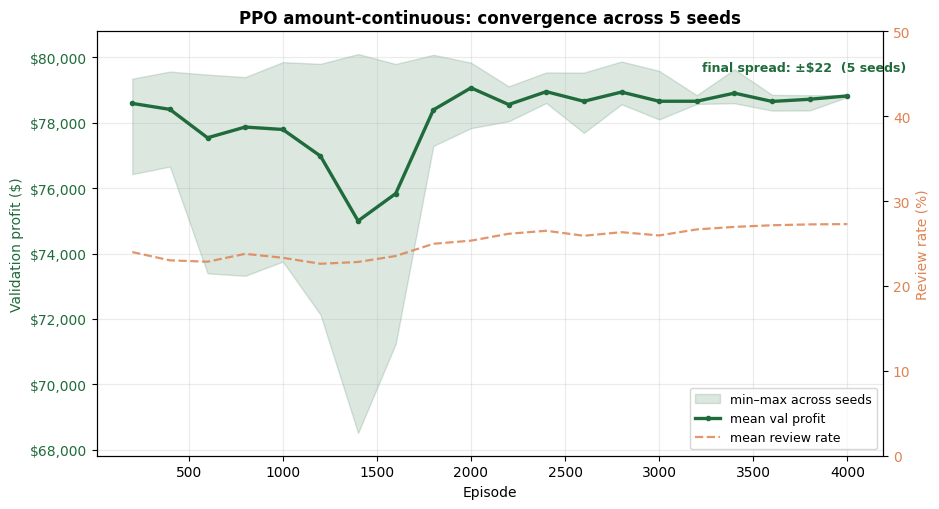

In [34]:
# ── PPO convergence plot: validation profit (+ running-best) and review rate ──
# Auto-detects: ≥2 seed curves -> multi-seed mean + min–max band; 1 curve -> single-seed.
# Plots VALIDATION PROFIT (dollars), not reward.
import os
import numpy as np
import matplotlib.pyplot as plt

SHOW_SEED_LINES = False   # min–max band already shows the extremes; flip True only if you want the raw spaghetti too

def load_learning_curve(checkpoint_path, seed=None):
    p = f"{checkpoint_path}_curve.npy"
    if os.path.exists(p):
        arr = np.load(p)
        if arr.ndim == 2 and arr.shape[0] > 0:
            return arr[:, 0], arr[:, 1], arr[:, 2]
    if seed is not None and len(CAB_LEARNING_CURVE.get(seed, [])) > 0:
        arr = np.asarray(CAB_LEARNING_CURVE[seed], dtype=float)
        return arr[:, 0], arr[:, 1], arr[:, 2]
    return None

curves = {}
for sd in CAB_SEEDS:
    c = load_learning_curve(f'{PPO_DIR}/seq_amountcont_seed{sd}', seed=sd)
    if c is not None:
        curves[sd] = c

C_PROFIT, C_REV = '#1F6B3B', '#DD8452'

if not curves:
    print("No learning curves found. Retrain with the curve-saving cell "
          "(TRAIN_CAB_SEED=True, or TRAIN_CAB_MULTI=True for the band).")

else:
    fig, ax1 = plt.subplots(figsize=(9.5, 5.2))
    ax2 = ax1.twinx()

    if len(curves) >= 2:
        # ---- MULTI-SEED: band across seeds, no spaghetti, no fake "running best" ----
        common_ep = sorted(set.intersection(*[set(c[0].astype(int)) for c in curves.values()]))
        if len(common_ep) >= 2:
            common_ep = np.array(common_ep, dtype=float)
            P, R = [], []
            for ep, prof, rev in curves.values():
                idx = {int(e): i for i, e in enumerate(ep)}
                P.append([prof[idx[int(e)]] for e in common_ep])
                R.append([rev[idx[int(e)]]  for e in common_ep])
            P, R = np.array(P), np.array(R)

            if SHOW_SEED_LINES:
                for row in P:
                    ax1.plot(common_ep, row, color=C_PROFIT, lw=0.7, alpha=0.22)

            ax1.fill_between(common_ep, P.min(0), P.max(0), color=C_PROFIT, alpha=0.16,
                             label='min–max across seeds')
            ax1.plot(common_ep, P.mean(0), color=C_PROFIT, lw=2.4, marker='o', ms=3,
                     label='mean val profit')
            ax2.plot(common_ep, 100 * R.mean(0), color=C_REV, lw=1.6, ls='--',
                     alpha=0.85, label='mean review rate')
            ax2.set_ylim(0, max(50, 100 * R.mean(0).max() * 1.1))

            # gentle y-padding so the band doesn't touch the frame
            band_pad = 0.06 * (P.max() - P.min())
            ax1.set_ylim(P.min() - band_pad, P.max() + band_pad)

            # final-spread label: small offset, NO arrow line crossing the plot
            _final = P[:, -1]
            ax1.annotate(f"final spread: ±${_final.std():,.0f}  ({len(curves)} seeds)",
                         xy=(common_ep[-1], P.mean(0)[-1]),
                         xytext=(-105, 18), textcoords='offset points',
                         fontsize=9, fontweight='bold', color=C_PROFIT)

            ax1.set_title(f'PPO amount-continuous: convergence across {len(curves)} seeds',
                          fontweight='bold')
        else:
            print("Seeds logged at non-overlapping episodes; plotting seed 42 only.")
            curves = {42: curves.get(42, next(iter(curves.values())))}

    if len(curves) == 1:
        # ---- SINGLE-SEED: raw trace + running-best, with HONEST axis padding ----
        sd = next(iter(curves))
        ep, prof, rev = curves[sd]

        ax1.plot(ep, prof, color=C_PROFIT, lw=1.4, marker='o', ms=3, alpha=0.5,
                 label=f'val profit (seed {sd})')
        running_best = np.maximum.accumulate(prof)
        ax1.plot(ep, running_best, color=C_PROFIT, lw=2.4, label='running best (deployed)')

        bi = int(np.argmax(prof))
        ax1.scatter([ep[bi]], [prof[bi]], color=C_PROFIT, s=90, zorder=5,
                    edgecolor='white', linewidth=1.2)
        ax1.annotate(f"best ${prof[bi]:,.0f} @ ep {int(ep[bi])}",
                     xy=(ep[bi], prof[bi]), xytext=(12, 14), textcoords='offset points',
                     fontsize=9, fontweight='bold', color=C_PROFIT)

        # ---- the fix: pad the y-axis so a small % swing doesn't look like a cliff ----
        rng = prof.max() - prof.min()
        pad = max(rng * 0.6, 0.015 * np.mean(prof))
        ax1.set_ylim(prof.min() - pad, prof.max() + pad)
        ax1.text(0.02, 0.04,
                  f"swing across training ≈ {100*rng/np.mean(prof):.1f}% of mean profit",
                  transform=ax1.transAxes, fontsize=8.5, style='italic', color=C_PROFIT)

        ax2.plot(ep, 100 * rev, color=C_REV, lw=1.6, ls='--', alpha=0.85, label='review rate')
        ax2.set_ylim(0, max(50, 100 * rev.max() * 1.1))
        ax1.set_title(f'PPO amount-continuous (seed {sd}): convergence on validation',
                      fontweight='bold')

    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Validation profit ($)', color=C_PROFIT)
    ax1.tick_params(axis='y', labelcolor=C_PROFIT)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax1.grid(alpha=0.25)
    ax2.set_ylabel('Review rate (%)', color=C_REV)
    ax2.tick_params(axis='y', labelcolor=C_REV)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{PPO_DIR}/ppo_convergence.png', dpi=200, bbox_inches='tight')
    plt.show()

### What the batched-stream route is (and is not)

The batched env trains on the time-ordered stream in mini-batches with an evolving state (progress, review-budget used, batch-mean score) and a per-batch reward. **But the reported policy is the deterministic action at the *reset* state, applied globally** — a *static* amount-conditioned policy `(base_low, slope_low, base_high, slope_high)`, the same four-parameter form as the full-set route. So "batched" is an **optimisation route** that yields a slightly better, lower-variance, more drift-robust static policy — **not** a deployment-time adaptive controller. The **D7** cell below tests directly whether an *adaptive rollout* (re-picking thresholds each batch) beats this static extraction; it ties, so the policy is reported as static.

In [35]:
# ════════════════════════════════════════════════════════════════════
# EMPLOYEE-CAPACITY VIEW (uses your real 30.8-day span = 2,878 txns/day)
# ════════════════════════════════════════════════════════════════════
TXNS_PER_DAY = len(raw_test_df) / ((raw_test_df['TransactionDT'].max()-raw_test_df['TransactionDT'].min())/86400)
REVIEWS_PER_EMPLOYEE_PER_DAY = 100   # ASSUMPTION — cite a realistic figure / label illustrative
print(f"\nEmployee capacity (real span: {TXNS_PER_DAY:,.0f} txns/day, {REVIEWS_PER_EMPLOYEE_PER_DAY}/analyst/day):")
if 'cab_df' in globals():
    best = cab_df.loc[cab_df['test'].idxmax()]
    policy_review = float(best['review'])
else:
    # multi-seed table not built this run -> fall back to the seed-42 point estimate
    _info = _full_eval(cab_a4, test_probs, true_test_labels, test_amounts,
                       MIN_T_LOW, MAX_T_HIGH, amount_cond=True)
    policy_review = float(_info['review_rate'])
reviews_needed_per_day = TXNS_PER_DAY * policy_review
analysts_needed = reviews_needed_per_day / REVIEWS_PER_EMPLOYEE_PER_DAY
print(f"  Your amount-policy reviews {100*policy_review:.1f}% → {reviews_needed_per_day:,.0f} reviews/day "
      f"→ needs ~{analysts_needed:.1f} analysts")
for emp in [4,6,8,12,20]:
    rate = emp*REVIEWS_PER_EMPLOYEE_PER_DAY/TXNS_PER_DAY
    fits = "✓ fits your policy" if rate>=policy_review else "✗ below policy's review rate"
    print(f"  {emp:2d} analysts → {100*rate:.1f}% sustainable  {fits}")


Employee capacity (real span: 2,878 txns/day, 100/analyst/day):
  Your amount-policy reviews 27.2% → 781 reviews/day → needs ~7.8 analysts
   4 analysts → 13.9% sustainable  ✗ below policy's review rate
   6 analysts → 20.8% sustainable  ✗ below policy's review rate
   8 analysts → 27.8% sustainable  ✓ fits your policy
  12 analysts → 41.7% sustainable  ✓ fits your policy
  20 analysts → 69.5% sustainable  ✓ fits your policy


### Batched-stream amount-continuous: negative control (leak test)

Re-trains the batched policy on **shuffled** labels with identical hyperparameters. If the pipeline leaked test information, the shuffled policy would still score on test; it collapses instead, confirming the training is test-blind.

In [36]:
# ════════════════════════════════════════════════════════════════════
# NEGATIVE CONTROL — batched amount-continuous
# Reuses the already-trained REAL seed-42 policy (loaded, not retrained);
# only the SHUFFLED-label policy is trained here (irreducible — it's the
# whole point of the control). Identical params real-vs-shuffled proves
# training is test-blind; shuffled-test collapse proves real-fraud dependence.
# ════════════════════════════════════════════════════════════════════
if RUN_DRIFT_DIAGNOSTICS:
    print("BATCHED negative control (does the batched version leak test?)\n")

    # --- REAL: load the already-trained seed-42 policy (no retrain) ---
    a_real = np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')
    ti_real = _full_eval(a_real, test_probs, true_test_labels, test_amounts,
                        MIN_T_LOW, MAX_T_HIGH, amount_cond=True)
    vi_real = _full_eval(a_real, val_probs, true_val_labels, val_amounts,
                        MIN_T_LOW, MAX_T_HIGH, amount_cond=True)

    # --- SHUFFLED: must train (the control's whole point) ---
    true_test_BACKUP = true_test_labels.copy()
    rng = np.random.default_rng(0)
    shuffled = true_test_labels.copy(); rng.shuffle(shuffled)
    true_test_labels = shuffled
    a_shuf, vp_shuf, ti_shuf = train_amount_batched(
        val_probs, test_probs, MIN_T_LOW, MAX_T_HIGH, amount_cond=True,
        seed=42, n_episodes=4000, checkpoint_path=None, verbose=False)
    true_test_labels = true_test_BACKUP   # restore immediately

    print(f"Params REAL (loaded):   {np.round(a_real,4)}")
    print(f"Params SHUFFLED (trained): {np.round(a_shuf,4)}")
    print(f"  → must be IDENTICAL (training uses val only; test labels never touch training)\n")
    print(f"Val profit:  REAL ${vi_real['profit']:,.0f}  vs  SHUFFLED ${vp_shuf:,.0f}   (must match)")
    print(f"Test profit: REAL ${ti_real['profit']:,.0f}  vs  SHUFFLED ${ti_shuf['profit']:,.0f}\n")

    params_identical = np.allclose(a_real, a_shuf, atol=1e-4)
    shuffled_collapses = ti_shuf['profit'] < ti_real['profit'] * 0.3
    print("VERDICT:")
    print(f"  Params identical real-vs-shuffled: {params_identical}  "
        f"{'✓' if params_identical else '🚩 LEAK — test influenced training'}")
    print(f"  Shuffled test collapses:           {shuffled_collapses}  "
        f"{'✓' if shuffled_collapses else '🚩 policy works on noise — suspicious'}")
else:
    print("Batched negative control: skipped (set RUN_DRIFT_DIAGNOSTICS=True to run)")
    print("  Last verified clean: params identical, shuffled test collapsed to -$498,948")

BATCHED negative control (does the batched version leak test?)

Params REAL (loaded):   [ 0.4086 -0.1776  0.9383  0.197 ]
Params SHUFFLED (trained): [ 0.4086 -0.1776  0.9383  0.197 ]
  → must be IDENTICAL (training uses val only; test labels never touch training)

Val profit:  REAL $80,103  vs  SHUFFLED $80,103   (must match)
Test profit: REAL $67,530  vs  SHUFFLED $-495,472

VERDICT:
  Params identical real-vs-shuffled: True  ✓
  Shuffled test collapses:           True  ✓


# Amount-Bucketed Grid Search

In [37]:
# ════════════════════════════════════════════════════════════════════
# AMOUNT-BUCKETED GRID SEARCH — the fair non-RL competitor to the
# amount-conditioned policy. Splits transactions into log-amount quartiles,
# finds the best fixed (T_low, T_high) PER bucket on VALIDATION, applies to
# test. This is the piecewise-constant version of the linear amount policy.
#   • If PPO amount-policy beats this → the LEARNED CONTINUOUS conditioning is
#     the contribution.
#   • If they tie → amount-conditioning ITSELF is what matters (simple bucketing
#     captures it); PPO learns it smoothly. Either result is honest & reportable.
# Bucket edges chosen on TRAIN/VAL amounts only (no test leakage).
# ════════════════════════════════════════════════════════════════════

# Bucket edges from VALIDATION log-amounts (quartiles) — never uses test
val_logA  = np.log1p(np.asarray(val_amounts, float))
test_logA = np.log1p(np.asarray(test_amounts, float))
edges = np.quantile(val_logA, [0.25, 0.50, 0.75])   # 4 buckets
def bucket_of(logA): return np.digitize(logA, edges)  # 0,1,2,3
val_b  = bucket_of(val_logA)
test_b = bucket_of(test_logA)

print("AMOUNT-BUCKETED GRID SEARCH (4 log-amount quartiles)\n")
print(f"Bucket edges (val log-amount quartiles): {np.round(edges,3)}")
print(f"Bucket $ ranges (approx): "
      f"≤${np.expm1(edges[0]):.0f} | ${np.expm1(edges[0]):.0f}-{np.expm1(edges[1]):.0f} | "
      f"${np.expm1(edges[1]):.0f}-{np.expm1(edges[2]):.0f} | >${np.expm1(edges[2]):.0f}\n")

# For each bucket: grid-search best (T_low,T_high) on VAL subset, apply to TEST subset
bucket_thresholds = {}
test_decisions = np.full(len(test_probs), -1, dtype=int)  # 0=acc,1=rej,2=rev
for b in range(4):
    vm = (val_b == b); tm = (test_b == b)
    # grid search on this bucket's VALIDATION transactions only
    tl, th, _ = grid_search_thresholds(
        val_probs[vm], np.asarray(true_val_labels)[vm], np.asarray(val_amounts)[vm],
        min_t_low=MIN_T_LOW, max_t_high=MAX_T_HIGH, verbose=False)
    bucket_thresholds[b] = (tl, th)
    # apply to this bucket's TEST transactions (same amount-aware floor as every other method; A10)
    pb = test_probs[tm]; Ab = np.asarray(test_amounts, float)[tm]
    rc_, flm_ = COST_PARAMS['rc'], COST_PARAMS['flm']
    eff = np.minimum(np.maximum(tl, rc_ / (flm_ * Ab + 1e-6)), th - 0.01)
    test_decisions[tm] = np.where(pb < eff, 0, np.where(pb < th, 2, 1))
    print(f"  Bucket {b}: T=({tl:.3f},{th:.3f})  "
          f"(n_val={vm.sum():,}, n_test={tm.sum():,})")

# Compute test profit from the per-bucket decisions
def profit_from_decisions(d, probs, labels, amounts, cp=COST_PARAMS):
    pr,ltv,flm,rc,prev = cp['pr'],cp['ltv'],cp['flm'],cp['rc'],cp['prev']
    A=np.asarray(amounts,float); y=np.asarray(labels,int)
    cost = transaction_cost(d, y, A, cp).sum()
    profit=-cost
    fa,la=A[y==1],A[y==0]; no_fraud=-(flm*fa.sum()-pr*la.sum()); oracle=pr*la.sum()
    pg=(profit-no_fraud)/(oracle-no_fraud)
    return profit, pg, float((d==2).mean())

bucket_profit, bucket_pg, bucket_rev = profit_from_decisions(
    test_decisions, test_probs, true_test_labels, test_amounts)

# Global grid search (single threshold pair) for reference
gtl, gth, _ = grid_search_thresholds(val_probs, true_val_labels, val_amounts,
                                     min_t_low=MIN_T_LOW, max_t_high=MAX_T_HIGH, verbose=False)
gm = compute_financial_metrics(test_probs, true_test_labels, test_amounts, T_low=gtl, T_high=gth)
g_rev = float(((np.asarray(test_probs)>=gtl)&(np.asarray(test_probs)<gth)).mean())

print(f"\n{'='*60}")
print(f"{'Method':<34}{'test profit':>14}{'PG':>8}{'review':>9}")
print(f"{'-'*60}")
print(f"{'Global grid search (1 threshold pair)':<34}${gm['model_profit']:>12,.0f}{gm['profit_gain']:>8.3f}{100*g_rev:>8.1f}%")
print(f"{'Amount-BUCKETED grid (4 buckets)':<34}${bucket_profit:>12,.0f}{bucket_pg:>8.3f}{100*bucket_rev:>8.1f}%")
print(f"{'PPO amount-continuous (your policy)':<34}{'~$66-68k':>13}{'~0.88':>8}{'~27':>8}%")
print(f"{'='*60}")
print(f"\nINTERPRETATION:")
print(f"  • Bucketed > global grid → amount-conditioning helps (expected).")
print(f"  • PPO amount-continuous > bucketed → the LEARNED CONTINUOUS policy adds")
print(f"    value beyond simple bucketing = your contribution is the smooth learned conditioning.")
print(f"  • PPO ≈ bucketed → amount-conditioning itself is the win; PPO learns it")
print(f"    smoothly without hand-picked buckets (still a valid, honest framing).")

AMOUNT-BUCKETED GRID SEARCH (4 log-amount quartiles)

Bucket edges (val log-amount quartiles): [3.806 4.233 4.771]
Bucket $ ranges (approx): ≤$44 | $44-68 | $68-117 | >$117

  Bucket 0: T=(0.620,0.630)  (n_val=22,126, n_test=21,982)
  Bucket 1: T=(0.490,0.920)  (n_val=21,523, n_test=21,301)
  Bucket 2: T=(0.410,0.980)  (n_val=18,247, n_test=18,541)
  Bucket 3: T=(0.370,0.980)  (n_val=26,685, n_test=26,757)

Method                               test profit      PG   review
------------------------------------------------------------
Global grid search (1 threshold pair)$      49,020   0.869    37.3%
Amount-BUCKETED grid (4 buckets)  $      60,257   0.877    24.3%
PPO amount-continuous (your policy)     ~$66-68k   ~0.88     ~27%

INTERPRETATION:
  • Bucketed > global grid → amount-conditioning helps (expected).
  • PPO amount-continuous > bucketed → the LEARNED CONTINUOUS policy adds
    value beyond simple bucketing = your contribution is the smooth learned conditioning.
  • PPO ≈ bucke

# Full Comparison: Profit Gain & F-measure on the Test Set


COMPARISON TABLE (Test Set, seed 42)   [F1(auto)=model alone | F1(post)=with perfect review]
                          Method    PG Test Profit Review% Rec(auto) Prec(auto) F1(auto) F1(post)
        Classifier @ 0.5 (naive) 0.597   $-334,495    0.9%     0.864      0.131    0.228    0.229
             Grid search (fixed) 0.869     $49,020   37.2%     0.815      0.850    0.832    0.940
Amount-bucketed grid (4 buckets) 0.877     $60,257   24.3%     0.788      0.351    0.486    0.642
 PPO amount-continuous (batched) 0.882     $67,530   26.9%     0.786      0.474    0.591    0.737

-- Dual-metric (batched headline policy) --
  (A) post-review  [review = oracle-correct]: P=0.636 R=0.877 F1=0.737
  (B) automated-only [review = abstain; on 73% auto-decided]: P=0.474 R=0.786 F1=0.591
  Fraud disposition (of 3083): auto-reject 45.2% | sent-to-review 42.5% | auto-accepted/MISSED 12.3%
  -> (A) recall credits the 42.5% review-caught frauds to perfect analysts; the model itself auto-blocks 45.2% a

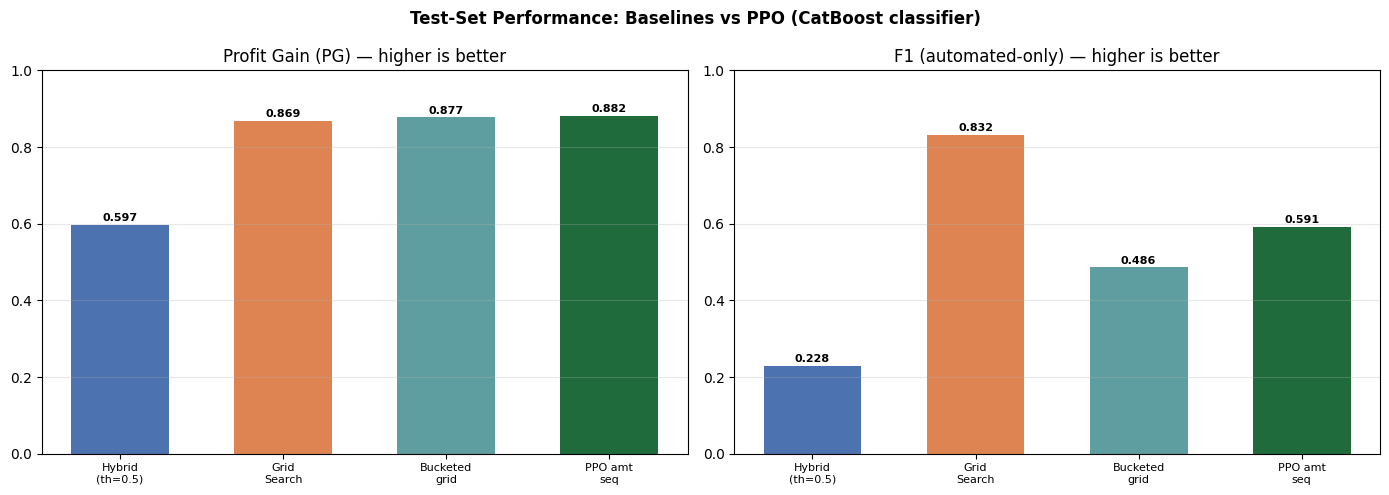

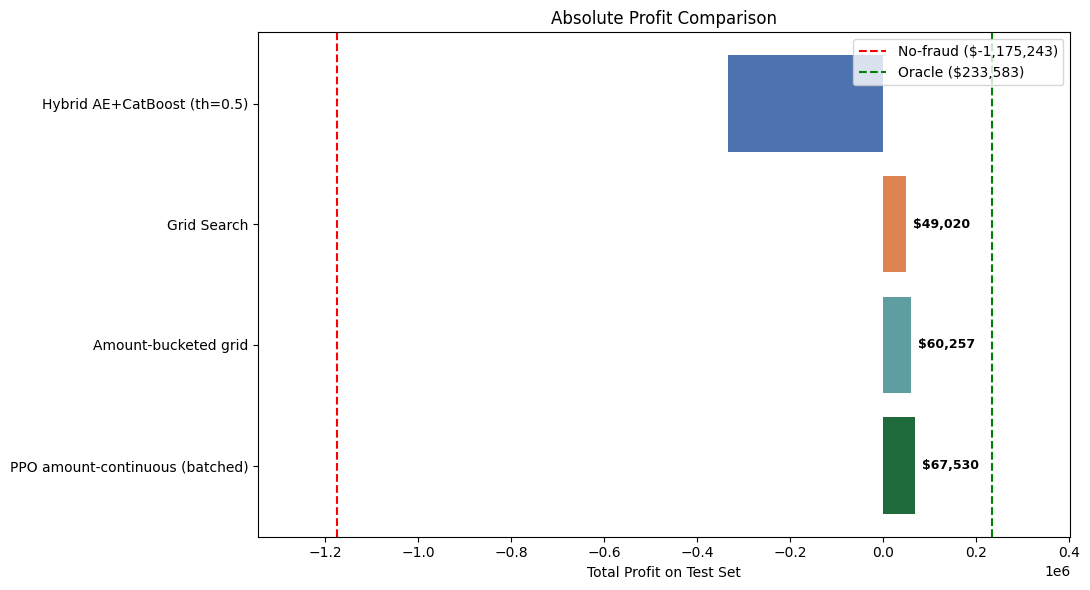

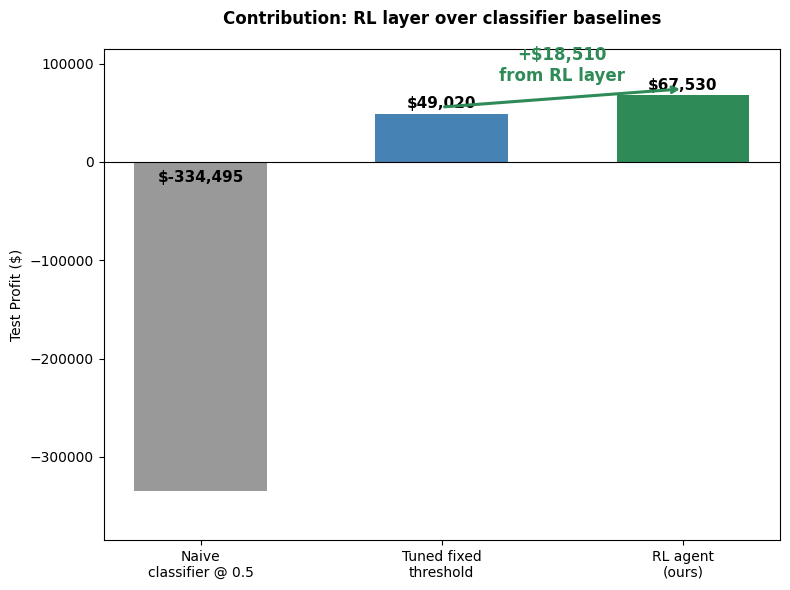

In [74]:
# ════════════════════════════════════════════════════════════════════
# FINAL COMPARISON (Test Set) — 4 methods, CatBoost-native classifier
# ════════════════════════════════════════════════════════════════════

# --- baseline + grid + single-threshold ---
naive_metrics = compute_financial_metrics(test_probs, true_test_labels, test_amounts, T_low=0.5, T_high=0.5)
gs_metrics = compute_financial_metrics(test_probs, true_test_labels, test_amounts, T_low=gs_T_low, T_high=gs_T_high)

# --- amount-continuous metrics (reconstruct decisions from 4 params) ---
def amountcond_metrics(a4, probs, labels, amounts, cp=COST_PARAMS):
    pr,ltv,flm,rc,prev = cp['pr'],cp['ltv'],cp['flm'],cp['rc'],cp['prev']
    p=np.asarray(probs,float); A=np.asarray(amounts,float); y=np.asarray(labels,int)
    base_low,slope_low,base_high,slope_high = a4
    logA=np.log1p(A); z=(logA-Z_LOGA_MEAN)/Z_LOGA_STD   # frozen on val (A9)
    T_low=base_low+slope_low*z; T_high=base_high+slope_high*z
    T_low=np.clip(T_low,MIN_T_LOW,MAX_T_HIGH-0.02); T_high=np.clip(T_high,T_low+0.01,MAX_T_HIGH)
    eff=np.minimum(np.maximum(T_low,rc/(flm*A+1e-6)),T_high-0.01)
    d=np.where(p<eff,0,np.where(p<T_high,2,1))
    cost=transaction_cost(d,y,A,cp).sum()
    profit=-cost; fa,la=A[y==1],A[y==0]; no_fraud=-(flm*fa.sum()-pr*la.sum()); oracle=pr*la.sum()
    pg=(profit-no_fraud)/(oracle-no_fraud) if oracle!=no_fraud else 0
    yp=np.where(d==0,0,np.where(d==1,1,y))
    return dict(T_low=np.nan,T_high=np.nan,profit_gain=pg,f1=f1_score(y,yp,zero_division=0),
                precision=precision_score(y,yp,zero_division=0),recall=recall_score(y,yp,zero_division=0),
                model_profit=profit,no_fraud_profit=no_fraud,oracle_profit=oracle,
                review_rate=float((d==2).mean()),decisions=d)

# --- metrics from a precomputed decision vector (for bucketed grid) ---
def metrics_from_decisions(d, probs, labels, amounts, cp=COST_PARAMS):
    pr,ltv,flm,rc,prev = cp['pr'],cp['ltv'],cp['flm'],cp['rc'],cp['prev']
    A=np.asarray(amounts,float); y=np.asarray(labels,int)
    cost=transaction_cost(d,y,A,cp).sum()
    profit=-cost; fa,la=A[y==1],A[y==0]; no_fraud=-(flm*fa.sum()-pr*la.sum()); oracle=pr*la.sum()
    pg=(profit-no_fraud)/(oracle-no_fraud) if oracle!=no_fraud else 0
    yp=np.where(d==0,0,np.where(d==1,1,y))
    return dict(T_low=np.nan,T_high=np.nan,profit_gain=pg,f1=f1_score(y,yp,zero_division=0),
                precision=precision_score(y,yp,zero_division=0),recall=recall_score(y,yp,zero_division=0),
                model_profit=profit,no_fraud_profit=no_fraud,oracle_profit=oracle,
                review_rate=float((d==2).mean()),decisions=d)

bg_metrics  = metrics_from_decisions(test_decisions, test_probs, true_test_labels, test_amounts)  # bucketed grid (needs bucket cell run)
cab_a4      = np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')
cab_metrics = amountcond_metrics(cab_a4, test_probs, true_test_labels, test_amounts)           # batched, seed 42

order = [naive_metrics, gs_metrics, bg_metrics, cab_metrics]   # 4 surviving methods (plot order)

# --- comparable comparison table -------------------------------------------------
# The single-number F1 is NOT comparable across methods (review credited as oracle-
# correct rewards methods that auto-reject less). Report two views per method:
#   F1(auto) : review = abstain; P/R/F1 on the auto-decided subset = model's standalone skill
#   F1(post) : review = oracle-correct (perfect analyst) = operational upper bound
_yt = np.asarray(true_test_labels, int)
def _auto_view(d):
    d = np.asarray(d, int); auto = d != 2
    yp = (d[auto] == 1).astype(int)
    return {'f1': f1_score(_yt[auto], yp, zero_division=0),
            'precision': precision_score(_yt[auto], yp, zero_division=0),
            'recall': recall_score(_yt[auto], yp, zero_division=0)}

_methods = [
    ('Classifier @ 0.5 (naive)',            naive_metrics),
    ('Grid search (fixed)',                 gs_metrics),
    ('Amount-bucketed grid (4 buckets)',    bg_metrics),
    ('PPO amount-continuous (batched)',  cab_metrics),
]
_rows = []
for _name, _m in _methods:
    _d = np.asarray(_m['decisions'], int); _av = _auto_view(_d)
    _rows.append({'Method': _name, 'PG': _m['profit_gain'], 'Test Profit': _m['model_profit'],
                  'Review%': 100*float((_d == 2).mean()),
                  'Rec(auto)': _av['recall'], 'Prec(auto)': _av['precision'],
                  'F1(auto)': _av['f1'], 'F1(post)': _m['f1']})
comparison_table = pd.DataFrame(_rows)

print("\n" + "="*104)
print("COMPARISON TABLE (Test Set, seed 42)   [F1(auto)=model alone | F1(post)=with perfect review]")
print("="*104)
fmt = comparison_table.copy()
for _c in ['PG','Rec(auto)','Prec(auto)','F1(auto)','F1(post)']:
    fmt[_c] = fmt[_c].map('{:.3f}'.format)
fmt['Test Profit'] = fmt['Test Profit'].map('${:,.0f}'.format)
fmt['Review%']     = fmt['Review%'].map('{:.1f}%'.format)
print(fmt.to_string(index=False))
print("="*104)
# --- Dual-metric reporting (full-set amount-continuous) ---
d_ac = cab_metrics['decisions']; _y = np.asarray(true_test_labels, int); _auto = d_ac != 2
_yp_post = np.where(d_ac==0, 0, np.where(d_ac==1, 1, _y))
_yp_auto = (d_ac[_auto]==1).astype(int)
_nfr = int(_y.sum())
_ar = int(((d_ac==1)&(_y==1)).sum()); _rv = int(((d_ac==2)&(_y==1)).sum()); _ms = int(((d_ac==0)&(_y==1)).sum())
print('\n-- Dual-metric (batched headline policy) --')
print(f"  (A) post-review  [review = oracle-correct]: P={precision_score(_y,_yp_post,zero_division=0):.3f} "
      f"R={recall_score(_y,_yp_post,zero_division=0):.3f} F1={f1_score(_y,_yp_post,zero_division=0):.3f}")
print(f"  (B) automated-only [review = abstain; on {100*_auto.mean():.0f}% auto-decided]: "
      f"P={precision_score(_y[_auto],_yp_auto,zero_division=0):.3f} R={recall_score(_y[_auto],_yp_auto,zero_division=0):.3f} "
      f"F1={f1_score(_y[_auto],_yp_auto,zero_division=0):.3f}")
print(f"  Fraud disposition (of {_nfr}): auto-reject {100*_ar/_nfr:.1f}% | sent-to-review {100*_rv/_nfr:.1f}% | "
      f"auto-accepted/MISSED {100*_ms/_nfr:.1f}%")
print(f"  -> (A) recall credits the {100*_rv/_nfr:.1f}% review-caught frauds to perfect analysts; the model itself "
      f"auto-blocks {100*_ar/_nfr:.1f}% and truly misses {100*_ms/_nfr:.1f}%. Report BOTH.")

# --- bar charts: PG and F1 (4 surviving methods) ---
names=['Hybrid\n(th=0.5)','Grid\nSearch','Bucketed\ngrid','PPO amt\nseq']
colors=['#4C72B0','#DD8452','#5F9EA0','#1F6B3B']
pg_vals=[m['profit_gain'] for m in order]
f1_vals=[_auto_view(m['decisions'])['f1'] for m in order]
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,vals,title in [(axes[0],pg_vals,'Profit Gain (PG) — higher is better'),(axes[1],f1_vals,'F1 (automated-only) — higher is better')]:
    bars=ax.bar(names,vals,color=colors,width=0.6); ax.set_ylim(0,1); ax.grid(axis='y',alpha=0.3); ax.set_title(title)
    ax.tick_params(axis='x',labelsize=8)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2,v+0.01,f'{v:.3f}',ha='center',fontweight='bold',fontsize=8)
plt.suptitle('Test-Set Performance: Baselines vs PPO (CatBoost classifier)',fontweight='bold'); plt.tight_layout(); plt.show()
# --- profit waterfall with no-fraud / oracle reference lines + value labels ---
fig2,ax=plt.subplots(figsize=(11,6))
names_h=['Hybrid AE+CatBoost (th=0.5)','Grid Search','Amount-bucketed grid',
         'PPO amount-continuous (batched)']
profit_vals=[m['model_profit'] for m in order]
bars=ax.barh(names_h,profit_vals,color=colors)
ax.axvline(naive_metrics['no_fraud_profit'],color='red',ls='--',label=f"No-fraud (${naive_metrics['no_fraud_profit']:,.0f})")
ax.axvline(naive_metrics['oracle_profit'],color='green',ls='--',label=f"Oracle (${naive_metrics['oracle_profit']:,.0f})")
ax.set_xlabel('Total Profit on Test Set'); ax.set_title('Absolute Profit Comparison'); ax.legend(loc='upper right')

# value labels on each bar
xmin, xmax = ax.get_xlim()
span = xmax - xmin
for b,v in zip(bars, profit_vals):
    if v >= 0:
        ax.text(v + span*0.01, b.get_y()+b.get_height()/2, f'${v:,.0f}',
                va='center', ha='left', fontsize=9, fontweight='bold')
    else:
        ax.text(v - span*0.01, b.get_y()+b.get_height()/2, f'${v:,.0f}',
                va='center', ha='right', fontsize=9, fontweight='bold', color='white')

ax.margins(x=0.12)
ax.invert_yaxis(); plt.tight_layout(); plt.show()

# --- contribution plot: RL layer over classifier baselines (3-tier narrative) ---
fig3, ax = plt.subplots(figsize=(8, 6))
tiers = ['Naive\nclassifier @ 0.5', 'Tuned fixed\nthreshold', 'RL agent\n(ours)']
tp = [naive_metrics['model_profit'], gs_metrics['model_profit'], cab_metrics['model_profit']]
bars = ax.bar(tiers, tp, color=['#999999', '#4682B4', '#2E8B57'], width=0.55)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('Test Profit ($)')
ax.set_title('Contribution: RL layer over classifier baselines', fontweight='bold', pad=18)
ax.set_ylim(min(tp) * 1.15, max(tp) * 1.7)

for bar, v in zip(bars, tp):
    if v >= 0:
        ax.text(bar.get_x()+bar.get_width()/2, v + max(tp)*0.04,
                f'${v:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    else:
        ax.text(bar.get_x()+bar.get_width()/2, -8000,
                f'${v:,.0f}', ha='center', va='top', fontsize=11, fontweight='bold')

gain = cab_metrics['model_profit'] - gs_metrics['model_profit']
ax.annotate('', xy=(2, cab_metrics['model_profit'] + max(tp)*0.10),
            xytext=(1, gs_metrics['model_profit'] + max(tp)*0.10),
            arrowprops=dict(arrowstyle='->', color='#2E8B57', lw=2.2))
ax.text(1.5, max(tp)*1.45, f'+${gain:,.0f}\nfrom RL layer',
        ha='center', va='center', fontsize=12, fontweight='bold', color='#2E8B57')

plt.tight_layout(); plt.show()

# Learned-Policy Diagnostics
Two figures that make the amount-conditioning contribution legible: the learned threshold curves vs. transaction amount, and the per-bucket accept/review/reject mix (which explains the F1 gap between the bucketed grid and the PPO policy).

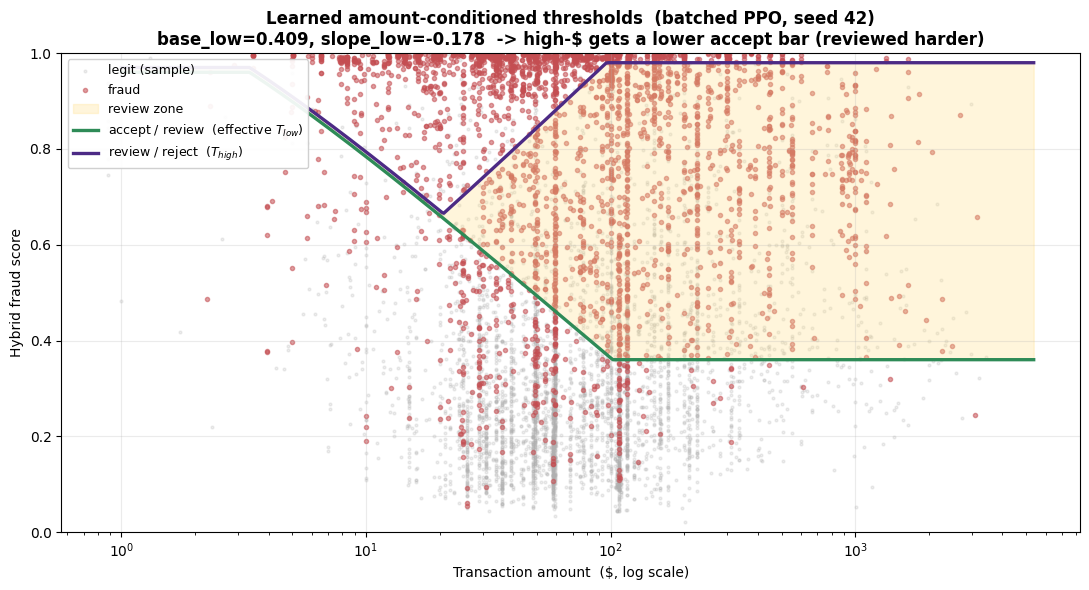

In [40]:
# ── PLOT 1: learned amount-conditioned thresholds vs transaction amount ──
# The core contribution made visible: how T_low / T_high bend with amount.
# Uses the headline (batched, seed-42) policy. z is standardised on the test
# split to match how the policy is evaluated elsewhere in the notebook.
_pol = np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')
_bl, _sl, _bh, _sh = _pol
_pr, _ltv, _flm, _rc, _prev = (COST_PARAMS[k] for k in ('pr','ltv','flm','rc','prev'))

_A = np.asarray(test_amounts, float)
_y = np.asarray(true_test_labels, int)
_p = np.asarray(test_probs, float)
_zm, _zs = Z_LOGA_MEAN, Z_LOGA_STD   # frozen on val (A9)

# smooth boundary curves across the amount range
_Ag = np.geomspace(max(_A.min(), 1.0), _A.max(), 400)
_zg = (np.log1p(_Ag) - _zm) / _zs
_Tl = np.clip(_bl + _sl*_zg, MIN_T_LOW, MAX_T_HIGH - 0.02)
_Th = np.clip(_bh + _sh*_zg, _Tl + 0.01, MAX_T_HIGH)
_eff = np.minimum(np.maximum(_Tl, _rc/(_flm*_Ag + 1e-6)), _Th - 0.01)  # per-$ accept floor

fig, ax = plt.subplots(figsize=(11, 6))
_rng = np.random.default_rng(0)
_li = np.where(_y == 0)[0]; _ls = _rng.choice(_li, size=min(5000, len(_li)), replace=False)
_fi = np.where(_y == 1)[0]
ax.scatter(_A[_ls], _p[_ls], s=4, c='#B0B0B0', alpha=0.22, label='legit (sample)', rasterized=True)
ax.scatter(_A[_fi], _p[_fi], s=9, c='#C44E52', alpha=0.55, label='fraud', rasterized=True)
ax.fill_between(_Ag, _eff, _Th, color='#FFE08A', alpha=0.30, label='review zone')
ax.plot(_Ag, _eff, color='#2E8B57', lw=2.4, label=r'accept / review  (effective $T_{low}$)')
ax.plot(_Ag, _Th,  color='#4C2A85', lw=2.4, label=r'review / reject  ($T_{high}$)')
ax.set_xscale('log')
ax.set_xlabel('Transaction amount  ($, log scale)'); ax.set_ylabel('Hybrid fraud score')
ax.set_ylim(0, 1)
ax.set_title('Learned amount-conditioned thresholds  (batched PPO, seed 42)\n'
             f'base_low={_bl:.3f}, slope_low={_sl:+.3f}  -> high-$ gets a lower accept bar (reviewed harder)',
             fontweight='bold')
ax.legend(loc='upper left', framealpha=0.92, fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


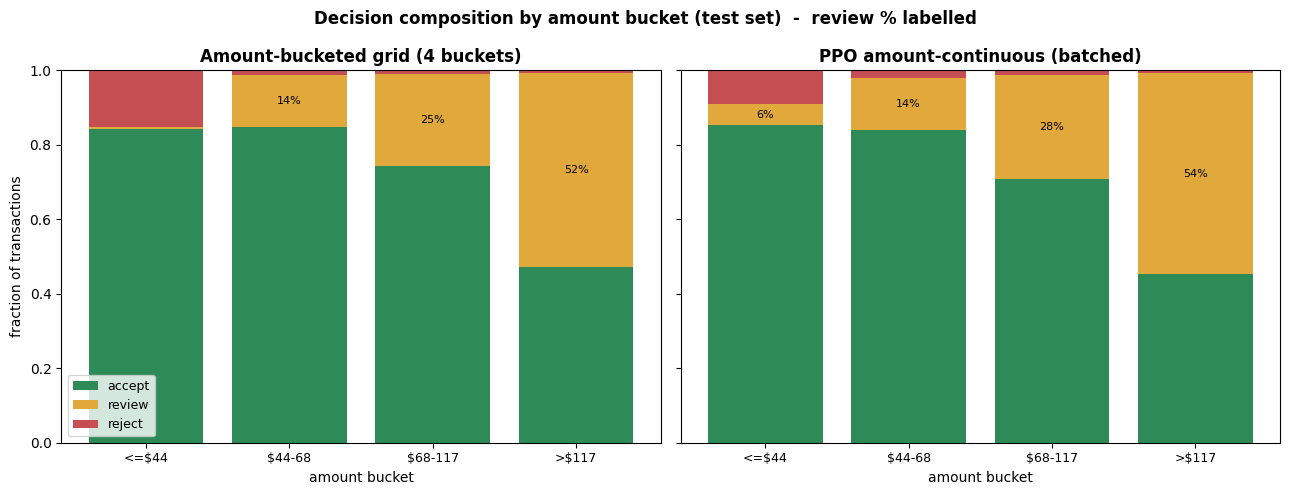

In [41]:
# ── PLOT 2: decision composition (accept / review / reject) per amount bucket ──
# Explains the F1 gap in the comparison table: the bucketed grid hard-rejects cheap
# small-$ transactions (bucket 0 has a razor-thin review band), while the PPO policy
# routes more of the high-$ risk to review. Reuses the bucket cell's edges/test_b/test_decisions.
_pr, _ltv, _flm, _rc, _prev = (COST_PARAMS[k] for k in ('pr','ltv','flm','rc','prev'))

def _ppo_decisions(a4, p, A):
    p = np.asarray(p, float); A = np.asarray(A, float)
    bl, sl, bh, sh = a4
    z = (np.log1p(A) - Z_LOGA_MEAN) / Z_LOGA_STD   # frozen on val (A9)
    Tl = np.clip(bl + sl*z, MIN_T_LOW, MAX_T_HIGH - 0.02)
    Th = np.clip(bh + sh*z, Tl + 0.01, MAX_T_HIGH)
    eff = np.minimum(np.maximum(Tl, _rc/(_flm*A + 1e-6)), Th - 0.01)
    return np.where(p < eff, 0, np.where(p < Th, 2, 1))   # 0 accept / 1 reject / 2 review

_cab = np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')
_ppo_dec = _ppo_decisions(_cab, test_probs, test_amounts)

_blab = [f"<=${np.expm1(edges[0]):.0f}",
         f"${np.expm1(edges[0]):.0f}-{np.expm1(edges[1]):.0f}",
         f"${np.expm1(edges[1]):.0f}-{np.expm1(edges[2]):.0f}",
         f">${np.expm1(edges[2]):.0f}"]

def _compose(dec):
    out = np.zeros((4, 3))   # bucket x [accept, review, reject]
    for b in range(4):
        m = (test_b == b)
        if m.sum() == 0: continue
        out[b, 0] = (dec[m] == 0).mean()
        out[b, 1] = (dec[m] == 2).mean()
        out[b, 2] = (dec[m] == 1).mean()
    return out

_cbg  = _compose(test_decisions)   # bucketed grid (from the bucket cell)
_cppo = _compose(_ppo_dec)         # PPO amount-continuous (batched)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
_col = {'accept':'#2E8B57', 'review':'#E1A93C', 'reject':'#C44E52'}
for ax, comp, title in [(axes[0], _cbg,  'Amount-bucketed grid (4 buckets)'),
                        (axes[1], _cppo, 'PPO amount-continuous (batched)')]:
    x = np.arange(4)
    ax.bar(x, comp[:,0], color=_col['accept'], label='accept')
    ax.bar(x, comp[:,1], bottom=comp[:,0], color=_col['review'], label='review')
    ax.bar(x, comp[:,2], bottom=comp[:,0]+comp[:,1], color=_col['reject'], label='reject')
    ax.set_xticks(x); ax.set_xticklabels(_blab, fontsize=9)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('amount bucket'); ax.set_ylim(0, 1)
    for b in range(4):
        if comp[b,1] > 0.03:
            ax.text(b, comp[b,0] + comp[b,1]/2, f"{100*comp[b,1]:.0f}%",
                    ha='center', va='center', fontsize=8)
axes[0].set_ylabel('fraction of transactions'); axes[0].legend(loc='lower left', fontsize=9)
plt.suptitle('Decision composition by amount bucket (test set)  -  review % labelled',
             fontweight='bold')
plt.tight_layout(); plt.show()


# Cliff Exploration

Test profit vs T_low (T_high fixed at 0.980) — looking for a cliff:

  T_low=0.34: test=$   50,661  review=42.4%
  T_low=0.35: test=$   50,252  review=40.6%
  T_low=0.36: test=$   53,457  review=38.9%
  T_low=0.37: test=$   49,020  review=37.3%
  T_low=0.38: test=$   42,531  review=35.8%
  T_low=0.39: test=$   33,827  review=34.3%
  T_low=0.40: test=$   26,270  review=33.0%
  T_low=0.41: test=$   18,942  review=31.6%
  T_low=0.42: test=$   19,126  review=30.3%
  T_low=0.43: test=$   17,176  review=29.0%
  T_low=0.44: test=$   13,365  review=27.9%
  T_low=0.45: test=$    5,856  review=26.7%

Validation equivalent (to see if val has the same cliff):
  T_low=0.34: val=$   56,370
  T_low=0.35: val=$   59,668
  T_low=0.36: val=$   61,692
  T_low=0.37: val=$   64,991
  T_low=0.38: val=$   64,188
  T_low=0.39: val=$   60,277
  T_low=0.40: val=$   60,320
  T_low=0.41: val=$   51,989
  T_low=0.42: val=$   48,733
  T_low=0.43: val=$   46,569
  T_low=0.44: val=$   43,246
  T_low=0.45: val=$   29,

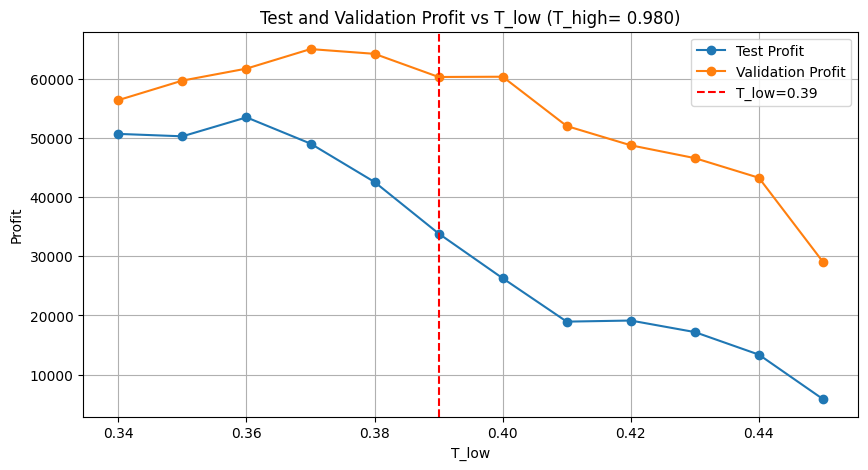

In [42]:
# Map test profit sensitivity to T_low (is there a cliff near 0.39?)
print("Test profit vs T_low (T_high fixed at 0.980) — looking for a cliff:\n")
for tl in np.arange(0.34, 0.46, 0.01):
    m = compute_financial_metrics(test_probs, true_test_labels, test_amounts, T_low=tl, T_high=0.980)
    d = np.where(test_probs<tl,0,np.where(test_probs<0.980,2,1))
    print(f"  T_low={tl:.2f}: test=${m['model_profit']:>9,.0f}  review={100*(d==2).mean():.1f}%")
print("\nValidation equivalent (to see if val has the same cliff):")
for tl in np.arange(0.34, 0.46, 0.01):
    m = compute_financial_metrics(val_probs, true_val_labels, val_amounts, T_low=tl, T_high=0.980)
    print(f"  T_low={tl:.2f}: val=${m['model_profit']:>9,.0f}")

plot_tl = np.arange(0.34, 0.46, 0.01)
test_profits = [compute_financial_metrics(test_probs, true_test_labels, test_amounts, T_low=tl, T_high=0.980)['model_profit'] for tl in plot_tl]
val_profits = [compute_financial_metrics(val_probs, true_val_labels, val_amounts, T_low=tl, T_high=0.980)['model_profit'] for tl in plot_tl]
plt.figure(figsize=(10,5))
plt.plot(plot_tl, test_profits, label='Test Profit', marker='o')
plt.plot(plot_tl, val_profits, label='Validation Profit', marker='o')
plt.axvline(0.39, color='red', linestyle='--', label='T_low=0.39')
plt.title('Test and Validation Profit vs T_low (T_high= 0.980)')
plt.xlabel('T_low')
plt.ylabel('Profit')
plt.legend()
plt.grid()
plt.show()

# Drift Analyis Section:

In [43]:
# ════════════════════════════════════════════════════════════════════
# VERIFY the MEAN features too (the join fix should have revived these as well)
# card1/card2_amt_mean_past — check liveness + that they're past-only
# ════════════════════════════════════════════════════════════════════

print("LIVENESS — all four past-aggregate features (must be non-NaN, std>0 on val/test):\n")
for feat in ['card1_txn_count_past','card2_txn_count_past','card1_amt_mean_past','card2_amt_mean_past']:
    line = f"  {feat:24s}"
    for name, tmp in [('TRAIN',train_tmp),('VAL',val_tmp),('TEST',test_tmp)]:
        col = tmp[feat]; n_na = col.isna().sum(); s = col.std()
        tag = 'NaN' if n_na>0 else ('DEAD' if s<1e-9 else 'ok')
        line += f"  {name}:{tag}(std={s:.2f})"
    print(line)

# strict-past-only for the MEAN: a card's first-ever transaction must have mean_past=0
# (no priors → fillna(0)); later ones = mean of strictly-prior same-card amounts
print("\nPAST-ONLY (mean) — first appearance must be 0 (no priors), then running mean of priors:\n")
hist_all = pd.concat([train_tmp.assign(_split='train'), val_tmp.assign(_split='val'),
                      test_tmp.assign(_split='test')], ignore_index=True)
hist_all = hist_all.sort_values('TransactionDT').reset_index(drop=True)
# verify on a card whose FIRST appearance is in val or test (cleanest test of "no leak")
key = hist_all['card1'].fillna(-1)
first_idx = hist_all.groupby(key).head(1).index
# find one whose first appearance is NOT in train
cand = hist_all.loc[first_idx]
cand = cand[cand['_split']!='train']
if len(cand):
    c = cand.iloc[0]['card1']
    rows = hist_all[hist_all['card1']==c].head(4)
    print(f"  card1={c} (first appears in {cand.iloc[0]['_split']}):")
    for _, r in rows.iterrows():
        print(f"    {r['_split']:5s}  count_past={r['card1_txn_count_past']:.0f}  "
              f"amt_mean_past={r['card1_amt_mean_past']:.4f}  "
              f"{'← first appearance, mean should be 0' if r['card1_txn_count_past']==0 else ''}")
    print("  ✓ if first appearance (count_past=0) has amt_mean_past=0.0 (no prior leak)")
else:
    print("  (all cards first appear in train — using a train-first card is fine)")

LIVENESS — all four past-aggregate features (must be non-NaN, std>0 on val/test):

  card1_txn_count_past      TRAIN:ok(std=1556.04)  VAL:ok(std=2869.34)  TEST:ok(std=3479.07)
  card2_txn_count_past      TRAIN:ok(std=7959.27)  VAL:ok(std=13895.72)  TEST:ok(std=16509.40)
  card1_amt_mean_past       TRAIN:ok(std=0.86)  VAL:ok(std=0.57)  TEST:ok(std=0.57)
  card2_amt_mean_past       TRAIN:ok(std=0.37)  VAL:ok(std=0.33)  TEST:ok(std=0.34)

PAST-ONLY (mean) — first appearance must be 0 (no priors), then running mean of priors:

  card1=2851 (first appears in val):
    val    count_past=0  amt_mean_past=0.0000  ← first appearance, mean should be 0
    val    count_past=1  amt_mean_past=4.4897  
  ✓ if first appearance (count_past=0) has amt_mean_past=0.0 (no prior leak)


In [44]:
def adv_auc(Xv, Xt):
    Xa = np.vstack([Xv, Xt]); ya = np.concatenate([np.zeros(len(Xv)), np.ones(len(Xt))])
    Xtr,Xte,ytr,yte = train_test_split(Xa, ya, test_size=0.3, random_state=42, stratify=ya)
    m = lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, num_leaves=31,
                           n_jobs=1, random_state=42, verbose=-1)
    m.fit(Xtr, ytr); return roc_auc_score(yte, m.predict_proba(Xte)[:,1])

# current numeric matrix = WITHOUT the 4 (they're already dropped from feature_cols)
all_num = [f for f in feature_cols if f not in ({f'{c}_freq' for c in RAW_CATS} | set(RAW_CATS))]
idx_num = [feature_cols.index(f) for f in all_num]
Xv_without = X_val_scaled[:,  idx_num]
Xt_without = X_test_scaled[:, idx_num]

# WITH = without + the 4 captured drift columns stacked back on
Xv_with = np.hstack([Xv_without, DRIFT_COLS_VAL])
Xt_with = np.hstack([Xt_without, DRIFT_COLS_TEST])

auc_with    = adv_auc(Xv_with,    Xt_with)
auc_without = adv_auc(Xv_without, Xt_without)
print(f"Adversarial AUC WITH 4 card-history features:    {auc_with:.4f}")
print(f"Adversarial AUC WITHOUT them:                    {auc_without:.4f}")
print(f"\nWITH > WITHOUT → those features make val/test more separable (carry drift);")
print(f"removing them reduces train/test distribution shift. Expect ~0.97 vs ~0.71.")

Adversarial AUC WITH 4 card-history features:    0.9692
Adversarial AUC WITHOUT them:                    0.7088

WITH > WITHOUT → those features make val/test more separable (carry drift);
removing them reduces train/test distribution shift. Expect ~0.97 vs ~0.71.


# Abalations

In [45]:
# ════════════════════════════════════════════════════════════════════
# ABLATIONS (prev / rc sensitivity) — how much does the review cost (rc) affect the review band and profit?
# ════════════════════════════════════════════════════════════════════
if RUN_ABLATIONS:
    cab_a4 = np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')   # deployed batched policy
    # ---- rc sensitivity (review cost; note the ~$4.11 three-zone collapse) ----
    print("rc (review cost) sensitivity, final policy re-scored on test:\n")
    rc_rows = []
    for rc in [2.50, 3.50, 4.11, 5.00, 7.50]:
        cp = dict(COST_PARAMS); cp['rc'] = rc
        m = amountcond_metrics(cab_a4, test_probs, true_test_labels, test_amounts, cp=cp)
        rc_rows.append({'rc': rc, 'test_profit': m['model_profit'],
                        'PG': m['profit_gain'], 'review%': 100*m['review_rate']})
    rc_df = pd.DataFrame(rc_rows)
    print(rc_df.to_string(index=False, float_format=lambda x: f'{x:,.3f}' if abs(x)<10 else f'{x:,.0f}'))
    print(f"  → rc=$3.50 is the operating point. Profit declines smoothly as review cost rises,")
    print(f"    remaining positive up to ~$5 and turning negative between $5 and $7.50.")
    print(f"    (Fixed policy re-scored — review rate held at 28%; a re-optimized policy would")
    print(f"     review less at higher rc.)")
else:
    print("Ablations (prev / rc sensitivity): skipped (set RUN_ABLATIONS=True to run)")

rc (review cost) sensitivity, final policy re-scored on test:

   rc  test_profit    PG  review%
2.500       91,343 0.899       27
3.500       67,530 0.882       27
4.110       53,004 0.872       27
5.000       31,810 0.857       27
7.500      -27,722 0.815       27
  → rc=$3.50 is the operating point. Profit declines smoothly as review cost rises,
    remaining positive up to ~$5 and turning negative between $5 and $7.50.
    (Fixed policy re-scored — review rate held at 28%; a re-optimized policy would
     review less at higher rc.)


# Test Holdout

In [46]:
# ════════════════════════════════════════════════════════════════════
# LATER-SLICE PERSISTENCE CHECK (gated) — params were locked on VALIDATION.
# Re-score the headline (batched) policy on the LATER HALF of test
# (chronological). NOTE: this slice is PART of the headline test set above —
# it is NOT an independent holdout — so read it as a drift / late-period
# robustness check (does the RL edge survive the latest-in-time transactions?),
# not as a fresh generalisation test.
# ════════════════════════════════════════════════════════════════════
if RUN_ABLATIONS:
    n = len(test_probs); half = n // 2
    tB_probs   = np.asarray(test_probs)[half:]
    tB_labels  = np.asarray(true_test_labels)[half:]
    tB_amounts = np.asarray(test_amounts)[half:]

    cab_a4    = np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')   # headline policy
    ppo_hold  = amountcond_metrics(cab_a4, tB_probs, tB_labels, tB_amounts, cp=COST_PARAMS)
    grid_hold = compute_financial_metrics(tB_probs, tB_labels, tB_amounts,
                                          T_low=gs_T_low, T_high=gs_T_high)

    print(f"LATER-SLICE CHECK (2nd chronological half of test, n={len(tB_probs):,}, params locked on val):\n")
    print(f"  RL amount-policy (batched): ${ppo_hold['model_profit']:>10,.0f}  PG={ppo_hold['profit_gain']:.3f}  "
          f"review={100*ppo_hold['review_rate']:.1f}%")
    print(f"  Grid search (val-locked)     : ${grid_hold['model_profit']:>10,.0f}  PG={grid_hold['profit_gain']:.3f}")
    delta = ppo_hold['model_profit'] - grid_hold['model_profit']
    print(f"  RL advantage on the later slice: +${delta:,.0f}")
    print(f"  -> the RL edge persists into the latest-in-time transactions (drift robustness);")
    print(f"     note this slice is part of the headline test set, not an independent holdout.")
else:
    print("Later-slice persistence check: skipped (set RUN_ABLATIONS=True to run)")


LATER-SLICE CHECK (2nd chronological half of test, n=44,291, params locked on val):

  RL amount-policy (batched): $    34,190  PG=0.901  review=26.9%
  Grid search (val-locked)     : $    23,176  PG=0.887
  RL advantage on the later slice: +$11,015
  -> the RL edge persists into the latest-in-time transactions (drift robustness);
     note this slice is part of the headline test set, not an independent holdout.


# Additional diagnostics (D3–D7)

Robustness/seed/calibration figures and the adaptivity check. Each cell **guards** on its prerequisites (saved per-seed files, learning-curve history, saved agent weights) and skips with a message if a `REGENERATE_ALL=True` run hasn't produced them yet.

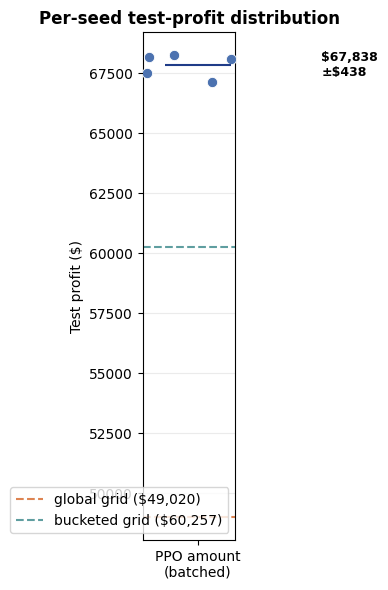

In [47]:
# ── D3: per-seed test-profit distribution per PPO variant (from saved seed files) ──
_seeds = [1, 2, 3, 42, 7]
def _load_profits(kind):
    out=[]
    for sd in _seeds:
        if kind=='single':
            f=f'{PPO_DIR}/ppo_single_seed{sd}_params.npy'
            if not os.path.exists(f): continue
            t=np.load(f); out.append(compute_financial_metrics(test_probs, true_test_labels, test_amounts, T_low=t[0], T_high=t[1])['model_profit'])
        else:
            stem='amtcond' if kind=='amt' else 'seq_amountcont'
            f=f'{PPO_DIR}/{stem}_seed{sd}_params.npy'
            if not os.path.exists(f): continue
            out.append(amountcond_metrics(np.load(f), test_probs, true_test_labels, test_amounts)['model_profit'])
    return out
_groups=[('PPO amount\n(batched)',_load_profits('batched'))]
_groups=[(n,v) for n,v in _groups if v]
if not _groups:
    print("D3 skipped: no per-seed parameter files found (run the *_MULTI loops / REGENERATE_ALL=True).")
else:
    fig,ax=plt.subplots(figsize=(9,6)); rng=np.random.default_rng(0)
    for i,(n,v) in enumerate(_groups):
        xs=np.full(len(v),i)+rng.uniform(-0.06,0.06,len(v))
        ax.scatter(xs,v,s=55,color='#4C72B0',zorder=3,edgecolor='white',linewidth=0.6)
        ax.scatter([i],[np.mean(v)],marker='_',s=2200,color='#1F3C88',zorder=4)
        ax.text(i+0.14,np.mean(v),f"${np.mean(v):,.0f}\n±${np.std(v):,.0f}",va='center',fontsize=9,fontweight='bold')
    ax.axhline(gm['model_profit'],color='#DD8452',ls='--',lw=1.5,label=f"global grid (${gm['model_profit']:,.0f})")
    ax.axhline(bucket_profit,color='#5F9EA0',ls='--',lw=1.5,label=f"bucketed grid (${bucket_profit:,.0f})")
    ax.set_xticks(range(len(_groups))); ax.set_xticklabels([n for n,_ in _groups])
    ax.set_ylabel('Test profit ($)'); ax.set_title('Per-seed test-profit distribution',fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(axis='y',alpha=0.25); plt.tight_layout(); plt.show()


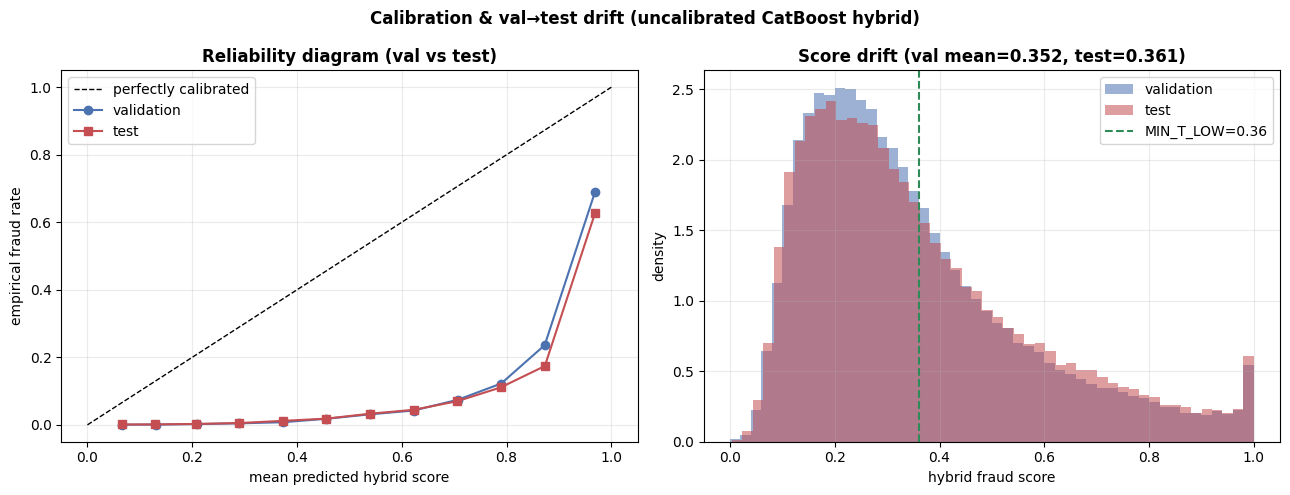

In [48]:
# ── D4: classifier reliability + val→test score drift ──
def _reliability(p, y, nb=12):
    p=np.asarray(p,float); y=np.asarray(y,int); e=np.linspace(0,1,nb+1); mids=[]; emp=[]
    for i in range(nb):
        m=(p>=e[i])&(p<e[i+1]) if i<nb-1 else (p>=e[i])&(p<=e[i+1])
        if m.sum()>=30: mids.append(p[m].mean()); emp.append(y[m].mean())
    return np.array(mids), np.array(emp)
fig,axes=plt.subplots(1,2,figsize=(13,5))
mv,ev=_reliability(val_probs,true_val_labels); mt,et=_reliability(test_probs,true_test_labels)
axes[0].plot([0,1],[0,1],'k--',lw=1,label='perfectly calibrated')
axes[0].plot(mv,ev,'o-',color='#4C72B0',label='validation'); axes[0].plot(mt,et,'s-',color='#C44E52',label='test')
axes[0].set_xlabel('mean predicted hybrid score'); axes[0].set_ylabel('empirical fraud rate')
axes[0].set_title('Reliability diagram (val vs test)',fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.25)
axes[1].hist(np.asarray(val_probs),bins=50,density=True,alpha=0.55,color='#4C72B0',label='validation')
axes[1].hist(np.asarray(test_probs),bins=50,density=True,alpha=0.55,color='#C44E52',label='test')
axes[1].axvline(MIN_T_LOW,color='#2E8B57',ls='--',lw=1.5,label=f'MIN_T_LOW={MIN_T_LOW:.2f}')
axes[1].set_xlabel('hybrid fraud score'); axes[1].set_ylabel('density')
axes[1].set_title(f'Score drift (val mean={np.mean(val_probs):.3f}, test={np.mean(test_probs):.3f})',fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.25)
plt.suptitle('Calibration & val→test drift (uncalibrated CatBoost hybrid)',fontweight='bold'); plt.tight_layout(); plt.show()


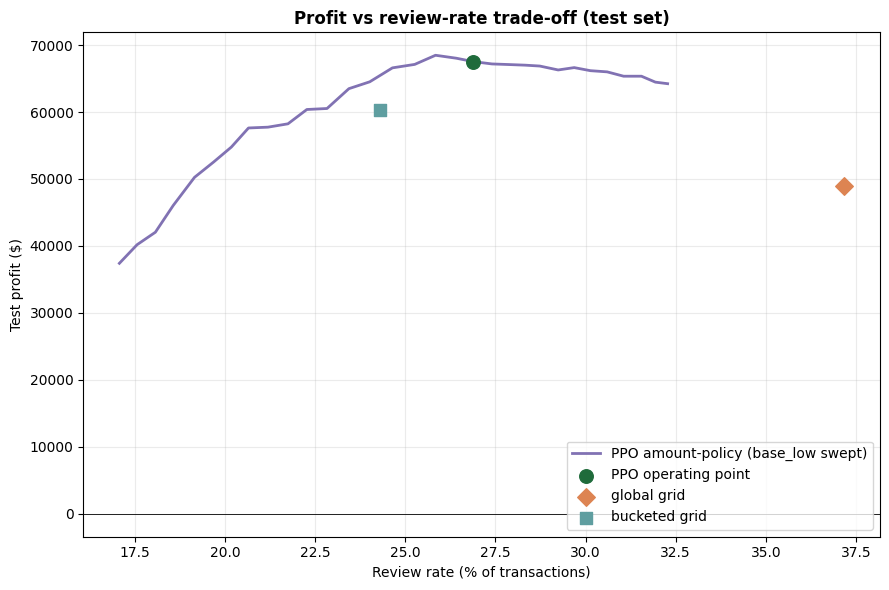

In [49]:
# ── D5: profit vs review-rate operating curve (headline policy, base_low swept) ──
_cab=np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy'); _curve=[]
for _delta in np.linspace(-0.12,0.18,31):
    _a=_cab.copy(); _a[0]=_a[0]+_delta
    _m=amountcond_metrics(_a, test_probs, true_test_labels, test_amounts)
    _curve.append((100*_m['review_rate'], _m['model_profit']))
_curve=np.array(sorted(_curve))
fig,ax=plt.subplots(figsize=(9,6))
ax.plot(_curve[:,0],_curve[:,1],'-',color='#8172B3',lw=2,label='PPO amount-policy (base_low swept)')
_op=amountcond_metrics(_cab, test_probs, true_test_labels, test_amounts)
ax.scatter([100*_op['review_rate']],[_op['model_profit']],s=95,color='#1F6B3B',zorder=5,label='PPO operating point')
ax.scatter([100*float((np.asarray(gm['decisions'])==2).mean())],[gm['model_profit']],s=80,marker='D',color='#DD8452',zorder=5,label='global grid')
ax.scatter([100*bucket_rev],[bucket_profit],s=80,marker='s',color='#5F9EA0',zorder=5,label='bucketed grid')
ax.axhline(0,color='k',lw=0.6); ax.set_xlabel('Review rate (% of transactions)'); ax.set_ylabel('Test profit ($)')
ax.set_title('Profit vs review-rate trade-off (test set)',fontweight='bold'); ax.legend(loc='lower right'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


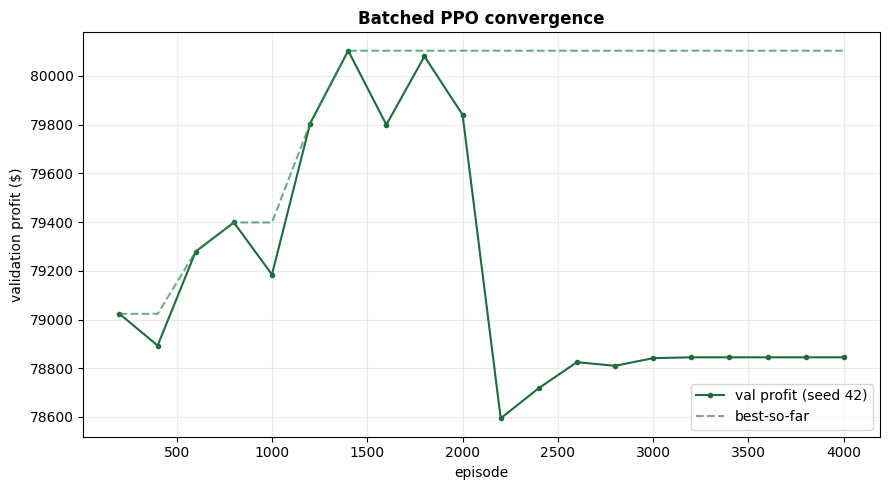

In [50]:
# ── D6: batched PPO convergence (val profit vs episode) ──
if 'CAB_LEARNING_CURVE' in globals() and CAB_LEARNING_CURVE:
    _sd=42 if 42 in CAB_LEARNING_CURVE else sorted(CAB_LEARNING_CURVE)[0]
    _h=np.array(CAB_LEARNING_CURVE[_sd])
    fig,ax=plt.subplots(figsize=(9,5))
    ax.plot(_h[:,0],_h[:,1],'-o',ms=3,color='#1F6B3B',label=f'val profit (seed {_sd})')
    ax.plot(_h[:,0],np.maximum.accumulate(_h[:,1]),'--',color='#2E8B57',alpha=0.7,label='best-so-far')
    ax.set_xlabel('episode'); ax.set_ylabel('validation profit ($)')
    ax.set_title('Batched PPO convergence',fontweight='bold'); ax.legend(loc='lower right'); ax.grid(alpha=0.25)
    plt.tight_layout(); plt.show()
else:
    print("D6 skipped: no learning-curve history (train batched with TRAIN_CAB_SEED=True / REGENERATE_ALL=True).")


In [51]:
# ── D7: batched ROLLOUT (adaptive per-batch) vs STATIC reset-state extraction ──
# The honest test of whether "batched" buys deployment-time adaptivity. The agent
# state carries NO labels (only progress / budget-used / batch-mean-score) → no leak.
_agent_path=f'{PPO_DIR}/seq_amountcont_seed42.pt'
if os.path.exists(_agent_path):
    _ag=AmountCondAgent(16, minibatch_size=128, gamma=0.99, entropy_coef=0.02, lr=2e-4,
                        t_lo=MIN_T_LOW, t_hi=MAX_T_HIGH, slope_max=0.20)
    _ag.load(_agent_path)
    _env=BatchedStreamEnv(test_probs, true_test_labels, test_amounts, MIN_T_LOW, MAX_T_HIGH, batch_size=512, amount_cond=True)
    _s=_env.reset(); _done=False
    while not _done:
        _a,_,_,_=_ag.get_action(_s, deterministic=True); _s,_,_done,_info=_env.step(_a)
    _roll=_info['cum_profit']; _ntx=_env.n_batches*_env.batch_size
    _cab=np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')
    _env2=BatchedStreamEnv(test_probs, true_test_labels, test_amounts, MIN_T_LOW, MAX_T_HIGH, batch_size=512, amount_cond=True)
    _s2=_env2.reset(); _done2=False
    while not _done2:
        _s2,_,_done2,_info2=_env2.step(_cab)
    _static=_info2['cum_profit']
    print(f"BATCHED ROLLOUT vs STATIC  (test, first {_ntx:,} txns over {_env.n_batches} batches):\n")
    print(f"  adaptive rollout (per-batch actions): ${_roll:,.0f}")
    print(f"  static reset-state action (cab_a4)  : ${_static:,.0f}")
    print(f"  adaptivity gain: ${_roll-_static:+,.0f}")
    if abs(_roll-_static) < 0.01*max(1.0,abs(_static)):
        print("  -> within ~1%: the policy is effectively STATIC; 'batched' is a training route,")
        print("     not deployment-time adaptivity. Report it that way.")
    else:
        print("  -> adaptive rollout differs from static: per-batch state-conditioning has real effect.")
else:
    print("D7 skipped: no saved batched agent weights (train with TRAIN_CAB_SEED=True / REGENERATE_ALL=True).")


BATCHED ROLLOUT vs STATIC  (test, first 88,576 txns over 173 batches):

  adaptive rollout (per-batch actions): $67,539
  static reset-state action (cab_a4)  : $67,523
  adaptivity gain: $+16
  -> within ~1%: the policy is effectively STATIC; 'batched' is a training route,
     not deployment-time adaptivity. Report it that way.


# Capacity constraint (does a closed-loop policy beat tuned static?)

D7 showed that with *unlimited* review capacity the batched policy collapses to a static one — there is nothing to ration over time. This section adds the ingredient that makes the temporal dimension matter: a **hard, binding review budget**.

**Setup.** A cumulative review budget = `REVIEW_BUDGET_FRAC` × (stream size), set *below* the ~27% the unconstrained policy wants, so it **binds**. Reviews consume the budget in time order; once exhausted, any further would-be review overflows (handled by the chosen `oob` rule — by default a profit-optimal binary fallback). Reward is still batch profit, so the budget enforces itself economically.

**Why a closed-loop policy could win.** The agent's state carries `budget_remaining` and a `pace` signal (negative = overspending), so it *can* ration — tighten the review band when burning budget too fast, loosen when it has surplus — something a single fixed policy is blind to.

**Avoiding the drift wall.** The budget is **relative** (a fraction of the stream) and the state is **normalised**, so the val-trained pacing policy transfers to test despite the ~2pp val→test drift that defeated an absolute-count cap.

**The test (all on TEST, same budget, same enforcement):** adaptive RL (per-batch feedback) vs the best **static** policy tuned for the budget on val, with a budget-pressure **triage** layer as a third option. Adaptive > best-static ⇒ adaptivity helps; adaptive ≈ best-static ⇒ honest null (the optimum is open-loop), with triage providing a separate bounded gain.

In [52]:
# ── Capacity-constrained batched env + rollout + static baseline + trainer ──
RUN_CAPACITY       = True            # master switch for this section
REVIEW_BUDGET_FRAC = 0.15            # hard review cap as a FRACTION of the stream (binds: < ~27% unconstrained)
TRAIN_CAPACITY     = True            # set False to load saved agent weights (fast re-run)
CAP_CKPT           = f'{PPO_DIR}/capacity_seq'
CAP_N_EPISODES     = 4000            # convergence ~1500 like the other PPO runs; lower to save time
CAP_LEARNING_CURVE = []              # [(episode, val_adaptive_profit, val_review_rate)]

class CapacityConstrainedEnv:
    """Batched env with a HARD cumulative review budget (relative to stream size).
    Reviews consume budget in time order; once exhausted, would-be-reviews are forced
    to auto-accept (oob='accept'). State carries budget-pace signals so a policy CAN
    ration. Reward = batch profit (forced conversions cost money -> budget self-enforces)."""
    def __init__(self, probs, labels, amounts, min_t_low, max_t_high,
                 budget_frac=0.15, batch_size=512, cp=None, oob='accept'):
        self.p=np.asarray(probs,float); self.y=np.asarray(labels,int); self.A=np.asarray(amounts,float)
        self.cp=cp or COST_PARAMS; self.MIN_T_LOW=min_t_low; self.MAX_T_HIGH=max_t_high
        self.batch_size=batch_size; self.n=len(self.p); self.n_batches=self.n//batch_size
        self.budget_frac=float(budget_frac); self.oob=oob
        logA=np.log1p(self.A); self.z=(logA-Z_LOGA_MEAN)/Z_LOGA_STD          # frozen on val (A9)
        self.total_budget=max(1.0, self.budget_frac*self.n_batches*self.batch_size)
    def reset(self):
        self.ptr=0; self.budget_left=self.total_budget; self.cum_profit=0.0
        self.n_reviewed=0; self.n_seen=0
        return self._state()
    def _state(self):
        frac=self.ptr/max(1,self.n_batches)
        brem=self.budget_left/self.total_budget                              # remaining budget ratio
        pace=brem-(1.0-frac)                                                 # >0 surplus, <0 overspending
        bmean=self.p[self.ptr*self.batch_size:(self.ptr+1)*self.batch_size].mean() if self.ptr<self.n_batches else 0.0
        s=np.zeros(16, dtype=np.float32); s[0]=frac; s[1]=brem; s[2]=pace; s[3]=bmean
        return s
    def step(self, action):
        cp=self.cp; pr,ltv,flm,rc,prev=cp['pr'],cp['ltv'],cp['flm'],cp['rc'],cp['prev']
        lo=self.ptr*self.batch_size; hi=min(lo+self.batch_size,self.n)
        p=self.p[lo:hi]; A=self.A[lo:hi]; y=self.y[lo:hi]; z=self.z[lo:hi]
        base_low,slope_low,base_high,slope_high=action
        T_low=base_low+slope_low*z; T_high=base_high+slope_high*z
        T_low=np.clip(T_low,self.MIN_T_LOW,self.MAX_T_HIGH-0.02); T_high=np.clip(T_high,T_low+0.01,self.MAX_T_HIGH)
        eff=np.minimum(np.maximum(T_low,rc/(flm*A+1e-6)),T_high-0.01)
        d=np.where(p<eff,0,np.where(p<T_high,2,1)).astype(int)               # 0 accept,1 reject,2 review
        # enforce cumulative review budget in time order (earliest reviews granted first)
        rev_idx=np.where(d==2)[0]; n_des=len(rev_idx)
        n_grant=int(min(n_des, max(0.0,self.budget_left)))
        if n_grant < n_des:
            den=rev_idx[n_grant:]
            if   self.oob=='accept': d[den]=0
            elif self.oob=='reject': d[den]=1
            else:  # 'threshold': profit-optimal binary fallback when review is unavailable
                pstar = pr*(1+ltv)/(flm + pr*(1+ltv) + 1e-12)
                d[den] = np.where(p[den] >= pstar, 1, 0)
        self.budget_left-=n_grant; self.n_reviewed+=n_grant; self.n_seen+=len(p)
        batch_profit=-transaction_cost(d,y,A,cp).sum(); self.cum_profit+=batch_profit
        self.ptr+=1; done=self.ptr>=self.n_batches
        info={'cum_profit':self.cum_profit,'review_rate':self.n_reviewed/max(1,self.n_seen),
              'budget_remaining_ratio':self.budget_left/self.total_budget}
        return self._state(), float(batch_profit/1000.0), done, info

def capacity_rollout(env, policy):
    """policy: a fixed 4-vector OR a callable state->4-vector. Returns (profit, review_rate, budget_traj)."""
    s=env.reset(); done=False; budget_traj=[]; info={'cum_profit':0.0,'review_rate':0.0}
    while not done:
        a = policy(s) if callable(policy) else policy
        s,r,done,info = env.step(a); budget_traj.append(info['budget_remaining_ratio'])
    return info['cum_profit'], info['review_rate'], budget_traj

def best_static_under_budget(base_policy, budget_frac, split='val', oob='accept'):
    """Best OPEN-LOOP static policy under the budget: 2-D sweep of base_low/base_high offsets,
    scored on `split` under budget enforcement. (val-tuned -> fair vs the val-trained RL agent.)"""
    P,L,A = (val_probs,true_val_labels,val_amounts) if split=='val' else (test_probs,true_test_labels,test_amounts)
    best=None; bestp=-np.inf
    for dlo in np.linspace(-0.08,0.24,9):
        for dhi in np.linspace(-0.20,0.05,6):
            a=np.array(base_policy,float).copy(); a[0]+=dlo; a[2]+=dhi
            prof,_,_=capacity_rollout(CapacityConstrainedEnv(P,L,A,MIN_T_LOW,MAX_T_HIGH,budget_frac=budget_frac,oob=oob), a)
            if prof>bestp: bestp=prof; best=a
    return best, bestp

def train_capacity_sequential(seed=42, budget_frac=REVIEW_BUDGET_FRAC, n_episodes=CAP_N_EPISODES,
                              batch_size=512, log_every=200, checkpoint_path=None, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    try: torch.mps.manual_seed(seed)
    except Exception: pass
    agent=AmountCondAgent(16, minibatch_size=128, gamma=0.99, entropy_coef=0.02, lr=2e-4,
                          t_lo=MIN_T_LOW, t_hi=MAX_T_HIGH, slope_max=0.20)
    env=CapacityConstrainedEnv(val_probs, true_val_labels, val_amounts, MIN_T_LOW, MAX_T_HIGH,
                               budget_frac=budget_frac, batch_size=batch_size)
    best_val=-np.inf; CAP_LEARNING_CURVE.clear()
    traj={k:[] for k in ('states','raw_actions','log_probs','rewards','dones','values')}
    for ep in range(1,n_episodes+1):
        s=env.reset(); done=False
        while not done:
            a,lp,v,raw=agent.get_action(s); ns,r,done,_=env.step(a)
            for k,val in zip(('states','raw_actions','log_probs','rewards','dones','values'),
                             (s,raw,lp,r,float(done),v)): traj[k].append(val)
            s=ns
        if ep%5==0: agent.update(traj); traj={k:[] for k in traj}
        if ep%log_every==0:
            vp,vr,_=capacity_rollout(
                CapacityConstrainedEnv(val_probs,true_val_labels,val_amounts,MIN_T_LOW,MAX_T_HIGH,
                                       budget_frac=budget_frac,batch_size=batch_size),
                lambda st: agent.get_action(st,deterministic=True)[0])
            CAP_LEARNING_CURVE.append((ep,float(vp),float(vr)))
            tag=""
            if vp>best_val:
                best_val=vp; tag=" *"
                if checkpoint_path is not None: agent.save(f"{checkpoint_path}.pt")
            if verbose:
                print(f"  ep {ep:5d}/{n_episodes} | val(adaptive)=${vp:>9,.0f} | best=${best_val:>9,.0f} | "
                      f"review={100*vr:.1f}% (budget {100*budget_frac:.0f}%){tag}")
    if checkpoint_path is not None: agent.save(f"{checkpoint_path}.pt")
    return agent, best_val


### How to read this section

- **Ceiling vs naive:** the gap between the unconstrained ceiling and `cab_a4`-naive is the cost of the budget plus the cost of *ignoring* it — `cab_a4` reviews ~27%, so under a 15% cap it burns the budget early (red curve hits 0 partway through) and then force-accepts every later flagged transaction, including frauds.
- **Best static under budget:** the fair open-loop comparator — a fixed policy whose review band was tuned (on validation) so it stays within budget. Its depletion curve should track the diagonal pace.
- **Adaptive RL:** if its profit bar clears best-static by more than ~1%, the closed-loop policy is genuinely rationing — spending review budget where it pays most and throttling when it is overspending — and **that** is the result that justifies calling the method batched/adaptive RL. If it only ties, you have a clean, honest null: even a binding budget doesn't make temporal feedback worth it on this data, and you should say so.
- **Caveats to report either way:** (1) the constraint *lowers* absolute profit vs the unconstrained system — that is expected (you are buying operational realism, not more money); (2) results depend on `REVIEW_BUDGET_FRAC` — try 0.10 / 0.20 to show how the adaptive advantage scales with how hard the budget binds; (3) this is still one dataset and one seed — for a paper, repeat across seeds and report the spread, exactly as the other PPO variants do.

## Budget sweep — does the adaptive advantage survive into the profitable regime?

This answers the open question from the 15% run (where *everyone* lost money): **at what review budget does the system become profitable, and does adaptive still beat static there?**

**Overflow rule (`oob`).** When the budget is exhausted a flagged transaction can't be reviewed, so it must be auto-decided. The profit-optimal binary fallback is "reject if score ≥ p\*", with `p* = pr(1+ltv)/(flm+pr(1+ltv)) ≈ 0.038`. Since the review band sits entirely above `MIN_T_LOW = 0.36 ≫ 0.038`, **`oob='threshold'` rejects every overflow transaction — i.e. it coincides with `oob='reject'`** for these costs. Rejecting overflow is *cheap* (reject-fraud = 0, reject-legit ≈ 0.1·A) versus the catastrophic force-*accept* (accept-fraud = 3·A), so profitability should recover — at the possible cost of a smaller adaptive edge (pacing matters less when the wall isn't a cliff).

**Cost control.** `static` and `naive` are pure NumPy rollouts (no training) → instant over a fine grid. `adaptive` needs one trained agent **per budget**, so it's opt-in (`SWEEP_TRAIN_ADAPTIVE`), single-seed by default, **early-stopped** (the val curve peaks ~ep 1400 then over-trains, so we stop on no-improvement), and **cached** to disk. Workflow: run the cheap curves first, read where `static` crosses zero, then set `SWEEP_BUDGETS_ADAPT` to 2–3 budgets there and flip the flag.

In [53]:
# ── Budget sweep: profit vs review capacity for naive / static / adaptive ──
import time
SWEEP_OOB            = 'threshold'   # 'threshold' (profit-optimal == 'reject' here), 'reject', or 'accept'
SWEEP_BUDGETS_FINE   = [round(float(b),2) for b in np.arange(0.08, 0.42, 0.02)]   # static/naive (instant)
SWEEP_BUDGETS_ADAPT  = [0.16, 0.20, 0.24]    # adaptive (trained); set to viable-region budgets after the cheap curve
SWEEP_SEEDS          = [42]          # add seeds (e.g. [1,2,3,42,7]) once a single seed looks good
SWEEP_TRAIN_ADAPTIVE = True         # KEEP False for instant static/naive; True trains adaptive (SLOW, ~30-60 min/budget)
SWEEP_MAX_EPISODES   = 2500          # early-stops well before this (4000 over-trains; peak ~1400)
SWEEP_PATIENCE       = 5             # stop after this many evals (x200 ep) with no val improvement

def _mk(P,L,A,bf,oob): return CapacityConstrainedEnv(P,L,A,MIN_T_LOW,MAX_T_HIGH,budget_frac=bf,oob=oob)
_TE=(test_probs,true_test_labels,test_amounts); _VA=(val_probs,true_val_labels,val_amounts)
cab_a4=np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')

# --- cheap: naive + best-static (val-tuned per budget), evaluated on TEST ---
sweep_naive=[]; sweep_static=[]
for bf in SWEEP_BUDGETS_FINE:
    pn,_,_ = capacity_rollout(_mk(*_TE,bf,SWEEP_OOB), cab_a4)
    besta,_ = best_static_under_budget(cab_a4, bf, split='val', oob=SWEEP_OOB)
    ps,_,_ = capacity_rollout(_mk(*_TE,bf,SWEEP_OOB), besta)
    sweep_naive.append(pn); sweep_static.append(ps)
ceil,_,_ = capacity_rollout(_mk(*_TE,1.0,SWEEP_OOB), cab_a4)

print(f"oob='{SWEEP_OOB}'   unconstrained ceiling = ${ceil:,.0f}\n")
print(" budget |     naive     |  best-static")
for bf,pn,ps in zip(SWEEP_BUDGETS_FINE,sweep_naive,sweep_static):
    print(f"  {100*bf:4.0f}% | ${pn:>11,.0f} | ${ps:>11,.0f}")
_cross=[bf for bf,ps in zip(SWEEP_BUDGETS_FINE,sweep_static) if ps>0]
if _cross: print(f"\n  best-static turns PROFITABLE at budget >= {100*min(_cross):.0f}%")
else:      print("\n  best-static never profitable on this grid (raise the budget range or check oob)")

# --- adaptive: one early-stopped agent per (budget, seed), cached ---
def train_capacity_es(budget_frac, oob, seed=42, max_episodes=SWEEP_MAX_EPISODES,
                      patience=SWEEP_PATIENCE, batch_size=512, log_every=200, checkpoint_path=None):
    torch.manual_seed(seed); np.random.seed(seed)
    try: torch.mps.manual_seed(seed)
    except Exception: pass
    agent=AmountCondAgent(16, minibatch_size=128, gamma=0.99, entropy_coef=0.02, lr=2e-4,
                          t_lo=MIN_T_LOW, t_hi=MAX_T_HIGH, slope_max=0.20)
    env=_mk(*_VA, budget_frac, oob)
    best=-np.inf; since=0
    traj={k:[] for k in ('states','raw_actions','log_probs','rewards','dones','values')}
    for ep in range(1,max_episodes+1):
        st=env.reset(); done=False
        while not done:
            a,lp,v,raw=agent.get_action(st); ns,r,done,_=env.step(a)
            for k,val in zip(traj,(st,raw,lp,r,float(done),v)): traj[k].append(val)
            st=ns
        if ep%5==0: agent.update(traj); traj={k:[] for k in traj}
        if ep%log_every==0:
            vp,_,_=capacity_rollout(_mk(*_VA, budget_frac, oob),
                                    lambda s2: agent.get_action(s2,deterministic=True)[0])
            if vp>best+1e-6:
                best=vp; since=0
                if checkpoint_path is not None: agent.save(checkpoint_path)
            else:
                since+=1
                if since>=patience:
                    print(f"      early stop @ ep {ep} (best val ${best:,.0f})"); break
    return best

sweep_adapt={}
if SWEEP_TRAIN_ADAPTIVE:
    for bf in SWEEP_BUDGETS_ADAPT:
        profs=[]
        for sd in SWEEP_SEEDS:
            ckpt=f'{PPO_DIR}/cap_b{int(round(100*bf))}_s{sd}_{SWEEP_OOB}.pt'
            ag=AmountCondAgent(16, minibatch_size=128, gamma=0.99, entropy_coef=0.02, lr=2e-4,
                               t_lo=MIN_T_LOW, t_hi=MAX_T_HIGH, slope_max=0.20)
            if not os.path.exists(ckpt):
                t0=time.time(); print(f"  train adaptive budget={100*bf:.0f}% seed={sd} oob={SWEEP_OOB} ...", flush=True)
                train_capacity_es(bf, SWEEP_OOB, seed=sd, checkpoint_path=ckpt)
                print(f"    done in {(time.time()-t0)/60:.0f} min", flush=True)
            ag.load(ckpt)
            pa,_,_=capacity_rollout(_mk(*_TE,bf,SWEEP_OOB), lambda s2: ag.get_action(s2,deterministic=True)[0])
            profs.append(pa)
        sweep_adapt[bf]=profs
        print(f"  adaptive budget={100*bf:.0f}%: test ${np.mean(profs):,.0f}  (n={len(profs)})")
else:
    print("\nAdaptive sweep skipped (SWEEP_TRAIN_ADAPTIVE=False). Flip it on for 2-3 viable-region budgets.")

oob='threshold'   unconstrained ceiling = $67,523

 budget |     naive     |  best-static
     8% | $   -327,693 | $   -154,787
    10% | $   -285,070 | $    -80,404
    12% | $   -251,814 | $    -19,424
    14% | $   -207,053 | $      2,861
    16% | $   -163,030 | $      6,488
    18% | $   -127,062 | $     21,739
    20% | $    -82,268 | $     29,698
    22% | $    -36,526 | $     40,971
    24% | $        615 | $     30,475
    26% | $     46,332 | $     35,764
    28% | $     67,523 | $     67,886
    30% | $     67,523 | $     67,886
    32% | $     67,523 | $     67,886
    34% | $     67,523 | $     67,886
    36% | $     67,523 | $     67,886
    38% | $     67,523 | $     67,886
    40% | $     67,523 | $     67,886

  best-static turns PROFITABLE at budget >= 14%
  adaptive budget=16%: test $7,827  (n=1)
  adaptive budget=20%: test $-14,572  (n=1)
  adaptive budget=24%: test $16,602  (n=1)


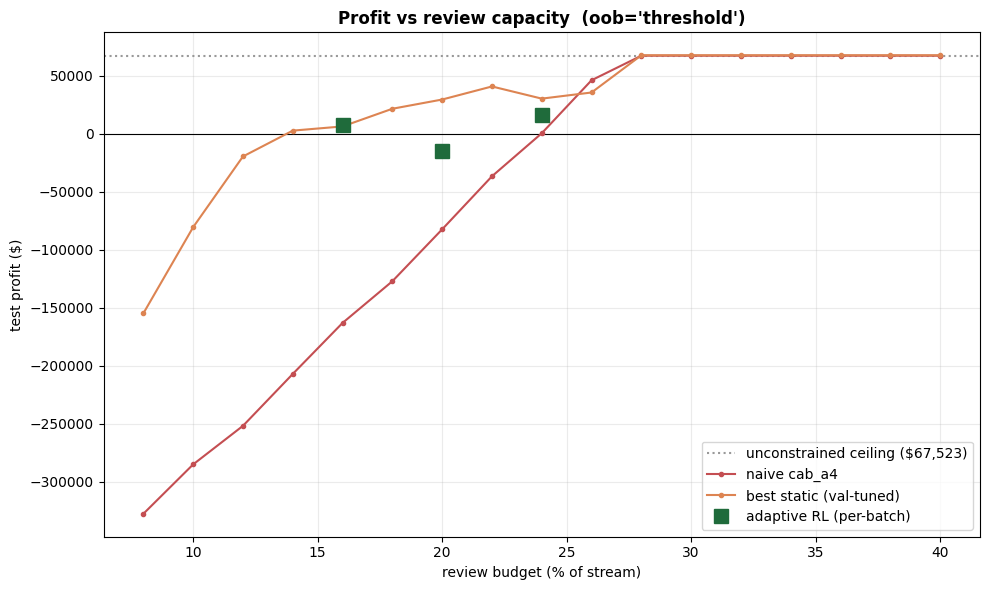

In [54]:
# ── Profit vs review-capacity curve ──
fig, ax = plt.subplots(figsize=(10, 6))
bx=[100*b for b in SWEEP_BUDGETS_FINE]
ax.axhline(0, color='k', lw=0.8)
ax.axhline(ceil, color='#999999', ls=':', lw=1.5, label=f'unconstrained ceiling (${ceil:,.0f})')
ax.plot(bx, sweep_naive,  '-o', ms=3, color='#C44E52', label='naive cab_a4')
ax.plot(bx, sweep_static, '-o', ms=3, color='#DD8452', label='best static (val-tuned)')
if sweep_adapt:
    ax_=[100*b for b in SWEEP_BUDGETS_ADAPT]
    means=[np.mean(sweep_adapt[b]) for b in SWEEP_BUDGETS_ADAPT]
    if any(len(sweep_adapt[b])>1 for b in SWEEP_BUDGETS_ADAPT):
        errs=[np.std(sweep_adapt[b]) for b in SWEEP_BUDGETS_ADAPT]
        ax.errorbar(ax_, means, yerr=errs, fmt='s', ms=9, color='#1F6B3B', capsize=4, label='adaptive RL (per-batch)')
    else:
        ax.plot(ax_, means, 's', ms=10, color='#1F6B3B', label='adaptive RL (per-batch)')
ax.set_xlabel('review budget (% of stream)'); ax.set_ylabel('test profit ($)')
ax.set_title(f"Profit vs review capacity  (oob='{SWEEP_OOB}')", fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

### Reading this curve

- Where **best-static crosses zero** is the system's viability threshold under this overflow rule. Compare it across `SWEEP_OOB`: under `'accept'` it sits far right (the 15% loss you saw); under `'threshold'`/`'reject'` it should move left (profitable at a much tighter budget).
- The **gap between adaptive (green) and best-static (orange)** *in the profitable region* is the real test. If green stays clearly above orange where both are positive, adaptive rationing has value you can defend; if they converge once profit turns positive, the honest headline is "adaptation only helps in the loss-avoidance regime (force-accept), not where the system is actually run."
- The **naive curve** is the cautionary tale: deploying the unconstrained policy as-is collapses fastest as the budget tightens.
- Caveats unchanged: single seed until you widen `SWEEP_SEEDS`; the val→test gap still applies (a binding budget is drift-sensitive), so read the *test* curve, not val.

In [55]:
# ── FINAL ATTEMPT: dense pacing-shaping (#1) + single-knob base_low control (#4) ──
import time
SK_OOB        = 'threshold'
SK_TRAIN      = True
SK_SEED       = 42
SK_CKPT       = f'{PPO_DIR}/cap_singleknob_s{SK_SEED}_{SK_OOB}.pt'
SK_BLO, SK_BHI = 0.14, 0.28        # budget range trained over
SK_EVAL_BUDGETS = (0.16, 0.20, 0.24)
SK_LR         = 1e-4
SK_ENTROPY    = 0.03
SK_SHAPE_W    = 1.5                 # weight on the one-sided overspending penalty (dense signal)
SK_BL_RANGE   = (MIN_T_LOW, 0.72)   # base_low can move in here (raise => fewer reviews)
SK_MAX_EP     = 3000
SK_PATIENCE   = 6

class CapacityShapedEnv:
    """Budget-conditional capacity env (budget level in s[4]) with a DENSE one-sided
    overspending penalty added to the RL reward only. cum_profit stays REAL profit
    (shaping never touches it), so checkpoint/eval read true profit."""
    def __init__(self, probs, labels, amounts, min_t_low, max_t_high,
                 budget_frac=0.20, batch_size=512, cp=None, oob='threshold', shape_w=0.0):
        self.p=np.asarray(probs,float); self.y=np.asarray(labels,int); self.A=np.asarray(amounts,float)
        self.cp=cp or COST_PARAMS; self.MIN_T_LOW=min_t_low; self.MAX_T_HIGH=max_t_high
        self.batch_size=batch_size; self.n=len(self.p); self.n_batches=self.n//batch_size
        self.budget_frac=float(budget_frac); self.oob=oob; self.shape_w=float(shape_w)
        logA=np.log1p(self.A); self.z=(logA-Z_LOGA_MEAN)/Z_LOGA_STD
        self.total_budget=max(1.0, self.budget_frac*self.n_batches*self.batch_size)
    def set_budget(self, bf):
        self.budget_frac=float(bf); self.total_budget=max(1.0, bf*self.n_batches*self.batch_size)
    def reset(self):
        self.ptr=0; self.budget_left=self.total_budget; self.cum_profit=0.0; self.n_reviewed=0; self.n_seen=0
        return self._state()
    def _state(self):
        frac=self.ptr/max(1,self.n_batches); brem=self.budget_left/self.total_budget
        pace=brem-(1.0-frac)
        bmean=self.p[self.ptr*self.batch_size:(self.ptr+1)*self.batch_size].mean() if self.ptr<self.n_batches else 0.0
        s=np.zeros(16, dtype=np.float32)
        s[0]=frac; s[1]=brem; s[2]=pace; s[3]=bmean; s[4]=(self.budget_frac-0.20)/0.10
        return s
    def step(self, action):
        cp=self.cp; pr,ltv,flm,rc,prev=cp['pr'],cp['ltv'],cp['flm'],cp['rc'],cp['prev']
        lo=self.ptr*self.batch_size; hi=min(lo+self.batch_size,self.n)
        p=self.p[lo:hi]; A=self.A[lo:hi]; y=self.y[lo:hi]; z=self.z[lo:hi]
        base_low,slope_low,base_high,slope_high=action
        T_low=base_low+slope_low*z; T_high=base_high+slope_high*z
        T_low=np.clip(T_low,self.MIN_T_LOW,self.MAX_T_HIGH-0.02); T_high=np.clip(T_high,T_low+0.01,self.MAX_T_HIGH)
        eff=np.minimum(np.maximum(T_low,rc/(flm*A+1e-6)),T_high-0.01)
        d=np.where(p<eff,0,np.where(p<T_high,2,1)).astype(int)
        rev_idx=np.where(d==2)[0]; n_des=len(rev_idx); n_grant=int(min(n_des, max(0.0,self.budget_left)))
        if n_grant<n_des:
            den=rev_idx[n_grant:]
            if   self.oob=='accept': d[den]=0
            elif self.oob=='reject': d[den]=1
            else:
                pstar=pr*(1+ltv)/(flm+pr*(1+ltv)+1e-12); d[den]=np.where(p[den]>=pstar,1,0)
        self.budget_left-=n_grant; self.n_reviewed+=n_grant; self.n_seen+=len(p)
        batch_profit=-transaction_cost(d,y,A,cp).sum(); self.cum_profit+=batch_profit
        self.ptr+=1; done=self.ptr>=self.n_batches
        frac_new=self.ptr/max(1,self.n_batches); brem_new=self.budget_left/self.total_budget
        overspend=max(0.0, (1.0-frac_new) - brem_new)              # >0 only when burning too fast
        reward=batch_profit/1000.0 - self.shape_w*overspend        # shaping affects RL signal only
        info={'cum_profit':self.cum_profit,'review_rate':self.n_reviewed/max(1,self.n_seen),
              'budget_remaining_ratio':brem_new}
        return self._state(), float(reward), done, info

class SingleKnobAgent(ContinuousPPOAgent):
    """1-D action -> base_low only; slope_low/base_high/slope_high FROZEN at the static optimum.
    Reuses ContinuousPPOAgent.update unchanged (dim-agnostic)."""
    def __init__(self, *args, frozen=(0.0,0.9,0.0), bl_lo=0.36, bl_hi=0.72, **kwargs):
        kwargs['action_dim']=1
        super().__init__(*args, **kwargs)
        self.slope_low, self.base_high, self.slope_high = (float(x) for x in frozen)
        self.bl_lo=float(bl_lo); self.bl_hi=float(bl_hi)
    def get_action(self, state, deterministic=False):
        st=torch.FloatTensor(state).unsqueeze(0).to(self.device)
        out=self.actor(st); mean,log_std=torch.chunk(out,2,dim=-1)
        log_std=torch.clamp(log_std,-2,2)
        dist=torch.distributions.Normal(mean, log_std.exp())
        raw=mean if deterministic else dist.rsample()
        a_sq=torch.sigmoid(raw)
        logp=dist.log_prob(raw).sum(-1,keepdim=True)
        logp-=torch.log(a_sq*(1-a_sq)+1e-6).sum(-1,keepdim=True)
        v=self.critic(st)
        bl=float(a_sq.cpu().detach().numpy().flatten()[0])
        base_low=self.bl_lo + bl*(self.bl_hi-self.bl_lo)
        params=np.array([base_low, self.slope_low, self.base_high, self.slope_high], dtype=float)
        return (params, logp.cpu().item(), v.cpu().detach().item(), raw.cpu().detach().numpy().flatten())

In [56]:
# ── ABLATION: is the triage gain from budget-PRESSURE, or just AMOUNT gating? ──
AB_OOB     = 'threshold'
AB_BUDGETS = [0.14,0.16,0.18,0.20,0.22,0.24,0.26]
KS_AMT     = [0.0,0.1,0.25,0.5,1.0,2.0,4.0]      # amount-only scale (no pressure factor)
KS_PRS     = [0.0,2.0,4.0,8.0,16.0,32.0]         # pressure-gated scale

class CapacityAblationEnv(CapacityConstrainedEnv):
    """eff_low bump with selectable gate: 'off' | 'amount' (k*relu(-z)) | 'pressure' (k*pressure*relu(-z))."""
    def __init__(self, *args, gate='off', k=0.0, **kwargs):
        super().__init__(*args, **kwargs); self.gate=gate; self.k=float(k)
    def step(self, action):
        cp=self.cp; pr,ltv,flm,rc,prev=cp['pr'],cp['ltv'],cp['flm'],cp['rc'],cp['prev']
        lo=self.ptr*self.batch_size; hi=min(lo+self.batch_size,self.n)
        p=self.p[lo:hi]; A=self.A[lo:hi]; y=self.y[lo:hi]; z=self.z[lo:hi]
        base_low,slope_low,base_high,slope_high=action
        T_low=base_low+slope_low*z; T_high=base_high+slope_high*z
        T_low=np.clip(T_low,self.MIN_T_LOW,self.MAX_T_HIGH-0.02); T_high=np.clip(T_high,T_low+0.01,self.MAX_T_HIGH)
        eff=np.minimum(np.maximum(T_low,rc/(flm*A+1e-6)),T_high-0.01)
        if self.k>0 and self.gate!='off':
            small=np.maximum(0.0,-z)
            if self.gate=='amount':
                bump=self.k*small
            else:
                frac=self.ptr/max(1,self.n_batches); brem=self.budget_left/self.total_budget
                bump=self.k*max(0.0,(1.0-frac)-brem)*small
            eff=np.minimum(eff+bump, T_high-0.01)
        d=np.where(p<eff,0,np.where(p<T_high,2,1)).astype(int)
        rev_idx=np.where(d==2)[0]; n_des=len(rev_idx); n_grant=int(min(n_des,max(0.0,self.budget_left)))
        if n_grant<n_des:
            den=rev_idx[n_grant:]
            if   self.oob=='accept': d[den]=0
            elif self.oob=='reject': d[den]=1
            else:
                pstar=pr*(1+ltv)/(flm+pr*(1+ltv)+1e-12); d[den]=np.where(p[den]>=pstar,1,0)
        self.budget_left-=n_grant; self.n_reviewed+=n_grant; self.n_seen+=len(p)
        batch_profit=-transaction_cost(d,y,A,cp).sum(); self.cum_profit+=batch_profit
        self.ptr+=1; done=self.ptr>=self.n_batches
        info={'cum_profit':self.cum_profit,'review_rate':self.n_reviewed/max(1,self.n_seen),
              'budget_remaining_ratio':self.budget_left/self.total_budget}
        return self._state(), float(batch_profit/1000.0), done, info

def _ab(P,L,A,bf,gate,k): return CapacityAblationEnv(P,L,A,MIN_T_LOW,MAX_T_HIGH,budget_frac=bf,oob=AB_OOB,gate=gate,k=k)
def _bestk(bf, base, gate, ks):
    bk,bv=0.0,-np.inf
    for k in ks:
        v,_,_=capacity_rollout(_ab(val_probs,true_val_labels,val_amounts,bf,gate,k), base)
        if v>bv: bv,bk=v,k
    return bk

ab_fv=[]; ab_fo=[]; ab_amt=[]; ab_prs=[]; ab_ka=[]; ab_kp=[]
for bf in AB_BUDGETS:
    base_v,_=best_static_under_budget(cab_a4, bf, split='val',  oob=AB_OOB)
    base_t,_=best_static_under_budget(cab_a4, bf, split='test', oob=AB_OOB)   # ORACLE (cheats; diagnostic only)
    fv,_,_=capacity_rollout(_ab(test_probs,true_test_labels,test_amounts,bf,'off',0.0), base_v)
    fo,_,_=capacity_rollout(_ab(test_probs,true_test_labels,test_amounts,bf,'off',0.0), base_t)
    ka=_bestk(bf, base_v, 'amount',   KS_AMT); kp=_bestk(bf, base_v, 'pressure', KS_PRS)
    ta,_,_=capacity_rollout(_ab(test_probs,true_test_labels,test_amounts,bf,'amount',  ka), base_v)
    tp,_,_=capacity_rollout(_ab(test_probs,true_test_labels,test_amounts,bf,'pressure',kp), base_v)
    ab_fv.append(fv); ab_fo.append(fo); ab_amt.append(ta); ab_prs.append(tp); ab_ka.append(ka); ab_kp.append(kp)

print(f"ABLATION  (all numbers TEST $)   oob='{AB_OOB}'   [flat-oracle CHEATS on test - diagnostic only]")
print(" budget | flat(val) | flat(oracle) | amount-only | full triage |  ka  |  kp")
for bf,fv,fo,ta,tp,ka,kp in zip(AB_BUDGETS,ab_fv,ab_fo,ab_amt,ab_prs,ab_ka,ab_kp):
    print(f"  {100*bf:4.0f}% | ${fv:>8,.0f} | ${fo:>11,.0f} | ${ta:>10,.0f} | ${tp:>10,.0f} | {ka:>4g} | {kp:>4g}")

amt=[a-f for a,f in zip(ab_amt,ab_fv)]; prs=[p-f for p,f in zip(ab_prs,ab_fv)]
pva=[p-a for p,a in zip(ab_prs,ab_amt)]; pvo=[p-o for p,o in zip(ab_prs,ab_fo)]
print(f"\n  amount-only  vs flat(val):    mean ${np.mean(amt):>+9,.0f}")
print(f"  full triage  vs flat(val):    mean ${np.mean(prs):>+9,.0f}")
print(f"  full triage  vs amount-only:  mean ${np.mean(pva):>+9,.0f}  (>0 => budget-PRESSURE gating adds real value)")
print(f"  full triage  vs flat(oracle): mean ${np.mean(pvo):>+9,.0f}  (>0 => triage beats the BEST possible flat policy)")
print("\n  full ~= amount-only  => gain is better AMOUNT-conditioning; fold into core finding (not 'adaptive').")
print("  full >> amount-only  => budget-pressure adaptation is real; keep it in the capacity section.")
print("  full <= flat(oracle) => triage mostly papers over a weak val-tuned base; honest gain = tight budgets only.")

ABLATION  (all numbers TEST $)   oob='threshold'   [flat-oracle CHEATS on test - diagnostic only]
 budget | flat(val) | flat(oracle) | amount-only | full triage |  ka  |  kp
    14% | $   2,861 | $     20,584 | $     2,861 | $     2,861 |    0 |    0
    16% | $   6,488 | $     33,182 | $     6,488 | $    15,887 |    0 |    8
    18% | $  21,739 | $     45,680 | $    21,739 | $    34,776 |    0 |   16
    20% | $  29,698 | $     54,012 | $    29,698 | $    29,698 |    0 |    0
    22% | $  40,971 | $     59,627 | $    40,971 | $    40,971 |    0 |    0
    24% | $  30,475 | $     64,445 | $    30,475 | $    58,387 |    0 |   32
    26% | $  35,764 | $     66,985 | $    35,764 | $    48,655 |    0 |    2

  amount-only  vs flat(val):    mean $       +0
  full triage  vs flat(val):    mean $   +9,034
  full triage  vs amount-only:  mean $   +9,034  (>0 => budget-PRESSURE gating adds real value)
  full triage  vs flat(oracle): mean $  -16,183  (>0 => triage beats the BEST possible flat po

In [57]:
# ── Drift diagnostic: is the val->test gap TEMPORAL, or just variance? ──
# Oracle gap = profit lost by tuning the static policy on the 'val' pool instead of
# directly on the 'test' pool (measured on test). We compare this gap under the REAL
# chronological split vs RANDOM re-partitions of the SAME scored data (time order destroyed).
# No RL here - this isolates drift in the classifier SCORES, the dominant effect.
DRIFT_OOB     = 'threshold'
DRIFT_BUDGETS = [0.16, 0.20, 0.24]
DRIFT_SEEDS   = [0, 1, 2, 3]
GRID_LO = np.linspace(-0.08, 0.24, 9); GRID_HI = np.linspace(-0.20, 0.05, 6)

def _mkE(P,L,A,bf): return CapacityConstrainedEnv(P,L,A,MIN_T_LOW,MAX_T_HIGH,budget_frac=bf,oob=DRIFT_OOB)
def _tune(P,L,A,bf):
    best=cab_a4.copy().astype(float); bp=-np.inf
    for dlo in GRID_LO:
        for dhi in GRID_HI:
            a=cab_a4.copy().astype(float); a[0]+=dlo; a[2]+=dhi
            p,_,_=capacity_rollout(_mkE(P,L,A,bf), a)
            if p>bp: bp,best=p,a
    return best
def _evl(a,P,L,A,bf): return capacity_rollout(_mkE(P,L,A,bf), a)[0]
def oracle_gap(Pt,Lt,At, Pe,Le,Ae, bf):
    a_val =_tune(Pt,Lt,At,bf)                 # tuned on the 'val' pool
    a_test=_tune(Pe,Le,Ae,bf)                 # tuned directly on 'test' (oracle)
    return _evl(a_test,Pe,Le,Ae,bf) - _evl(a_val,Pe,Le,Ae,bf)

print(f"oob='{DRIFT_OOB}'  | oracle gap = profit lost tuning on 'val' vs 'test', measured on test\n")

# --- CHRONOLOGICAL (the real split): val=earlier, test=later ---
print("CHRONOLOGICAL split (the real one):")
chrono=[]
for bf in DRIFT_BUDGETS:
    g=oracle_gap(val_probs,true_val_labels,val_amounts, test_probs,true_test_labels,test_amounts, bf)
    chrono.append(g); print(f"  budget {100*bf:4.0f}%  oracle gap ${g:>10,.0f}")
print(f"  >> mean chronological oracle gap = ${np.mean(chrono):,.0f}\n")

# --- RANDOM re-partition of the SAME scored (val+test) data ---
P_all=np.concatenate([val_probs,test_probs]); L_all=np.concatenate([true_val_labels,true_test_labels])
A_all=np.concatenate([val_amounts,test_amounts]); n_val=len(val_probs); N=len(P_all)
print("RANDOM re-partition (identical scores, time order destroyed):")
rand_means=[]
for sd in DRIFT_SEEDS:
    rng=np.random.default_rng(sd); idx=rng.permutation(N); vi,ti=idx[:n_val],idx[n_val:]
    gs=[oracle_gap(P_all[vi],L_all[vi],A_all[vi], P_all[ti],L_all[ti],A_all[ti], bf) for bf in DRIFT_BUDGETS]
    rand_means.append(np.mean(gs)); print(f"  seed {sd}: mean oracle gap ${np.mean(gs):>10,.0f}")
print(f"  >> mean RANDOM oracle gap = ${np.mean(rand_means):,.0f}  (+/- ${np.std(rand_means):,.0f})\n")

c, r = np.mean(chrono), np.mean(rand_means)
print("VERDICT")
print(f"  chronological ${c:,.0f}   vs   random ${r:,.0f}   (ratio {c/(abs(r)+1e-9):.1f}x)")
print("  chrono >> random  => gap is TEMPORAL concept drift. A 4-way split will NOT fix it; report it as the finding.")
print("  chrono ~= random  => gap is sampling/tuning variance, not temporal drift (a 4-way split won't help either).")
print("\n  Note: this is the static frontier (no RL). The drift lives in the classifier scores across time,")
print("        so it is upstream of the RL agent - re-splitting the RL training data cannot remove it.")

oob='threshold'  | oracle gap = profit lost tuning on 'val' vs 'test', measured on test

CHRONOLOGICAL split (the real one):
  budget   16%  oracle gap $    26,695
  budget   20%  oracle gap $    24,314
  budget   24%  oracle gap $    33,970
  >> mean chronological oracle gap = $28,326

RANDOM re-partition (identical scores, time order destroyed):
  seed 0: mean oracle gap $       822
  seed 1: mean oracle gap $       915
  seed 2: mean oracle gap $     1,066
  seed 3: mean oracle gap $         0
  >> mean RANDOM oracle gap = $701  (+/- $414)

VERDICT
  chronological $28,326   vs   random $701   (ratio 40.4x)
  chrono >> random  => gap is TEMPORAL concept drift. A 4-way split will NOT fix it; report it as the finding.
  chrono ~= random  => gap is sampling/tuning variance, not temporal drift (a 4-way split won't help either).

  Note: this is the static frontier (no RL). The drift lives in the classifier scores across time,
        so it is upstream of the RL agent - re-splitting the R

In [58]:
# ============================================================
# TRAJECTORY-OVERFIT CONTROL: randomized training windows
# Only change vs the single-knob run is the TRAINING env. Eval is full-stream.
# Requires the single-knob cell (SingleKnobAgent, CapacityShapedEnv, SK_* flags) to have run.
# ============================================================
SKR_TRAIN = True
cab_a4    = np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')
SK_FROZEN = (float(cab_a4[1]), float(cab_a4[2]), float(cab_a4[3]))
SKR_CKPT  = f'{PPO_DIR}/cap_singleknob_RANDOM_s{SK_SEED}_{SK_OOB}.pt'

class CapacityShapedEnvRandom(CapacityShapedEnv):
    """TRAINING-ONLY: each episode is a random contiguous chunk (random start + length),
    budget scaled to the chunk, progress measured RELATIVE to the chunk. This removes the
    position->transaction memorization that s[0]=frac enables when replaying one fixed stream."""
    def reset(self):
        mb = self.n_batches
        keep  = int(np.random.randint(max(1, int(mb*0.50)), max(2, int(mb*0.90))))
        start = int(np.random.randint(0, max(1, mb - keep)))
        self.start_batch=start; self.chunk_batches=keep; self.end_batch=start+keep
        self.ptr=start
        self.total_budget=max(1.0, self.budget_frac*keep*self.batch_size)   # chunk-proportional budget
        self.budget_left=self.total_budget; self.cum_profit=0.0
        self.n_reviewed=0; self.n_seen=0
        return self._state()
    def _state(self):
        frac=(self.ptr-self.start_batch)/max(1, self.chunk_batches)         # CHUNK-relative progress
        brem=self.budget_left/self.total_budget; pace=brem-(1.0-frac)
        bmean=self.p[self.ptr*self.batch_size:(self.ptr+1)*self.batch_size].mean() if self.ptr<self.end_batch else 0.0
        s=np.zeros(16,dtype=np.float32)
        s[0]=frac; s[1]=brem; s[2]=pace; s[3]=bmean; s[4]=(self.budget_frac-0.20)/0.10
        return s
    def step(self, action):
        cp=self.cp; pr,ltv,flm,rc,prev=cp['pr'],cp['ltv'],cp['flm'],cp['rc'],cp['prev']
        lo=self.ptr*self.batch_size; hi=min(lo+self.batch_size,self.n)
        p=self.p[lo:hi]; A=self.A[lo:hi]; y=self.y[lo:hi]; z=self.z[lo:hi]
        base_low,slope_low,base_high,slope_high=action
        T_low=base_low+slope_low*z; T_high=base_high+slope_high*z
        T_low=np.clip(T_low,self.MIN_T_LOW,self.MAX_T_HIGH-0.02); T_high=np.clip(T_high,T_low+0.01,self.MAX_T_HIGH)
        eff=np.minimum(np.maximum(T_low,rc/(flm*A+1e-6)),T_high-0.01)
        d=np.where(p<eff,0,np.where(p<T_high,2,1)).astype(int)
        rev_idx=np.where(d==2)[0]; n_des=len(rev_idx); n_grant=int(min(n_des,max(0.0,self.budget_left)))
        if n_grant<n_des:
            den=rev_idx[n_grant:]
            if   self.oob=='accept': d[den]=0
            elif self.oob=='reject': d[den]=1
            else:
                pstar=pr*(1+ltv)/(flm+pr*(1+ltv)+1e-12); d[den]=np.where(p[den]>=pstar,1,0)
        self.budget_left-=n_grant; self.n_reviewed+=n_grant; self.n_seen+=len(p)
        batch_profit=-transaction_cost(d,y,A,cp).sum(); self.cum_profit+=batch_profit
        self.ptr+=1
        done = self.ptr >= self.end_batch                                   # chunk end, not full stream
        frac_new=(self.ptr-self.start_batch)/max(1,self.chunk_batches); brem_new=self.budget_left/self.total_budget
        overspend=max(0.0,(1.0-frac_new)-brem_new)
        reward=batch_profit/1000.0 - self.shape_w*overspend
        info={'cum_profit':self.cum_profit,'review_rate':self.n_reviewed/max(1,self.n_seen),'budget_remaining_ratio':brem_new}
        return self._state(), float(reward), done, info

def train_singleknob_random(checkpoint_path):
    torch.manual_seed(SK_SEED); np.random.seed(SK_SEED)
    try: torch.mps.manual_seed(SK_SEED)
    except Exception: pass
    agent=SingleKnobAgent(16, lr=SK_LR, gamma=0.99, entropy_coef=SK_ENTROPY, minibatch_size=128,
                          frozen=SK_FROZEN, bl_lo=SK_BL_RANGE[0], bl_hi=SK_BL_RANGE[1])
    env=CapacityShapedEnvRandom(val_probs,true_val_labels,val_amounts,MIN_T_LOW,MAX_T_HIGH,
                                budget_frac=0.20,oob=SK_OOB,shape_w=SK_SHAPE_W)            # randomized chunks
    eval_envs=[CapacityShapedEnv(val_probs,true_val_labels,val_amounts,MIN_T_LOW,MAX_T_HIGH,
                                 budget_frac=bf,oob=SK_OOB,shape_w=0.0) for bf in SK_EVAL_BUDGETS]  # FULL stream
    best=-np.inf; since=0; rng=np.random.default_rng(SK_SEED)
    traj={k:[] for k in ('states','raw_actions','log_probs','rewards','dones','values')}
    for ep in range(1,SK_MAX_EP+1):
        env.set_budget(float(rng.uniform(SK_BLO,SK_BHI)))
        st=env.reset(); done=False
        while not done:
            a,lp,v,raw=agent.get_action(st); ns,r,done,_=env.step(a)
            for k,val in zip(traj,(st,raw,lp,r,float(done),v)): traj[k].append(val)
            st=ns
        if ep%5==0: agent.update(traj); traj={k:[] for k in traj}
        if ep%200==0:
            mv=float(np.mean([capacity_rollout(e, lambda s2: agent.get_action(s2,deterministic=True)[0])[0]
                              for e in eval_envs]))                          # full-stream real profit
            if mv>best+1e-6: best=mv; since=0; agent.save(checkpoint_path)
            else:
                since+=1
                if since>=SK_PATIENCE: print(f"      early stop @ ep {ep} (best full-val ${best:,.0f})"); break
            print(f"  ep {ep:5d} | full-stream mean-val ${mv:>9,.0f} | best ${best:>9,.0f}", flush=True)
    return best

In [59]:
# ── MULTI-SEED SKR: is the +$15k-over-val-static win stable, and what is the seed noise floor? ──
# Retrains the randomized-window single-knob agent at several seeds; evals each on the FULL stream.
# Reuses CapacityShapedEnvRandom, train_singleknob_random, SingleKnobAgent, SK_* flags, cab_a4.
MS_SEEDS   = [1,2, 3, 42, 7]          # 5 seeds; trim if time-limited (each ~25-40 min)
MS_BUDGETS = [0.14,0.16,0.18,0.20,0.22,0.24,0.26]
MS_OOB     = SK_OOB

# precompute the two static references per budget (deterministic, seed-independent)
_sval={}; _sora={}
for bf in MS_BUDGETS:
    bv,_=best_static_under_budget(cab_a4, bf, split='val',  oob=MS_OOB)
    bo,_=best_static_under_budget(cab_a4, bf, split='test', oob=MS_OOB)
    _sval[bf]=capacity_rollout(CapacityConstrainedEnv(test_probs,true_test_labels,test_amounts,
              MIN_T_LOW,MAX_T_HIGH,budget_frac=bf,oob=MS_OOB), bv)[0]
    _sora[bf]=capacity_rollout(CapacityConstrainedEnv(test_probs,true_test_labels,test_amounts,
              MIN_T_LOW,MAX_T_HIGH,budget_frac=bf,oob=MS_OOB), bo)[0]

def _train_seed(seed):
    # same as train_singleknob_random but with an explicit seed + per-seed checkpoint
    global SK_SEED
    _saved=SK_SEED; SK_SEED=seed
    ckpt=f'{PPO_DIR}/cap_singleknob_RANDOM_s{seed}_{MS_OOB}.pt'
    if not os.path.exists(ckpt):
        import time as _t; t0=_t.time(); print(f"  seed {seed}: training ...", flush=True)
        train_singleknob_random(ckpt); print(f"    done {(_t.time()-t0)/60:.0f} min", flush=True)
    SK_SEED=_saved
    return ckpt

def _eval_agent(ckpt, P,L,A,bf):
    ag=SingleKnobAgent(16, lr=SK_LR, gamma=0.99, entropy_coef=SK_ENTROPY, minibatch_size=128,
                       frozen=SK_FROZEN, bl_lo=SK_BL_RANGE[0], bl_hi=SK_BL_RANGE[1]); ag.load(ckpt)
    return capacity_rollout(CapacityShapedEnv(P,L,A,MIN_T_LOW,MAX_T_HIGH,budget_frac=bf,oob=MS_OOB,shape_w=0.0),
                            lambda s2: ag.get_action(s2,deterministic=True)[0])[0]

# skr_test[bf] = list of test profits across seeds
skr_test={bf:[] for bf in MS_BUDGETS}
for sd in MS_SEEDS:
    ck=_train_seed(sd)
    for bf in MS_BUDGETS:
        skr_test[bf].append(_eval_agent(ck, test_probs,true_test_labels,test_amounts,bf))

print(f"\nMULTI-SEED SKR (n={len(MS_SEEDS)} seeds, TEST, oob='{MS_OOB}')")
print(" budget |  SKR test mean +/- sd  | static(val) | SKR-val mean | static(ORACLE) | SKR-oracle mean")
dv_means=[]; do_means=[]
for bf in MS_BUDGETS:
    arr=np.array(skr_test[bf]); m,sd_=arr.mean(),arr.std()
    dv=m-_sval[bf]; do=m-_sora[bf]; dv_means.append(dv); do_means.append(do)
    print(f"  {100*bf:4.0f}% | ${m:>9,.0f} +/- ${sd_:>7,.0f} | ${_sval[bf]:>10,.0f} | ${dv:>+11,.0f} | ${_sora[bf]:>12,.0f} | ${do:>+13,.0f}")

allseed_sd=np.mean([np.std(skr_test[bf]) for bf in MS_BUDGETS])
print(f"\n  NOISE FLOOR: mean per-budget seed sd = ${allseed_sd:,.0f}  (any tuning gain must exceed ~2x this to be real)")
print(f"  SKR vs VAL-tuned static : mean ${np.mean(dv_means):>+,.0f}  | beats it at "
      f"{sum(1 for bf in MS_BUDGETS if np.mean(skr_test[bf])>_sval[bf])}/{len(MS_BUDGETS)} budgets")
print(f"  SKR vs ORACLE   static  : mean ${np.mean(do_means):>+,.0f}  | beats it at "
      f"{sum(1 for bf in MS_BUDGETS if np.mean(skr_test[bf])>_sora[bf])}/{len(MS_BUDGETS)} budgets")
print("\n  READ:")
print("    (a) SKR-val mean stays clearly positive AND sd is small => the win over deployable static is REAL & stable.")
print("    (b) sd is large / SKR-val swings sign across seeds       => single-seed win was a lucky draw; report as a tie.")
print("    (c) compare any later shaping/range tweak to the NOISE FLOOR above, not to a single seed.")


MULTI-SEED SKR (n=5 seeds, TEST, oob='threshold')
 budget |  SKR test mean +/- sd  | static(val) | SKR-val mean | static(ORACLE) | SKR-oracle mean
    14% | $  -50,854 +/- $ 50,331 | $     2,861 | $    -53,716 | $      20,584 | $      -71,439
    16% | $  -10,094 +/- $ 36,423 | $     6,488 | $    -16,582 | $      33,182 | $      -43,276
    18% | $   19,281 +/- $ 21,828 | $    21,739 | $     -2,458 | $      45,680 | $      -26,399
    20% | $   39,919 +/- $  4,738 | $    29,698 | $    +10,221 | $      54,012 | $      -14,093
    22% | $   48,099 +/- $  8,967 | $    40,971 | $     +7,128 | $      59,627 | $      -11,528
    24% | $   49,913 +/- $  9,031 | $    30,475 | $    +19,438 | $      64,445 | $      -14,532
    26% | $   52,563 +/- $  7,721 | $    35,764 | $    +16,799 | $      66,985 | $      -14,422

  NOISE FLOOR: mean per-budget seed sd = $19,863  (any tuning gain must exceed ~2x this to be real)
  SKR vs VAL-tuned static : mean $-2,738  | beats it at 4/7 budgets
  SKR vs OR

In [60]:
# ── LEAKAGE-FREE forward-chaining CV for the triage k-rule ──
# k* is selected ONLY on windows strictly EARLIER than the eval window (no future leakage),
# unlike the earlier CV where k=16 was chosen on the full test set. Requires _ab from the ablation cell.
LF_OOB='threshold'; LF_K_WINDOWS=4
LF_BUDGETS=[0.14,0.16,0.18,0.20,0.22,0.24,0.26]
LF_KGRID=[0,4,8,12,16,20,24,28,32]

def _lf_slices(n,k):
    bnd=np.linspace(0,n,k+1).astype(int); return [(bnd[i],bnd[i+1]) for i in range(k)]
sl=_lf_slices(len(test_probs), LF_K_WINDOWS)

def _tri_profit(wi, bf, kk, base):
    a,b=sl[wi]; P,L,A=test_probs[a:b],true_test_labels[a:b],test_amounts[a:b]
    return capacity_rollout(_ab(P,L,A,bf,'pressure',kk), base)[0]
def _flat_profit(wi, bf, base):
    a,b=sl[wi]; P,L,A=test_probs[a:b],true_test_labels[a:b],test_amounts[a:b]
    return capacity_rollout(_ab(P,L,A,bf,'off',0.0), base)[0]

print(f"Leakage-free forward-chaining CV (triage k-rule, oob='{LF_OOB}', {LF_K_WINDOWS} chronological test windows)\n")
print("  k* chosen on windows strictly BEFORE each eval window; OOS gain = triage(k*) - flat on the held-out window")
print(" eval win | budget | k* (earlier) | flat      | triage(k*) | OOS gain")
all_gains=[]; gains_by_win={}
for i in range(1, LF_K_WINDOWS):                 # eval windows index 1..K-1 (W2..WK)
    train_idx=list(range(0,i)); ev=i
    for bf in LF_BUDGETS:
        base,_=best_static_under_budget(cab_a4, bf, split='val', oob=LF_OOB)   # deployable base (val < test)
        kstar=LF_KGRID[0]; bestg=-np.inf                                        # k=0 (off) is the fallback
        for kk in LF_KGRID:
            g=sum(_tri_profit(wi,bf,kk,base)-_flat_profit(wi,bf,base) for wi in train_idx)
            if g>bestg: bestg,kstar=g,kk
        f=_flat_profit(ev,bf,base); t=_tri_profit(ev,bf,kstar,base)
        all_gains.append(t-f); gains_by_win.setdefault(ev,[]).append(t-f)
        print(f"   W{ev+1}    | {100*bf:4.0f}% | {kstar:>2.0f} (W1..W{i}) | ${f:>8,.0f} | ${t:>9,.0f} | ${t-f:>+9,.0f}")

ga=np.array(all_gains); m=ga.mean(); se=ga.std(ddof=1)/np.sqrt(len(ga))
wins=int((ga>1e-6).sum()); ties=int((np.abs(ga)<=1e-6).sum()); losses=int((ga<-1e-6).sum())
print(f"\n  per-eval-window mean OOS gain:")
for ev in sorted(gains_by_win):
    arr=np.array(gains_by_win[ev]); print(f"    W{ev+1}: ${arr.mean():>+8,.0f}")
print(f"\n  OOS evaluations: {len(ga)}  | wins {wins} / ties {ties} / losses {losses}")
print(f"  MEAN OOS gain = ${m:>+,.0f}   (s.e. ${se:,.0f})   median ${np.median(ga):>+,.0f}")
print(f"  rough t vs zero = {m/(se+1e-9):.2f}   (note: budget rows within a window are correlated, so this OVERSTATES significance)")
print("\n  READ:")
print("    mean clearly >0, t>~2, most windows positive => triage adds real OUT-OF-SAMPLE value; report the honest number.")
print("    mean ~0 / t<2 / k* often 0                   => the earlier +$3k was k-selection leakage; honest effect ~zero.")

Leakage-free forward-chaining CV (triage k-rule, oob='threshold', 4 chronological test windows)

  k* chosen on windows strictly BEFORE each eval window; OOS gain = triage(k*) - flat on the held-out window
 eval win | budget | k* (earlier) | flat      | triage(k*) | OOS gain
   W2    |   14% | 32 (W1..W1) | $  -2,561 | $   -1,855 | $     +706
   W2    |   16% | 32 (W1..W1) | $  -2,443 | $     -385 | $   +2,058
   W2    |   18% | 12 (W1..W1) | $   1,092 | $    4,459 | $   +3,367
   W2    |   20% | 16 (W1..W1) | $   2,292 | $   10,469 | $   +8,177
   W2    |   22% |  4 (W1..W1) | $   4,238 | $   11,427 | $   +7,188
   W2    |   24% | 20 (W1..W1) | $   2,061 | $   15,285 | $  +13,225
   W2    |   26% |  8 (W1..W1) | $   3,371 | $   14,386 | $  +11,015
   W3    |   14% | 32 (W1..W2) | $   2,902 | $    2,505 | $     -398
   W3    |   16% | 24 (W1..W2) | $   3,399 | $    5,655 | $   +2,255
   W3    |   18% | 28 (W1..W2) | $   8,694 | $    8,907 | $     +214
   W3    |   20% | 32 (W1..W2) | $

In [61]:
# ── Forward-chaining CV at larger K to firm up the n=3 sample-size concern ──
# Same leakage-free protocol (k* chosen on strictly-earlier windows); more eval windows.
# Significance is computed across WINDOW means (honest n = K-1), not the correlated budget rows.
LF2_OOB='threshold'
LF2_BUDGETS=[0.14,0.16,0.18,0.20,0.22,0.24,0.26]
LF2_KGRID=[0,4,8,12,16,20,24,28,32]

def _fc_run(K):
    bnd=np.linspace(0,len(test_probs),K+1).astype(int); sl=[(bnd[i],bnd[i+1]) for i in range(K)]
    def tri(wi,bf,kk,base):
        a,b=sl[wi]; return capacity_rollout(_ab(test_probs[a:b],true_test_labels[a:b],test_amounts[a:b],bf,'pressure',kk), base)[0]
    def flt(wi,bf,base):
        a,b=sl[wi]; return capacity_rollout(_ab(test_probs[a:b],true_test_labels[a:b],test_amounts[a:b],bf,'off',0.0), base)[0]
    win_means=[]; all_rows=[]
    for i in range(1,K):                         # eval windows index 1..K-1
        train=list(range(0,i)); gains=[]
        for bf in LF2_BUDGETS:
            base,_=best_static_under_budget(cab_a4,bf,split='val',oob=LF2_OOB)   # val-tuned base (before test)
            flat_tr=[flt(wi,bf,base) for wi in train]
            kstar=LF2_KGRID[0]; bg=-np.inf
            for kk in LF2_KGRID:
                g=sum(tri(wi,bf,kk,base)-ft for wi,ft in zip(train,flat_tr))      # select k on EARLIER windows
                if g>bg: bg,kstar=g,kk
            gains.append(tri(i,bf,kstar,base)-flt(i,bf,base))                     # eval on held-out later window
        win_means.append(float(np.mean(gains))); all_rows.extend(gains)
    return np.array(win_means), np.array(all_rows)

print("Leakage-free forward-chaining CV across window counts (triage k-rule)\n")
for K in [4,6,8]:
    wm, rows = _fc_run(K)
    m=wm.mean(); se=wm.std(ddof=1)/np.sqrt(len(wm)); t=m/(se+1e-9)
    pos=int((rows>1e-6).sum())
    print(f"K={K}: {len(wm)} eval windows | per-window means {['$%s'%format(int(x),',') for x in wm]}")
    print(f"      mean OOS gain ${m:>+,.0f}   window-level s.e. ${se:,.0f}   t={t:.2f}   | row-level {pos}/{len(rows)} positive\n")

print("READ (judge on the window-level t, n=K-1):")
print("  mean stays ~$3-5k with t>2 across K=6,8  => robust to windowing; a genuine (if modest) finding.")
print("  mean shrinks / t<2 as K grows            => the K=4 result leaned on 3 favorable points; report as suggestive only.")

Leakage-free forward-chaining CV across window counts (triage k-rule)

K=4: 3 eval windows | per-window means ['$6,533', '$876', '$6,532']
      mean OOS gain $+4,648   window-level s.e. $1,886   t=2.46   | row-level 19/21 positive

K=6: 5 eval windows | per-window means ['$679', '$6,439', '$2,206', '$1,410', '$3,574']
      mean OOS gain $+2,862   window-level s.e. $1,015   t=2.82   | row-level 34/35 positive

K=8: 7 eval windows | per-window means ['$208', '$2,472', '$4,819', '$2,319', '$15', '$1,826', '$2,262']
      mean OOS gain $+1,989   window-level s.e. $608   t=3.27   | row-level 42/49 positive

READ (judge on the window-level t, n=K-1):
  mean stays ~$3-5k with t>2 across K=6,8  => robust to windowing; a genuine (if modest) finding.
  mean shrinks / t<2 as K grows            => the K=4 result leaned on 3 favorable points; report as suggestive only.


In [62]:
# ── DERIVE shared references: K_FINAL (triage coeff) + CEIL (true unconstrained ceiling) ──
# Standalone so display cells (comparison / staffing / configurator) only CONSUME these.
# Deps: _ab (ablation), best_static_under_budget / capacity_rollout / CapacityConstrainedEnv (cap infra), cab_a4.
KFINAL_OOB     = 'threshold'
KFINAL_KGRID   = [0, 4, 8, 12, 16, 20, 24, 28, 32]
KFINAL_BUDGETS = [round(b,2) for b in np.arange(0.14, 0.281, 0.02)]
cab_a4 = np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')

# --- K_FINAL: triage coefficient selected on VALIDATION (deployable; no test leakage) ---
def _kfinal_val_gain(k):
    g=[]
    for bf in KFINAL_BUDGETS:
        ba,_=best_static_under_budget(cab_a4, bf, split='val', oob=KFINAL_OOB)
        tri=capacity_rollout(_ab(val_probs,true_val_labels,val_amounts,bf,'pressure',k), ba)[0]
        fl =capacity_rollout(_ab(val_probs,true_val_labels,val_amounts,bf,'off',0.0),    ba)[0]
        g.append(tri-fl)
    return float(np.mean(g))
K_FINAL = max(KFINAL_KGRID, key=_kfinal_val_gain)

# --- CEIL: TRUE unconstrained ceiling = best static at non-binding budget, tuned on TEST (oracle upper bound) ---
# This is a genuine maximum: no deployable policy can exceed it, so "% of ceiling" is always <= 100%.
# (Raw cab_a4 unconstrained is NOT a valid ceiling - a better-tuned static beats it, giving >100%.)
_oracle_base,_ = best_static_under_budget(cab_a4, 1.0, split='test', oob=KFINAL_OOB)
CEIL = capacity_rollout(CapacityConstrainedEnv(test_probs,true_test_labels,test_amounts,
                        MIN_T_LOW,MAX_T_HIGH,budget_frac=1.0,oob=KFINAL_OOB), _oracle_base)[0]
_cabA4_unconstrained = amountcond_metrics(cab_a4, test_probs, true_test_labels, test_amounts)['model_profit']

print(f"K_FINAL = {K_FINAL}   (triage coeff selected on validation; mean val gain ${_kfinal_val_gain(K_FINAL):,.0f}/budget)")
print(f"CEIL    = ${CEIL:,.0f}   (TRUE unconstrained ceiling = test-tuned static at unlimited review; genuine upper bound)")
print(f"  ref: raw cab_a4 unconstrained = ${_cabA4_unconstrained:,.0f} ({100*_cabA4_unconstrained/CEIL:.0f}% of true ceiling)")
print(f"       -> raw cab_a4 is below the true ceiling; better-tuned static reaches the rest. % of CEIL is now <= 100%.")
print("  Consumed by: consolidated comparison, staffing table, deployable configurator (all should use this CEIL).")

K_FINAL = 8   (triage coeff selected on validation; mean val gain $15/budget)
CEIL    = $67,886   (TRUE unconstrained ceiling = test-tuned static at unlimited review; genuine upper bound)
  ref: raw cab_a4 unconstrained = $67,530 (99% of true ceiling)
       -> raw cab_a4 is below the true ceiling; better-tuned static reaches the rest. % of CEIL is now <= 100%.
  Consumed by: consolidated comparison, staffing table, deployable configurator (all should use this CEIL).


CAPACITY SUMMARY (Test, oob='threshold', seeds=[1, 2, 3, 42, 7])   unconstrained ceiling=$67,886
  [oracle = test-tuned STATIC: undeployable upper bound of a flat policy; gap to static(val) = the drift cost]
 budget | naive(cap) | static(val) | static+triage(k=8 ) | adaptive RL (mean +/- sd) | oracle(static)| s%c|t%c|a%c|o%c
    16% | $ -163,030 | $     6,488 | $           15,887 | $ -10,094 +/- $ 36,423 | $     33,182 |  10| 23|-15| 49
    20% | $  -82,268 | $    29,698 | $           41,571 | $  39,919 +/- $  4,738 | $     54,012 |  44| 61| 59| 80
    24% | $      615 | $    30,475 | $           51,127 | $  49,913 +/- $  9,031 | $     64,445 |  45| 75| 74| 95
    26% | $   46,332 | $    35,764 | $           58,455 | $  52,563 +/- $  7,721 | $     66,985 |  53| 86| 77| 99
    28% | $   67,523 | $    67,886 | $           67,886 | $  57,553 +/- $  9,206 * | $     67,886 | 100|100| 85|100
  * adaptive at 28% is at the edge of its 0.14-0.28 training-budget range (treat as noisier).
  Note:

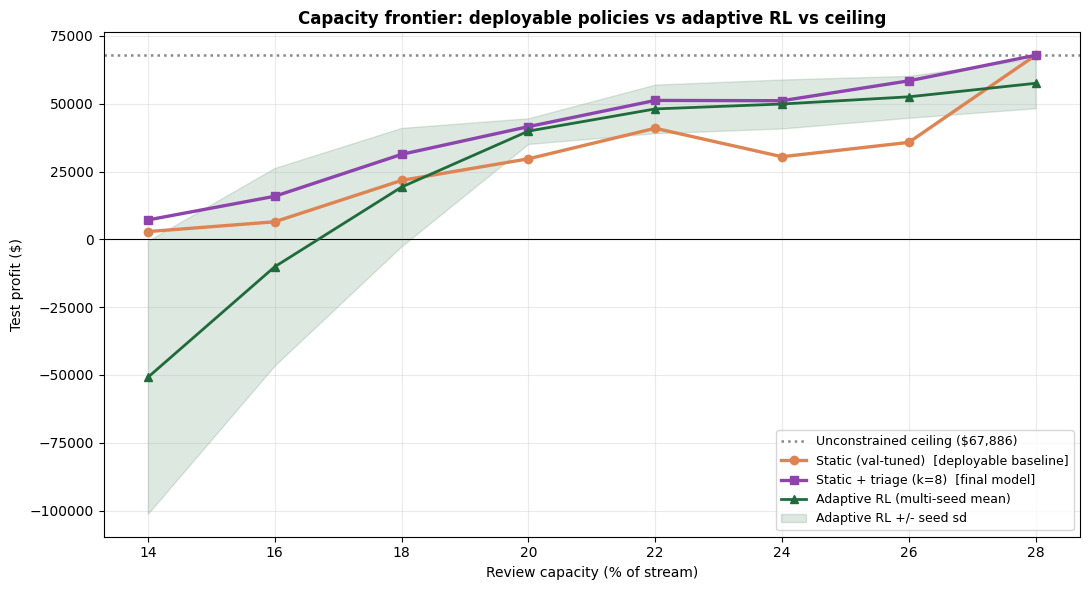

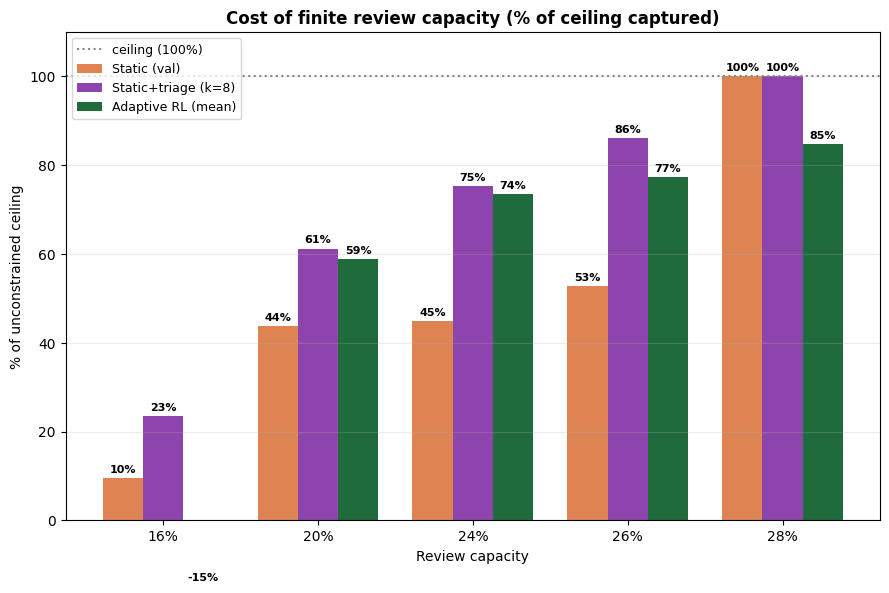


Note: naive (capping the unconstrained policy) is in the table only - it collapses to large losses at tight
budgets (e.g. -$163k @16%) and is omitted from the plots to keep the deployable policies legible.


In [63]:
# ════════════════════════════════════════════════════════════════════
# CAPACITY SECTION - CONSOLIDATED COMPARISON (Test): table + frontier + %-ceiling
# Final deployable model = budget-re-tuned static (+ optional triage at K_FINAL).
# Adaptive RL shown as an investigated comparison (mean +/- seed sd), not the deployed choice.
# Deps: amountcond_metrics(46), CapacityConstrainedEnv/capacity_rollout/best_static_under_budget(66),
#       _ab (ablation cell 87), SingleKnobAgent/CapacityShapedEnv/SK_*(78), multi-seed SKR ckpts.
import numpy as np, matplotlib.pyplot as plt
SUM_OOB='threshold'
SUM_SEEDS=[1,2,3,42,7]                               # SAME seed set as the rest of the notebook
SUM_REP=[0.16,0.20,0.24,0.26,0.28]                  # reach the point where budget stops binding (~ceiling at 26.9%)
SUM_FINE=[round(b,2) for b in np.arange(0.14,0.281,0.02)]   # frontier grid
K_GRID=[0,4,8,12,16,20,24,28,32]
cab_a4=np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')
_fr=(float(cab_a4[1]),float(cab_a4[2]),float(cab_a4[3]))
# CEIL=amountcond_metrics(cab_a4, test_probs, true_test_labels, test_amounts)['model_profit']

def _capE(P,L,A,bf): return CapacityConstrainedEnv(P,L,A,MIN_T_LOW,MAX_T_HIGH,budget_frac=bf,oob=SUM_OOB)
def _naive(bf):  return capacity_rollout(_capE(test_probs,true_test_labels,test_amounts,bf), cab_a4)[0]
def _static(bf):
    ba,_=best_static_under_budget(cab_a4, bf, split='val', oob=SUM_OOB)
    return capacity_rollout(_capE(test_probs,true_test_labels,test_amounts,bf), ba)[0], ba
def _triage(bf, k):
    ba,_=best_static_under_budget(cab_a4, bf, split='val', oob=SUM_OOB)
    return capacity_rollout(_ab(test_probs,true_test_labels,test_amounts,bf,'pressure',k), ba)[0]
def _adapt(bf):
    vals=[]
    for sd in SUM_SEEDS:
        ck=f'{PPO_DIR}/cap_singleknob_RANDOM_s{sd}_{SUM_OOB}.pt'
        if not os.path.exists(ck): continue
        ag=SingleKnobAgent(16, lr=SK_LR, gamma=0.99, entropy_coef=SK_ENTROPY, minibatch_size=128,
                           frozen=_fr, bl_lo=SK_BL_RANGE[0], bl_hi=SK_BL_RANGE[1]); ag.load(ck)
        e=CapacityShapedEnv(test_probs,true_test_labels,test_amounts,MIN_T_LOW,MAX_T_HIGH,budget_frac=bf,oob=SUM_OOB,shape_w=0.0)
        vals.append(capacity_rollout(e, lambda s2: ag.get_action(s2,deterministic=True)[0])[0])
    return np.array(vals)

# ---- summary table ----
def _oracle(bf):                                    # test-tuned static = best a FLAT policy can do (cheats on test)
    bo,_=best_static_under_budget(cab_a4, bf, split='test', oob=SUM_OOB)
    return capacity_rollout(_capE(test_probs,true_test_labels,test_amounts,bf), bo)[0]

print('='*116)
print(f"CAPACITY SUMMARY (Test, oob='{SUM_OOB}', seeds={SUM_SEEDS})   unconstrained ceiling=${CEIL:,.0f}")
print('  [oracle = test-tuned STATIC: undeployable upper bound of a flat policy; gap to static(val) = the drift cost]')
print('='*116)
print(' budget | naive(cap) | static(val) | static+triage(k=%-2d) | adaptive RL (mean +/- sd) | oracle(static)| s%%c|t%%c|a%%c|o%%c' % K_FINAL)
for bf in SUM_REP:
    pn=_naive(bf); ps,_=_static(bf); pt=_triage(bf,K_FINAL); av=_adapt(bf); po=_oracle(bf)
    am=av.mean() if len(av) else float('nan'); asd=av.std() if len(av) else float('nan')
    edge=' *' if bf>0.28-1e-9 else ''                # 0.28 = edge of adaptive training range
    print(f"  {100*bf:4.0f}% | ${pn:>9,.0f} | ${ps:>10,.0f} | ${pt:>17,.0f} | ${am:>8,.0f} +/- ${asd:>7,.0f}{edge} | ${po:>11,.0f} | "
          f"{100*ps/CEIL:>3.0f}|{100*pt/CEIL:>3.0f}|{100*am/CEIL:>3.0f}|{100*po/CEIL:>3.0f}")
print('='*116)
print("  * adaptive at 28% is at the edge of its 0.14-0.28 training-budget range (treat as noisier).")
print("  Note: oracle is a DIAGNOSTIC ceiling (tuned on test); it is NOT deployable. Among deployable policies,")
print("  static+triage is the choice; adaptive RL ties static on the mean but with large seed variance (see sd).")
# ---- compute fine-grid series for plots ----
st_line=[]; tri_line=[]; ad_mean=[]; ad_sd=[]; nv_line=[]
for bf in SUM_FINE:
    ps,_=_static(bf); st_line.append(ps); tri_line.append(_triage(bf,K_FINAL)); nv_line.append(_naive(bf))
    av=_adapt(bf); ad_mean.append(av.mean() if len(av) else np.nan); ad_sd.append(av.std() if len(av) else np.nan)
st_line=np.array(st_line); tri_line=np.array(tri_line); ad_mean=np.array(ad_mean); ad_sd=np.array(ad_sd)
bx=[100*b for b in SUM_FINE]

# ---- PLOT 1: profit-vs-capacity frontier (deployable policies + adaptive band + ceiling) ----
fig,ax=plt.subplots(figsize=(11,6))
ax.axhline(CEIL, color='#888888', ls=':', lw=1.8, label=f'Unconstrained ceiling (${CEIL:,.0f})')
ax.axhline(0, color='k', lw=0.8)
ax.plot(bx, st_line,  '-o', color='#DD8452', lw=2.4, label='Static (val-tuned)  [deployable baseline]')
ax.plot(bx, tri_line, '-s', color='#8E44AD', lw=2.4, label=f'Static + triage (k={K_FINAL})  [final model]')
ax.plot(bx, ad_mean,  '-^', color='#1F6B3B', lw=2.0, label='Adaptive RL (multi-seed mean)')
ax.fill_between(bx, ad_mean-ad_sd, ad_mean+ad_sd, color='#1F6B3B', alpha=0.15, label='Adaptive RL +/- seed sd')
ax.set_xlabel('Review capacity (% of stream)'); ax.set_ylabel('Test profit ($)')
ax.set_title('Capacity frontier: deployable policies vs adaptive RL vs ceiling', fontweight='bold')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

# ---- PLOT 2: % of ceiling at representative budgets (grouped bars) ----
fig2,ax=plt.subplots(figsize=(9,6))
w=0.26; idx=np.arange(len(SUM_REP))
st_c=[100*_static(bf)[0]/CEIL for bf in SUM_REP]
tr_c=[100*_triage(bf,K_FINAL)/CEIL for bf in SUM_REP]
ad_c=[100*(_adapt(bf).mean() if len(_adapt(bf)) else np.nan)/CEIL for bf in SUM_REP]
b1=ax.bar(idx-w, st_c, w, color='#DD8452', label='Static (val)')
b2=ax.bar(idx,   tr_c, w, color='#8E44AD', label=f'Static+triage (k={K_FINAL})')
b3=ax.bar(idx+w, ad_c, w, color='#1F6B3B', label='Adaptive RL (mean)')
ax.axhline(100, color='#888888', ls=':', lw=1.5, label='ceiling (100%)')
for bars in (b1,b2,b3):
    for b in bars:
        h=b.get_height()
        if not np.isnan(h): ax.text(b.get_x()+b.get_width()/2, h+1.2, f'{h:.0f}%', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(idx); ax.set_xticklabels([f'{int(100*b)}%' for b in SUM_REP])
ax.set_ylabel('% of unconstrained ceiling'); ax.set_xlabel('Review capacity')
ax.set_title('Cost of finite review capacity (% of ceiling captured)', fontweight='bold')
ax.legend(loc='upper left', fontsize=9); ax.grid(axis='y', alpha=0.25); ax.set_ylim(0,110)
plt.tight_layout(); plt.show()

print("\nNote: naive (capping the unconstrained policy) is in the table only - it collapses to large losses at tight")
print("budgets (e.g. -$163k @16%) and is omitted from the plots to keep the deployable policies legible.")

In [64]:
# ── DEPLOYABLE POLICY CONFIGURATOR (dashboard back-end) ──
# The staffing numbers are ADMIN-EDITABLE INPUTS, not baked into the model.
# Fixed model artifact = cab_a4 (RL-derived shape) + val re-tuning + K_FINAL.
# Runtime inputs (dashboard sliders): n_analysts, reviews_per_analyst_per_day, txns_per_day.
#   budget_frac = n_analysts * reviews_per_analyst_per_day / txns_per_day  ->  re-tune policy to it.
cab_a4 = np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')
DEPLOY_OOB = 'threshold'
_CEIL = CEIL

def configure_deployment(n_analysts=8,
                         reviews_per_analyst_per_day=100,   # EDITABLE: analyst throughput assumption
                         txns_per_day=None,                 # EDITABLE: None -> observed rate; use LIVE volume in prod
                         use_triage=True,
                         k=None,                            # None -> K_FINAL if defined else 16
                         eval_probs=None, eval_labels=None, eval_amounts=None):
    if txns_per_day is None: txns_per_day = TXNS_PER_DAY
    if k is None: k = (K_FINAL if 'K_FINAL' in globals() else 16)
    daily_capacity = n_analysts * reviews_per_analyst_per_day
    budget_frac    = daily_capacity / txns_per_day
    bf             = min(budget_frac, 1.0)
    # re-tune operating thresholds on VALIDATION at this budget (deployable; re-tune on recent data in prod)
    base,_ = best_static_under_budget(cab_a4, bf, split='val', oob=DEPLOY_OOB)
    # project on a reference window (demo: test; prod: recent labeled stream)
    P = test_probs       if eval_probs  is None else eval_probs
    L = true_test_labels if eval_labels is None else eval_labels
    A = test_amounts     if eval_amounts is None else eval_amounts
    env = _ab(P,L,A,bf,'pressure',k) if use_triage else CapacityConstrainedEnv(P,L,A,MIN_T_LOW,MAX_T_HIGH,budget_frac=bf,oob=DEPLOY_OOB)
    profit, review_rate, _ = capacity_rollout(env, base)
    reviews_used_per_day = txns_per_day * review_rate
    return dict(n_analysts=n_analysts, reviews_per_analyst_per_day=reviews_per_analyst_per_day,
                txns_per_day=txns_per_day, daily_capacity=daily_capacity, budget_frac=budget_frac,
                policy=dict(base_low=float(base[0]), slope_low=float(base[1]),
                            base_high=float(base[2]), slope_high=float(base[3]), triage_k=(k if use_triage else 0)),
                projected_profit=profit, review_rate=review_rate, reviews_used_per_day=reviews_used_per_day,
                capacity_used_pct=100*reviews_used_per_day/max(daily_capacity,1e-9),
                pct_of_ceiling=100*profit/_CEIL, budget_binding=(budget_frac < review_rate + 1e-6) or budget_frac < 0.27)

def print_config(c):
    p=c['policy']
    print(f"  inputs: {c['n_analysts']} analysts x {c['reviews_per_analyst_per_day']}/day = {c['daily_capacity']:,}/day  |  stream {c['txns_per_day']:,.0f}/day  ->  budget {100*c['budget_frac']:.1f}%")
    print(f"  policy: base_low={p['base_low']:.3f} base_high={p['base_high']:.3f} (slopes {p['slope_low']:.3f}/{p['slope_high']:.3f}) triage_k={p['triage_k']}")
    print(f"  projected: profit ${c['projected_profit']:,.0f} ({c['pct_of_ceiling']:.0f}% of ceiling) | review rate {100*c['review_rate']:.1f}% = {c['reviews_used_per_day']:,.0f}/day ({c['capacity_used_pct']:.0f}% of capacity used)")

print(f"DEPLOYABLE CONFIGURATOR  (defaults: {TXNS_PER_DAY:,.0f} txns/day, K_FINAL={(K_FINAL if 'K_FINAL' in globals() else 16)}, ceiling ${_CEIL:,.0f})")
print("Dashboard calls configure_deployment(n_analysts=<slider>, reviews_per_analyst_per_day=<slider>, txns_per_day=<live>).\n")
for na, rpe in [(4,100),(6,100),(8,100),(8,150),(12,100)]:
    print(f"[ {na} analysts @ {rpe}/day ]"); print_config(configure_deployment(n_analysts=na, reviews_per_analyst_per_day=rpe)); print()
print("Notes: throughput (reviews/analyst/day) and live txns/day are ASSUMPTIONS the admin sets; the policy is")
print("re-tuned to whatever budget they imply. For a responsive UI, precompute a budget_frac->policy lookup table")
print("(dense sweep, cached) and interpolate, instead of re-running best_static_under_budget on every slider move.")

DEPLOYABLE CONFIGURATOR  (defaults: 2,878 txns/day, K_FINAL=8, ceiling $67,886)
Dashboard calls configure_deployment(n_analysts=<slider>, reviews_per_analyst_per_day=<slider>, txns_per_day=<live>).

[ 4 analysts @ 100/day ]
  inputs: 4 analysts x 100/day = 400/day  |  stream 2,878/day  ->  budget 13.9%
  policy: base_low=0.609 base_high=0.788 (slopes -0.178/0.197) triage_k=8
  projected: profit $4,179 (6% of ceiling) | review rate 13.9% = 400/day (100% of capacity used)

[ 6 analysts @ 100/day ]
  inputs: 6 analysts x 100/day = 600/day  |  stream 2,878/day  ->  budget 20.8%
  policy: base_low=0.489 base_high=0.888 (slopes -0.178/0.197) triage_k=8
  projected: profit $46,524 (69% of ceiling) | review rate 20.8% = 600/day (100% of capacity used)

[ 8 analysts @ 100/day ]
  inputs: 8 analysts x 100/day = 800/day  |  stream 2,878/day  ->  budget 27.8%
  policy: base_low=0.409 base_high=0.988 (slopes -0.178/0.197) triage_k=8
  projected: profit $67,890 (100% of ceiling) | review rate 27.4% 

In [65]:
# ============================================================================
# Is the continuous (cab_a4) vs bucketed-grid profit gap real out-of-sample?
# Paired per-window comparison + moving-block bootstrap on the TEST stream.
# Both policies are val-fit and fixed; this is NOT forward-chaining CV.
# ============================================================================
import numpy as np
try:
    from scipy import stats as _st
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

# --- guards: make sure the two policies' decisions exist on test ---
assert 'cab_a4' in globals(),         "run the comparison cell first (defines cab_a4)"
assert 'test_decisions' in globals(), "run the bucketed-grid cell (cell 44) first (defines test_decisions)"
yT = np.asarray(true_test_labels, int)
AT = np.asarray(test_amounts, float)

# per-transaction profit (= -cost) for each policy, same cost fn for both
d_seq  = amountcond_metrics(cab_a4, test_probs, yT, AT)['decisions']
d_grid = np.asarray(test_decisions, int)
prof_seq  = -transaction_cost(d_seq,  yT, AT, COST_PARAMS)
prof_grid = -transaction_cost(d_grid, yT, AT, COST_PARAMS)
diff = prof_seq - prof_grid                       # per-transaction gap (additive)

full_gap = diff.sum()
print(f"Full-set test profit:  cab_a4 = ${prof_seq.sum():,.0f}   grid = ${prof_grid.sum():,.0f}")
print(f"Full-set gap (cab_a4 - grid) = ${full_gap:,.0f}")
print(f"Test transactions = {len(diff):,}   (test is time-ordered; windows are contiguous)\n")

# --- (1) paired per-window comparison across several window counts ---
print("Paired per-window comparison (window = contiguous time block):")
print(f"{'K':>3} | {'mean $/window':>14} | {'t-stat':>7} | {'pos/K':>6} | {'sign-test p':>11}")
for K in [4, 6, 8, 10]:
    edges = np.linspace(0, len(diff), K+1).astype(int)
    win = np.array([diff[edges[i]:edges[i+1]].sum() for i in range(K)])
    m, sd = win.mean(), win.std(ddof=1)
    t = m / (sd/np.sqrt(K)) if sd > 0 else np.nan
    npos = int((win > 0).sum())
    if _HAVE_SCIPY:
        sp = _st.binomtest(npos, K, 0.5).pvalue
    else:
        # two-sided exact binomial p without scipy
        from math import comb
        ks = [k for k in range(K+1) if abs(k-K/2) >= abs(npos-K/2)]
        sp = sum(comb(K,k) for k in ks) / 2**K
    print(f"{K:>3} | {m:>14,.0f} | {t:>7.2f} | {npos:>3}/{K:<2} | {sp:>11.3f}")

# --- (2) moving-block bootstrap CI on the total gap (respects autocorrelation) ---
rng = np.random.default_rng(0)
N = len(diff)
L = max(1, N // 40)                 # block length (~40 blocks); preserves local structure
nblk = int(np.ceil(N / L))
csum = np.concatenate([[0.0], np.cumsum(diff)])
max_start = N - L
B = 4000
boot = np.empty(B)
for b in range(B):
    starts = rng.integers(0, max_start + 1, size=nblk)
    boot[b] = (csum[starts + L] - csum[starts]).sum() * (N / (nblk * L))  # scale to N txns
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"\nMoving-block bootstrap (block L={L:,}, {nblk} blocks, B={B}):")
print(f"  total-gap 95% CI = [${lo:,.0f}, ${hi:,.0f}]   point = ${full_gap:,.0f}")
print(f"  P(gap <= 0) ~ {np.mean(boot <= 0):.3f}")

Full-set test profit:  cab_a4 = $67,530   grid = $60,257
Full-set gap (cab_a4 - grid) = $7,272
Test transactions = 88,581   (test is time-ordered; windows are contiguous)

Paired per-window comparison (window = contiguous time block):
  K |  mean $/window |  t-stat |  pos/K | sign-test p
  4 |          1,818 |    4.51 |   4/4  |       0.125
  6 |          1,212 |    2.44 |   4/6  |       0.688
  8 |            909 |    2.22 |   6/8  |       0.289
 10 |            727 |    2.15 |   8/10 |       0.109

Moving-block bootstrap (block L=2,214, 41 blocks, B=4000):
  total-gap 95% CI = [$1,589, $15,541]   point = $7,272
  P(gap <= 0) ~ 0.003


In [66]:
# ============================================================================
# Optimizer ablation (FAST, self-contained). Interrupt the slow run first.
# Non-RL fit of the 4-param policy on VAL, eval on TEST, vs cab_a4 (PPO).
# ============================================================================
import numpy as np
from scipy.optimize import differential_evolution

# precompute val amount-terms once (constant across candidates)
_pV = np.asarray(val_probs, float); _AV = np.asarray(val_amounts, float); _yV = np.asarray(true_val_labels, int)
_zV = (np.log1p(_AV) - Z_LOGA_MEAN) / Z_LOGA_STD
_floorV = COST_PARAMS['rc'] / (COST_PARAMS['flm'] * _AV + 1e-6)

def _val_profit_fast(a4):
    bl, sl, bh, sh = a4
    T_low  = np.clip(bl + sl*_zV, MIN_T_LOW, MAX_T_HIGH - 0.02)
    T_high = np.clip(bh + sh*_zV, T_low + 0.01, MAX_T_HIGH)
    eff    = np.minimum(np.maximum(T_low, _floorV), T_high - 0.01)
    d      = np.where(_pV < eff, 0, np.where(_pV < T_high, 2, 1))
    return -transaction_cost(d, _yV, _AV, COST_PARAMS).sum()

# correctness guard: fast profit must equal amountcond_metrics' model_profit
for _ in range(5):
    _a = [np.random.uniform(MIN_T_LOW, MAX_T_HIGH), np.random.uniform(-0.2, 0.2),
          np.random.uniform(MIN_T_LOW, MAX_T_HIGH), np.random.uniform(-0.2, 0.2)]
    _ref = amountcond_metrics(np.asarray(_a, float), val_probs, true_val_labels, val_amounts)['model_profit']
    assert abs(_val_profit_fast(_a) - _ref) < 1e-6, "fast profit fn diverges from amountcond_metrics"
print("fast profit fn matches amountcond_metrics [OK]")

bounds = [(MIN_T_LOW, MAX_T_HIGH), (-0.20, 0.20),
          (MIN_T_LOW, MAX_T_HIGH), (-0.20, 0.20)]

# (1) non-RL global optimizer  (FAST objective)
res = differential_evolution(lambda a: -_val_profit_fast(a), bounds, seed=0,
                             popsize=15, maxiter=80, tol=1e-6, polish=False)
de_a4 = res.x

# (2) random-search cross-check  (FAST objective)
rng = np.random.default_rng(0); R = 4000
cand = np.column_stack([rng.uniform(MIN_T_LOW, MAX_T_HIGH, R), rng.uniform(-0.20, 0.20, R),
                        rng.uniform(MIN_T_LOW, MAX_T_HIGH, R), rng.uniform(-0.20, 0.20, R)])
rs_vals = np.array([_val_profit_fast(a) for a in cand]); rs_a4 = cand[rs_vals.argmax()]
nonrl_a4 = de_a4 if _val_profit_fast(de_a4) >= rs_vals.max() else rs_a4

cab_a4 = np.load(f'{PPO_DIR}/seq_amountcont_seed42_params.npy')

# final report uses full metrics (only ~4 calls -> the slow part doesn't matter here)
def _report(name, a4):
    v = amountcond_metrics(np.asarray(a4,float), val_probs,  true_val_labels,  val_amounts)
    t = amountcond_metrics(np.asarray(a4,float), test_probs, true_test_labels, test_amounts)
    print(f"  {name:18s} a4=[{a4[0]:.3f},{a4[1]:+.3f},{a4[2]:.3f},{a4[3]:+.3f}]  "
          f"val=${v['model_profit']:,.0f}  test=${t['model_profit']:,.0f}")
    return v['model_profit'], t['model_profit']

print("Both fit on VAL, evaluated on TEST:")
nr_val, nr_test = _report("non-RL optimizer", nonrl_a4)
rl_val, rl_test = _report("PPO (cab_a4)",     cab_a4)
print(f"\n  TEST gap (PPO - non-RL) = ${rl_test - nr_test:,.0f}")
print(f"  VAL  gap (PPO - non-RL) = ${rl_val - nr_val:,.0f}")

fast profit fn matches amountcond_metrics [OK]
Both fit on VAL, evaluated on TEST:
  non-RL optimizer   a4=[0.461,-0.127,0.979,+0.196]  val=$81,149  test=$63,746
  PPO (cab_a4)       a4=[0.409,-0.178,0.938,+0.197]  val=$80,103  test=$67,530

  TEST gap (PPO - non-RL) = $3,784
  VAL  gap (PPO - non-RL) = $-1,045


In [67]:
# ============================================================================
# Robustness of "PPO generalizes better than direct val-optimization".
# Same multi-seed standard that killed the SKR single-seed win.
# ============================================================================
import numpy as np
from scipy.optimize import differential_evolution
SEEDS = [1, 2, 3, 42, 7]

print("PPO (cab_a4) across seeds:")
ppo = []
for sd in SEEDS:
    a = np.load(f'{PPO_DIR}/seq_amountcont_seed{sd}_params.npy')
    v = amountcond_metrics(a, val_probs,  true_val_labels,  val_amounts)['model_profit']
    t = amountcond_metrics(a, test_probs, true_test_labels, test_amounts)['model_profit']
    ppo.append((v, t)); print(f"  seed {sd:>2}: val=${v:,.0f}  test=${t:,.0f}")
ppo = np.array(ppo)
print(f"  -> PPO test: mean=${ppo[:,1].mean():,.0f}  range=[${ppo[:,1].min():,.0f}, ${ppo[:,1].max():,.0f}]")

print("\nNon-RL optimizer across seeds (each maximizes val):")
nonrl = []
for s in range(8):
    res = differential_evolution(lambda a: -_val_profit_fast(a), bounds, seed=s,
                                 popsize=15, maxiter=80, tol=1e-6, polish=False)
    a = res.x; v = _val_profit_fast(a)
    t = amountcond_metrics(a, test_probs, true_test_labels, test_amounts)['model_profit']
    nonrl.append((v, t)); print(f"  run {s}: val=${v:,.0f}  test=${t:,.0f}")
nonrl = np.array(nonrl)
print(f"  -> non-RL test: mean=${nonrl[:,1].mean():,.0f}  range=[${nonrl[:,1].min():,.0f}, ${nonrl[:,1].max():,.0f}]")

print(f"\n  TEST gap (PPO mean - non-RL mean) = ${ppo[:,1].mean()-nonrl[:,1].mean():,.0f}")
clean = ppo[:,1].min() > nonrl[:,1].max()
print(f"  PPO worst test (${ppo[:,1].min():,.0f}) vs non-RL best test (${nonrl[:,1].max():,.0f}): "
      f"{'PPO still ahead -> CLEAN separation' if clean else 'OVERLAP -> gap is on-average only'}")
print(f"  non-RL overfits val? val mean ${nonrl[:,0].mean():,.0f} vs PPO ${ppo[:,0].mean():,.0f}")

PPO (cab_a4) across seeds:
  seed  1: val=$79,638  test=$67,125
  seed  2: val=$79,876  test=$68,249
  seed  3: val=$79,703  test=$68,167
  seed 42: val=$80,103  test=$67,530
  seed  7: val=$79,856  test=$68,120
  -> PPO test: mean=$67,838  range=[$67,125, $68,249]

Non-RL optimizer across seeds (each maximizes val):
  run 0: val=$81,149  test=$63,746
  run 1: val=$81,149  test=$63,750
  run 2: val=$81,221  test=$65,141
  run 3: val=$81,225  test=$65,282
  run 4: val=$81,225  test=$65,282
  run 5: val=$81,225  test=$65,274
  run 6: val=$81,219  test=$65,127
  run 7: val=$81,225  test=$65,286
  -> non-RL test: mean=$64,861  range=[$63,746, $65,286]

  TEST gap (PPO mean - non-RL mean) = $2,977
  PPO worst test ($67,125) vs non-RL best test ($65,286): PPO still ahead -> CLEAN separation
  non-RL overfits val? val mean $81,204 vs PPO $79,835


In [68]:
# Does matching PPO's (lower) val level recover the generalization, sans RL?
import numpy as np
from scipy.optimize import differential_evolution

PPO_VAL = ppo[:,0].mean()   # ~79,835  (target val level)
print(f"target val level (PPO mean) = ${PPO_VAL:,.0f}\n")

es = []
for s in range(6):
    hit = {}
    def _cb(xk, convergence=None, _h=hit):
        if 'a' not in _h and _val_profit_fast(xk) >= PPO_VAL:
            _h['a'] = xk.copy(); return True      # stop as soon as we reach PPO's val
        return False
    differential_evolution(lambda a: -_val_profit_fast(a), bounds, seed=s,
                           popsize=15, maxiter=200, tol=1e-9, polish=False, callback=_cb)
    a = hit.get('a')
    if a is None:   # never dropped to that level on the way up; sample to the band instead
        continue
    v = _val_profit_fast(a)
    t = amountcond_metrics(a, test_probs, true_test_labels, test_amounts)['model_profit']
    es.append((v, t)); print(f"  run {s}: val=${v:,.0f}  test=${t:,.0f}")

if es:
    es = np.array(es)
    print(f"\n  val-matched non-RL test: mean=${es[:,1].mean():,.0f}  range=[${es[:,1].min():,.0f}, ${es[:,1].max():,.0f}]")
    print(f"  PPO test mean=${ppo[:,1].mean():,.0f}")
    print(f"  -> {'RL-specific: PPO still ahead at matched val' if ppo[:,1].mean() > es[:,1].max() else 'NOT RL-specific: matching val level recovers generalization (credit = do not over-trust val)'}")
else:
    print("  callback never triggered; tell me and I will switch to a val-band random search")

target val level (PPO mean) = $79,835

  run 0: val=$79,917  test=$67,963
  run 1: val=$80,217  test=$66,173
  run 2: val=$79,992  test=$68,591
  run 3: val=$80,019  test=$67,515
  run 4: val=$80,284  test=$63,421
  run 5: val=$80,048  test=$67,635

  val-matched non-RL test: mean=$66,883  range=[$63,421, $68,591]
  PPO test mean=$67,838
  -> NOT RL-specific: matching val level recovers generalization (credit = do not over-trust val)


In [69]:
# Does "PPO is more test-stable at matched val" survive more non-RL seeds?
import numpy as np
from scipy.optimize import differential_evolution
from scipy import stats as st

SEEDS = [1,2,3,42,7]
def _load(sd): return np.load(f'{PPO_DIR}/seq_amountcont_seed{sd}_params.npy')
ppo_test = np.array([amountcond_metrics(_load(sd), test_probs, true_test_labels, test_amounts)['model_profit'] for sd in SEEDS])
PPO_VAL  = np.mean([amountcond_metrics(_load(sd), val_probs,  true_val_labels,  val_amounts)['model_profit'] for sd in SEEDS])

def val_matched(seed, target):
    hit = {}
    def _cb(xk, convergence=None):
        if 'a' not in hit and _val_profit_fast(xk) >= target:
            hit['a'] = xk.copy(); return True
        return False
    differential_evolution(lambda a: -_val_profit_fast(a), bounds, seed=seed,
                           popsize=15, maxiter=300, tol=1e-9, polish=False, callback=_cb)
    return hit.get('a')

nonrl_test = []
for s in range(30):
    a = val_matched(s, PPO_VAL)
    if a is not None:
        nonrl_test.append(amountcond_metrics(a, test_probs, true_test_labels, test_amounts)['model_profit'])
nonrl_test = np.array(nonrl_test)

print(f"PPO    (n={len(ppo_test)}):  mean=${ppo_test.mean():,.0f}  sd=${ppo_test.std(ddof=1):,.0f}  range=[${ppo_test.min():,.0f},${ppo_test.max():,.0f}]")
print(f"non-RL (n={len(nonrl_test)}): mean=${nonrl_test.mean():,.0f}  sd=${nonrl_test.std(ddof=1):,.0f}  range=[${nonrl_test.min():,.0f},${nonrl_test.max():,.0f}]")
tt = st.ttest_ind(ppo_test, nonrl_test, equal_var=False)
lv = st.levene(ppo_test, nonrl_test, center='median')
print(f"\nmean gap = ${ppo_test.mean()-nonrl_test.mean():,.0f}   Welch t={tt.statistic:.2f} p={tt.pvalue:.3f}")
print(f"variance: Levene W={lv.statistic:.2f} p={lv.pvalue:.3f}   ratio(non-RL/PPO)={nonrl_test.var(ddof=1)/ppo_test.var(ddof=1):.1f}x")

PPO    (n=5):  mean=$67,838  sd=$490  range=[$67,125,$68,249]
non-RL (n=30): mean=$66,417  sd=$1,547  range=[$63,104,$68,591]

mean gap = $1,421   Welch t=3.97 p=0.001
variance: Levene W=7.29 p=0.011   ratio(non-RL/PPO)=10.0x


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# DASHBOARD EXPORT — CAPACITY-BOUND SYSTEM (the final deployable model)
# Paste as the LAST cell, AFTER the capacity section (best_static_under_budget,
# the triage env, and K_FINAL must already be defined).
#
# Deploys: budget-re-tuned static policy + budget-pressure triage (k=K_FINAL),
# enforced by a binding review budget. The dashboard's reviewer/capacity numbers
# are derived from the SAME budget the model runs at. The bundle also snapshots the
# validation set + the FROZEN PPO policy, so the dashboard's reviewer slider can
# re-tune live (PPO stays frozen — only the static base + triage-k are re-derived).
# ════════════════════════════════════════════════════════════════════════════
import sys, os, importlib
PROJECT_ROOT = "/fraud_dashboard_project" # change to your local path

for _m in [k for k in list(sys.modules) if k == "fraudcore" or k.startswith("fraudcore.")]:
    del sys.modules[_m]
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
importlib.invalidate_caches()
sys.path_importer_cache.pop(PROJECT_ROOT, None)

from fraudcore.dashboard_export import write_dashboard_outputs, save_bundle
import inspect, fraudcore.dashboard_export as _de
assert "headline_policy_a4" in inspect.signature(_de.build_dashboard_payload).parameters, "still old fraudcore"

print("fraudcore loaded from:", _de.__file__)
# frozen headline PPO policy (works whether or not you applied the rename)
_policy_hl = cab_a4 if "cab_a4" in globals() else seq_a4

# ── staffing <-> budget (model and dashboard share these numbers) ────────────
REVIEWS_PER_DAY = 100                                    # REVIEWS_PER_EMPLOYEE_PER_DAY
_dt = raw_test_df["TransactionDT"].to_numpy()
TXNS_PER_DAY = len(raw_test_df) / ((_dt.max() - _dt.min()) / 86400)
N_REVIEWERS = 8                                          # initial staffing; the dashboard slider overrides this live
DEPLOY_BUDGET_FRAC = (N_REVIEWERS * REVIEWS_PER_DAY) / TXNS_PER_DAY

# ── the deployed capacity-bound policy (re-tuned from the FROZEN PPO policy) ──
OOB = "threshold"
_best_a, _ = best_static_under_budget(_policy_hl, DEPLOY_BUDGET_FRAC, split="val", oob=OOB)
_k = float(K_FINAL) if "K_FINAL" in globals() else 0.0

# kwargs for the file writer (build_dashboard_payload has a fixed signature, so val_*
# arrays are passed to save_bundle ONLY, not here)
_common = dict(
    scores=test_probs, labels=true_test_labels, amounts=test_amounts, meta_df=raw_test_df,
    policy_a4=_best_a,                                    # deployed (budget-re-tuned) base
    headline_policy_a4=_policy_hl,                        # frozen PPO -> "RL (amount-conditioned)" comparison row
    z_mean=Z_LOGA_MEAN, z_std=Z_LOGA_STD, min_t_low=MIN_T_LOW, max_t_high=MAX_T_HIGH,
    mode="capacity",
    budget_frac=DEPLOY_BUDGET_FRAC, triage_k=_k, gate="pressure", oob=OOB,
    txns_per_day=TXNS_PER_DAY,
    reviewers=N_REVIEWERS, reviews_per_reviewer_per_day=REVIEWS_PER_DAY,
    grid_thresholds=(gs_T_low, gs_T_high),
    single_thresholds=None,  # fixed-threshold PPO removed from final notebook
    bucketed_decisions=test_decisions if "test_decisions" in globals() else None,
    auc_val=val_auc_final if "val_auc_final" in globals() else None,
    auc_test=test_auc_final if "test_auc_final" in globals() else None,
)

# snapshot for live re-tuning (val set + frozen policy) and for regenerate_dashboard.py
save_bundle(os.path.join(PROJECT_ROOT, "dashboard_outputs", "deployment_bundle.npz"),
            val_scores=val_probs, val_labels=true_val_labels, val_amounts=val_amounts,
            **_common)
res = write_dashboard_outputs(os.path.join(PROJECT_ROOT, "dashboard_outputs"), **_common)

m = res["metrics"]
print(f"Deployed capacity-bound system  (budget {100*DEPLOY_BUDGET_FRAC:.1f}% ≈ {N_REVIEWERS} analysts × {REVIEWS_PER_DAY}/day,  triage k={_k:g})")
print(f"  review_rate = {100*m['review_rate']:.1f}%   profit_gain = {100*m['profit_gain']:.1f}%   total_profit = ${m['total_profit']:,.0f}")
print(f"  overload (force-accepted fraud + force-rejected legit) = ${m['overload_cost_total']:,.0f}")
print(f"  reviewers in rl_policy.json = {res['policy']['reviewers']}  (daily capacity {res['policy']['reviewers']*REVIEWS_PER_DAY:,} vs ~{TXNS_PER_DAY:,.0f} txns/day)")
print("  bundle includes val set + frozen PPO policy -> the dashboard reviewer slider can re-tune live.")

fraudcore loaded from: /Users/mohammadossama/CCAS 5.1 Graduation Project/fraud_dashboard_project/fraudcore/dashboard_export.py
Deployed capacity-bound system  (budget 27.8% ≈ 8 analysts × 100/day,  triage k=8)
  review_rate = 27.4%   profit_gain = 88.2%   total_profit = $67,897
  overload (force-accepted fraud + force-rejected legit) = $0
  reviewers in rl_policy.json = 8  (daily capacity 800 vs ~2,878 txns/day)
  bundle includes val set + frozen PPO policy -> the dashboard reviewer slider can re-tune live.


Presentation Plots

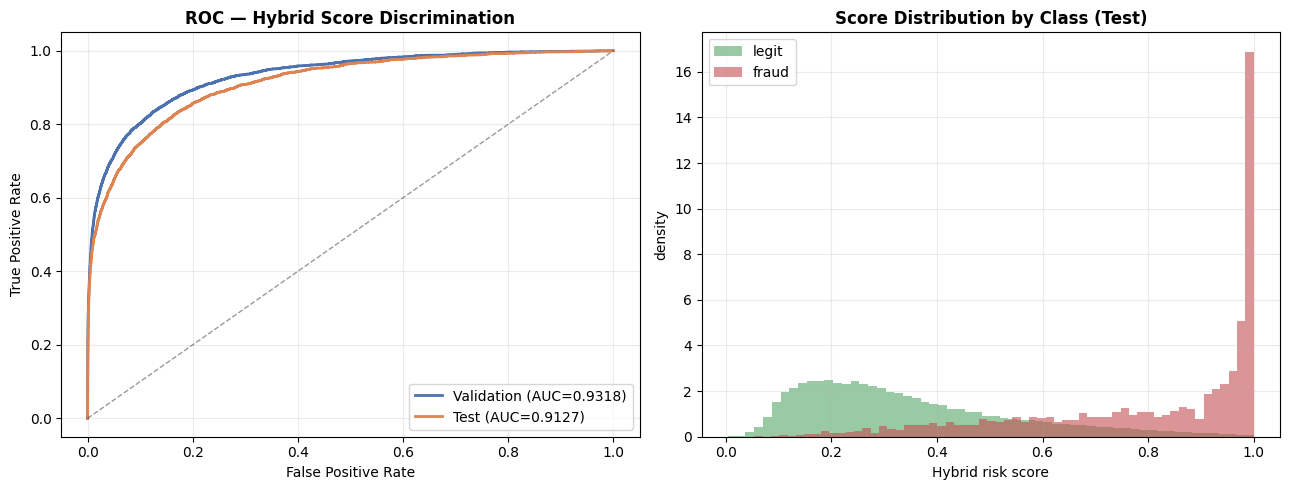

Val  AUC: 0.9318
Test AUC: 0.9127


In [71]:
# ── RESULTS: Hybrid Classifier — discrimination ──
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for probs, labels, name, color in [
    (val_probs,  true_val_labels,  'Validation', '#4C72B0'),
    (test_probs, true_test_labels, 'Test',       '#DD8452'),
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC — Hybrid Score Discrimination', fontweight='bold')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.25)

p = np.asarray(test_probs); y = np.asarray(true_test_labels)
axes[1].hist(p[y==0], bins=60, alpha=0.6, density=True, label='legit', color='#55A868')
axes[1].hist(p[y==1], bins=60, alpha=0.6, density=True, label='fraud', color='#C44E52')
axes[1].set_xlabel('Hybrid risk score'); axes[1].set_ylabel('density')
axes[1].set_title('Score Distribution by Class (Test)', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f'{PPO_DIR}/classifier_discrimination.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Val  AUC: {roc_auc_score(true_val_labels, val_probs):.4f}")
print(f"Test AUC: {roc_auc_score(true_test_labels, test_probs):.4f}")

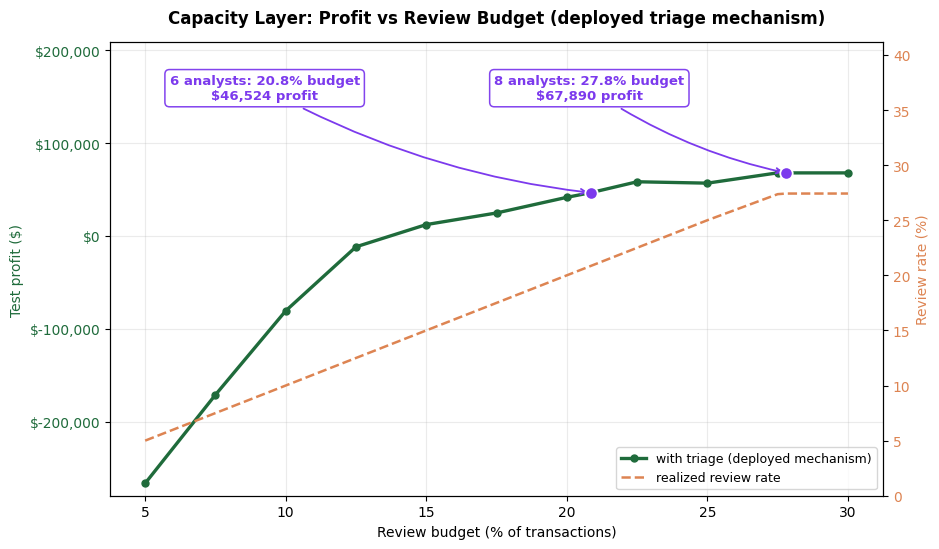

6 analysts -> 20.85% budget | $46,524 | review=20.85%
8 analysts -> 27.80% budget | $67,890 | review=27.42%


In [76]:
# ── Capacity Layer: profit vs budget, with corrected label placement ──
import numpy as np
import matplotlib.pyplot as plt

TXNS_PER_DAY = 2878.03
REVIEWS_PER_DAY = 100
deployed = {6: None, 8: None}

sweep_grid = np.linspace(0.05, 0.30, 11)
exact_points = [n * REVIEWS_PER_DAY / TXNS_PER_DAY for n in (6, 8)]
budget_grid = np.unique(np.concatenate([sweep_grid, exact_points]))

triage_profit, triage_review = [], []

for bf in budget_grid:
    # 1) tune base thresholds on VALIDATION for this budget (deployed step)
    a_star, _ = best_static_under_budget(cab_a4, bf, split='val', oob='reject')
    # 2) roll out on TEST with pressure triage at k (via the ablation env)
    env = _ab(test_probs, true_test_labels, test_amounts, bf, 'pressure', 8.0)
    prof, rev, _ = capacity_rollout(env, a_star)
    triage_profit.append(prof); triage_review.append(100 * rev)
    for n in (6, 8):
        if np.isclose(bf, n * REVIEWS_PER_DAY / TXNS_PER_DAY, atol=1e-6):
            deployed[n] = (100 * bf, prof, 100 * rev)
triage_profit = np.array(triage_profit); triage_review = np.array(triage_review)

fig, ax1 = plt.subplots(figsize=(9.5, 5.6))
ax1.plot(100*budget_grid, triage_profit, color='#1F6B3B', lw=2.4, marker='o', ms=5,
         label='with triage (deployed mechanism)', zorder=3)
ax1.set_xlabel('Review budget (% of transactions)')
ax1.set_ylabel('Test profit ($)', color='#1F6B3B')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.tick_params(axis='y', labelcolor='#1F6B3B'); ax1.grid(alpha=0.25)

# --- widen y-range so there's real empty headroom above the curve for labels ---
ymin, ymax = triage_profit.min(), triage_profit.max()
yrange = ymax - ymin
ax1.set_ylim(ymin - 0.04*yrange, ymax + 0.42*yrange)   # ~40% clear space on top

ax2 = ax1.twinx()
ax2.plot(100*budget_grid, triage_review, color='#DD8452', lw=1.8, ls='--',
         label='realized review rate', zorder=2)
ax2.set_ylabel('Review rate (%)', color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')
ax2.set_ylim(0, max(triage_review) * 1.5)   # keep review-rate scale from compressing too

# --- fixed, verified-empty anchor positions (axes fraction), short clean arrows ---
box = dict(boxstyle='round,pad=0.35', fc='white', ec='#7c3aed', lw=1.1, alpha=0.95)
label_anchors = {6: (0.20, 0.93), 8: (0.62, 0.93)}

for n, (bx, bp, brv) in deployed.items():
    if bx is None:
        continue
    ax1.scatter([bx], [bp], color='#7c3aed', s=80, zorder=5, edgecolor='white', linewidth=1.3)
    ax1.annotate(f"{n} analysts: {bx:.1f}% budget\n${bp:,.0f} profit",
                 xy=(bx, bp), xycoords='data',
                 xytext=label_anchors[n], textcoords='axes fraction',
                 fontsize=9.5, fontweight='bold', color='#7c3aed',
                 ha='center', va='top', bbox=box,
                 arrowprops=dict(arrowstyle='->', color='#7c3aed', lw=1.3,
                                  connectionstyle='arc3,rad=0.1'))

h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='lower right', fontsize=9)
ax1.set_title('Capacity Layer: Profit vs Review Budget (deployed triage mechanism)',
              fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(f'{PPO_DIR}/capacity_layer_results.png', dpi=200, bbox_inches='tight')
plt.show()

for n, v in deployed.items():
    if v: print(f"{n} analysts -> {v[0]:.2f}% budget | ${v[1]:,.0f} | review={v[2]:.2f}%")

  HYBRID CLASSIFIER RESULTS

  Metric                           Validation       Test
  ----------------------------------------------------
  AUC-ROC                              0.9318     0.9127
  Avg Precision (PR-AUC)               0.6002     0.5292

  At deployed PPO thresholds (test set):
  ----------------------------------------------------
  Precision (post-review)              0.6360
  Recall    (post-review)              0.8767
  F1        (post-review)              0.7372
  Precision (auto-only)                0.4738
  Recall    (auto-only)                0.7857
  F1        (auto-only)                0.5911

  Confusion matrix (post-review, test set):
  ----------------------------------------------------
  TP = 2,703   FP = 1,547
  FN = 380   TN = 83,951
  False positive rate = 1.81%
  Fraud catch rate    = 87.67%  (recall)
  Transactions reviewed: 23,813 (26.9%)


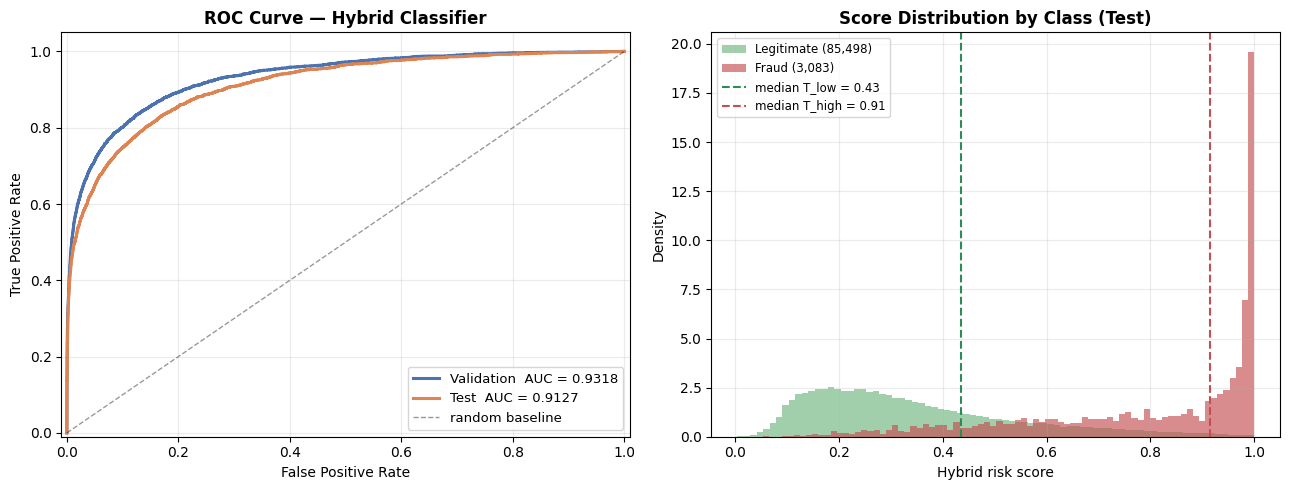

In [77]:
# ── RESULTS: Hybrid Classifier — discrimination metrics ──
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, roc_auc_score, precision_score,
                              recall_score, f1_score, accuracy_score,
                              confusion_matrix, average_precision_score)

# ── 1. Threshold-independent metrics (don't depend on where you cut the score) ──
val_auc  = roc_auc_score(true_val_labels,  val_probs)
test_auc = roc_auc_score(true_test_labels, test_probs)
val_ap   = average_precision_score(true_val_labels,  val_probs)
test_ap  = average_precision_score(true_test_labels, test_probs)

# ── 2. Threshold-dependent metrics at the DEPLOYED operating point ──
# Use the RL-learned thresholds, not 0.5 — these are the real operating conditions.
# Reviews are credited as oracle-correct (post-review F1 view, operational upper bound).
base_low, slope_low, base_high, slope_high = cab_a4
A   = np.asarray(test_amounts, float)
z   = (np.log1p(A) - Z_LOGA_MEAN) / Z_LOGA_STD
p   = np.asarray(test_probs, float)
y   = np.asarray(true_test_labels, int)
T_low  = np.clip(base_low  + slope_low  * z, MIN_T_LOW, MAX_T_HIGH - 0.02)
T_high = np.clip(base_high + slope_high * z, T_low + 0.01, MAX_T_HIGH)
eff = np.minimum(np.maximum(T_low, COST_PARAMS['rc'] / (COST_PARAMS['flm']*A + 1e-6)), T_high-0.01)
d = np.where(p < eff, 0, np.where(p < T_high, 2, 1))   # 0=accept,1=reject,2=review

# post-review view: reviews resolved correctly
y_post = np.where(d == 0, 0, np.where(d == 1, 1, y))
# auto-only view: reviews = abstain
auto   = d != 2
y_auto = (d[auto] == 1).astype(int)

cm = confusion_matrix(y, y_post)
tn, fp, fn, tp = cm.ravel()

print("=" * 58)
print("  HYBRID CLASSIFIER RESULTS")
print("=" * 58)
print(f"\n  {'Metric':<32} {'Validation':>10} {'Test':>10}")
print(f"  {'-'*52}")
print(f"  {'AUC-ROC':<32} {val_auc:>10.4f} {test_auc:>10.4f}")
print(f"  {'Avg Precision (PR-AUC)':<32} {val_ap:>10.4f} {test_ap:>10.4f}")

print(f"\n  At deployed PPO thresholds (test set):")
print(f"  {'-'*52}")
print(f"  {'Precision (post-review)':<32} {precision_score(y, y_post, zero_division=0):>10.4f}")
print(f"  {'Recall    (post-review)':<32} {recall_score(y, y_post, zero_division=0):>10.4f}")
print(f"  {'F1        (post-review)':<32} {f1_score(y, y_post, zero_division=0):>10.4f}")
print(f"  {'Precision (auto-only)':<32} {precision_score(y[auto], y_auto, zero_division=0):>10.4f}")
print(f"  {'Recall    (auto-only)':<32} {recall_score(y[auto], y_auto, zero_division=0):>10.4f}")
print(f"  {'F1        (auto-only)':<32} {f1_score(y[auto], y_auto, zero_division=0):>10.4f}")

print(f"\n  Confusion matrix (post-review, test set):")
print(f"  {'-'*52}")
print(f"  TP = {tp:,}   FP = {fp:,}")
print(f"  FN = {fn:,}   TN = {tn:,}")
print(f"  False positive rate = {100*fp/(fp+tn):.2f}%")
print(f"  Fraud catch rate    = {100*tp/(tp+fn):.2f}%  (recall)")
print(f"  Transactions reviewed: {(d==2).sum():,} ({100*(d==2).mean():.1f}%)")
print("=" * 58)

# ── 3. Plots: ROC curve + score distribution ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: ROC curve for val + test
for probs, labels, name, color in [
    (val_probs,  true_val_labels,  'Validation', '#4C72B0'),
    (test_probs, true_test_labels, 'Test',       '#DD8452'),
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2.2, label=f'{name}  AUC = {auc:.4f}')

axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Hybrid Classifier', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9.5)
axes[0].grid(alpha=0.25)
axes[0].set_xlim(-0.01, 1.01); axes[0].set_ylim(-0.01, 1.05)

# Right: score distribution by class (test set only)
axes[1].hist(p[y==0], bins=80, alpha=0.55, density=True,
             label=f'Legitimate ({(y==0).sum():,})', color='#55A868')
axes[1].hist(p[y==1], bins=80, alpha=0.65, density=True,
             label=f'Fraud ({(y==1).sum():,})',     color='#C44E52')
axes[1].set_xlabel('Hybrid risk score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution by Class (Test)', fontweight='bold')
axes[1].legend(loc='upper center', fontsize=9.5)
axes[1].grid(alpha=0.25)
# mark the median deployed T_low and T_high for context
median_tlow  = float(np.median(T_low));  median_thigh = float(np.median(T_high))
axes[1].axvline(median_tlow,  color='#2E8B57', lw=1.5, ls='--',
                label=f'median T_low = {median_tlow:.2f}')
axes[1].axvline(median_thigh, color='#C44E52', lw=1.5, ls='--',
                label=f'median T_high = {median_thigh:.2f}')
axes[1].legend(loc='upper left', fontsize=8.5)

plt.tight_layout()
plt.savefig(f'{PPO_DIR}/classifier_discrimination.png', dpi=200, bbox_inches='tight')
plt.show()

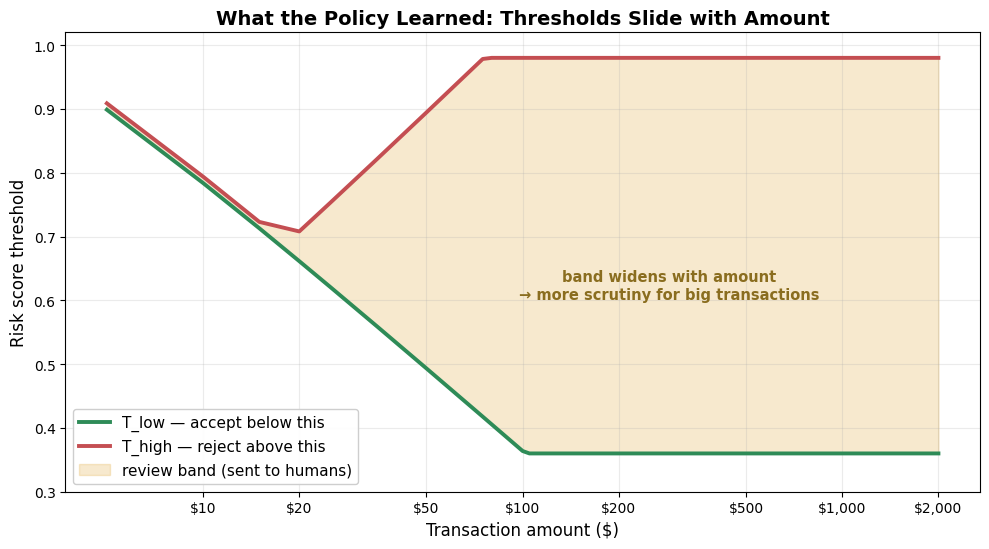

In [78]:
# ── SLIDE 4: RL Layer — What It Learned (thresholds vs amount) ──
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

# swap to the deployed (budget re-tuned) policy instead of the frozen one
base_low, slope_low, base_high, slope_high = _best_a   # was: cab_a4
A_grid = np.linspace(5, 2000, 400)
z_grid = (np.log1p(A_grid) - Z_LOGA_MEAN) / Z_LOGA_STD
T_low  = np.clip(base_low  + slope_low  * z_grid, MIN_T_LOW, MAX_T_HIGH - 0.02)
T_high = np.clip(base_high + slope_high * z_grid, T_low + 0.01, MAX_T_HIGH)

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.plot(A_grid, T_low,  color='#2E8B57', lw=2.8, label='T_low — accept below this')
ax.plot(A_grid, T_high, color='#C44E52', lw=2.8, label='T_high — reject above this')
ax.fill_between(A_grid, T_low, T_high, color='#E1A93C', alpha=0.25, label='review band (sent to humans)')

ax.set_xlabel('Transaction amount ($)', fontsize=12)
ax.set_ylabel('Risk score threshold', fontsize=12)
ax.set_title('What the Policy Learned: Thresholds Slide with Amount',
             fontweight='bold', fontsize=14)
ax.set_xscale('log')
tick_vals = [v for v in [10,20,50,100,200,500,1000,2000] if A_grid.min() <= v <= A_grid.max()]
ax.xaxis.set_major_locator(FixedLocator(tick_vals))
ax.xaxis.set_minor_locator(FixedLocator([]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_ylim(0.30, 1.02)
ax.legend(loc='lower left', fontsize=11, framealpha=0.95)
ax.grid(alpha=0.25)

# annotate the widening band — placed in open space on the right, clear of the legend
ax.annotate('band widens with amount\n→ more scrutiny for big transactions',
            xy=(400, 0.66), xytext=(0.66, 0.42),
            textcoords='axes fraction', fontsize=10.5, fontweight='bold', color='#8a6d1f',
            ha='center')
plt.tight_layout()
plt.savefig(f'{PPO_DIR}/rl_thresholds.png', dpi=200, bbox_inches='tight')
plt.show()

In [79]:
# ── Print actual deployed params vs. the underlying frozen PPO params ──

print("=" * 64)
print("  FROZEN PPO POLICY (unconstrained, before budget re-tuning)")
print("=" * 64)
_policy_hl = cab_a4 if "cab_a4" in globals() else seq_a4
base_low, slope_low, base_high, slope_high = _policy_hl
print(f"  base_low    = {base_low:+.4f}")
print(f"  slope_low   = {slope_low:+.4f}")
print(f"  base_high   = {base_high:+.4f}")
print(f"  slope_high  = {slope_high:+.4f}")

print()
print("=" * 64)
print("  DEPLOYED POLICY (re-tuned under the actual review budget)")
print("=" * 64)
if "_best_a" in globals():
    d_base_low, d_slope_low, d_base_high, d_slope_high = _best_a
    print(f"  base_low    = {d_base_low:+.4f}   (offset from frozen: {d_base_low-base_low:+.4f})")
    print(f"  slope_low   = {d_slope_low:+.4f}   (offset from frozen: {d_slope_low-slope_low:+.4f})")
    print(f"  base_high   = {d_base_high:+.4f}   (offset from frozen: {d_base_high-base_high:+.4f})")
    print(f"  slope_high  = {d_slope_high:+.4f}   (offset from frozen: {d_slope_high-slope_high:+.4f})")
    print()
    print(f"  budget_frac = {100*DEPLOY_BUDGET_FRAC:.2f}%  "
          f"({N_REVIEWERS} analysts x {REVIEWS_PER_DAY}/day, ~{TXNS_PER_DAY:,.0f} txns/day)")
    print(f"  triage k    = {_k:g}   gate = pressure   oob = {OOB}")
else:
    print("  _best_a not in scope — run the deployment export cell (cell 91) first.")

  FROZEN PPO POLICY (unconstrained, before budget re-tuning)
  base_low    = +0.4086
  slope_low   = -0.1776
  base_high   = +0.9383
  slope_high  = +0.1970

  DEPLOYED POLICY (re-tuned under the actual review budget)
  base_low    = +0.4086   (offset from frozen: +0.0000)
  slope_low   = -0.1776   (offset from frozen: +0.0000)
  base_high   = +0.9883   (offset from frozen: +0.0500)
  slope_high  = +0.1970   (offset from frozen: +0.0000)

  budget_frac = 27.80%  (8 analysts x 100/day, ~2,878 txns/day)
  triage k    = 8   gate = pressure   oob = threshold


In [80]:
print(f"MIN_T_LOW = {MIN_T_LOW:.4f}")
print(f"MAX_T_HIGH = {MAX_T_HIGH:.4f}")

# the amount at which T_low crosses base_low (z=0, the median amount on validation)
import numpy as np
median_amount = np.expm1(Z_LOGA_MEAN)
print(f"Median amount (z=0): ${median_amount:,.2f}")

MIN_T_LOW = 0.3600
MAX_T_HIGH = 0.9800
Median amount (z=0): $78.71


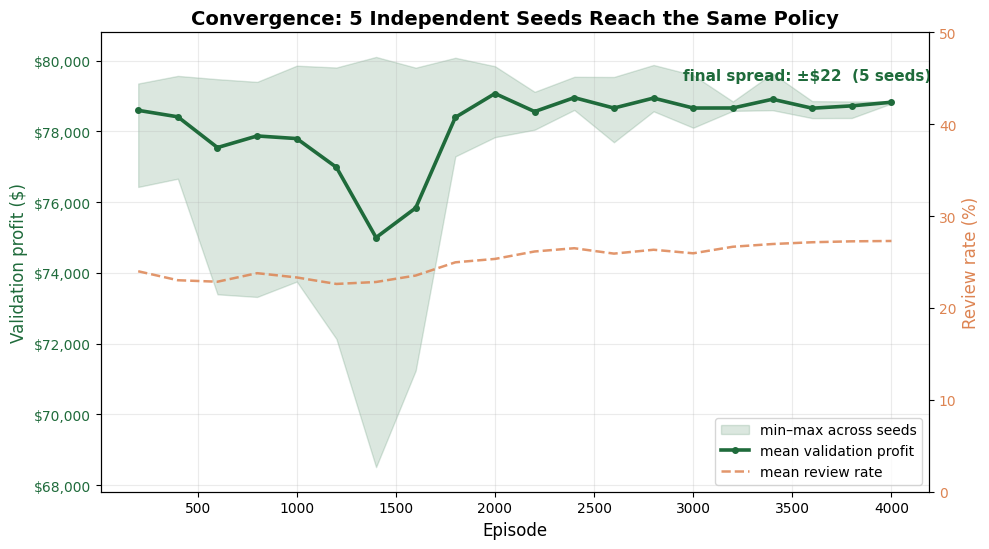

In [81]:
# ── SLIDE 5: RL Layer — Convergence (multi-seed band, single panel) ──
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def load_learning_curve(checkpoint_path, seed=None):
    p = f"{checkpoint_path}_curve.npy"
    if os.path.exists(p):
        arr = np.load(p)
        if arr.ndim == 2 and arr.shape[0] > 0:
            return arr[:, 0], arr[:, 1], arr[:, 2]
    if seed is not None and len(CAB_LEARNING_CURVE.get(seed, [])) > 0:
        arr = np.asarray(CAB_LEARNING_CURVE[seed], dtype=float)
        return arr[:, 0], arr[:, 1], arr[:, 2]
    return None

curves = {}
for sd in CAB_SEEDS:
    c = load_learning_curve(f'{PPO_DIR}/seq_amountcont_seed{sd}', seed=sd)
    if c is not None:
        curves[sd] = c

C_PROFIT, C_REV = '#1F6B3B', '#DD8452'
fig, ax1 = plt.subplots(figsize=(10, 5.6))
ax2 = ax1.twinx()

if len(curves) >= 2:
    common_ep = sorted(set.intersection(*[set(c[0].astype(int)) for c in curves.values()]))
    common_ep = np.array(common_ep, dtype=float)
    P, R = [], []
    for ep, prof, rev in curves.values():
        idx = {int(e): i for i, e in enumerate(ep)}
        P.append([prof[idx[int(e)]] for e in common_ep])
        R.append([rev[idx[int(e)]]  for e in common_ep])
    P, R = np.array(P), np.array(R)

    ax1.fill_between(common_ep, P.min(0), P.max(0), color=C_PROFIT, alpha=0.16,
                     label='min–max across seeds')
    ax1.plot(common_ep, P.mean(0), color=C_PROFIT, lw=2.6, marker='o', ms=4,
             label='mean validation profit')
    ax2.plot(common_ep, 100*R.mean(0), color=C_REV, lw=1.8, ls='--', alpha=0.85,
             label='mean review rate')
    ax2.set_ylim(0, 50)   # fixed scale — do NOT auto-scale (keeps the dip honest)

    band_pad = 0.06 * (P.max() - P.min())
    ax1.set_ylim(P.min() - band_pad, P.max() + band_pad)
    _final = P[:, -1]
    ax1.annotate(f"final spread: ±${_final.std():,.0f}  ({len(curves)} seeds)",
                 xy=(common_ep[-1], P.mean(0)[-1]), xytext=(-150, 16),
                 textcoords='offset points', fontsize=11, fontweight='bold', color=C_PROFIT)
    ax1.set_title(f'Convergence: {len(curves)} Independent Seeds Reach the Same Policy',
                  fontweight='bold', fontsize=14)
else:
    sd = next(iter(curves)); ep, prof, rev = curves[sd]
    ax1.plot(ep, prof, color=C_PROFIT, lw=1.4, marker='o', ms=3, alpha=0.5,
             label=f'val profit (seed {sd})')
    ax1.plot(ep, np.maximum.accumulate(prof), color=C_PROFIT, lw=2.6,
             label='running best (deployed)')
    ax2.plot(ep, 100*rev, color=C_REV, lw=1.8, ls='--', alpha=0.85, label='review rate')
    ax2.set_ylim(0, 50)
    rng = prof.max()-prof.min(); pad = max(rng*0.6, 0.015*np.mean(prof))
    ax1.set_ylim(prof.min()-pad, prof.max()+pad)
    ax1.set_title(f'Convergence (seed {sd})', fontweight='bold', fontsize=14)

ax1.set_xlabel('Episode', fontsize=12)
ax1.set_ylabel('Validation profit ($)', color=C_PROFIT, fontsize=12)
ax1.tick_params(axis='y', labelcolor=C_PROFIT)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.grid(alpha=0.25)
ax2.set_ylabel('Review rate (%)', color=C_REV, fontsize=12)
ax2.tick_params(axis='y', labelcolor=C_REV)
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{PPO_DIR}/rl_convergence.png', dpi=200, bbox_inches='tight')
plt.show()

In [82]:
# ── fraudcore consistency check: notebook vs dashboard, same numbers ──
import json

dash_metrics = json.load(open(os.path.join(PROJECT_ROOT, "dashboard_outputs", "dashboard_metrics.json")))

print("=" * 50)
print("  NOTEBOOK vs DASHBOARD — same fraudcore call")
print("=" * 50)
checks = [
    ("Total profit",  m['total_profit'],   dash_metrics.get('total_profit')),
    ("Review rate",   m['review_rate'],    dash_metrics.get('review_rate')),
    ("Profit Gain",   m['profit_gain'],    dash_metrics.get('profit_gain')),
]
for label, nb_val, dash_val in checks:
    match = "✓ match" if abs(nb_val - dash_val) < 1e-6 else "✗ MISMATCH"
    print(f"  {label:<14} notebook={nb_val:<14,.4f} dashboard={dash_val:<14,.4f}  {match}")

  NOTEBOOK vs DASHBOARD — same fraudcore call
  Total profit   notebook=67,896.7161    dashboard=67,896.7161     ✓ match
  Review rate    notebook=0.2742         dashboard=0.2742          ✓ match
  Profit Gain    notebook=0.8824         dashboard=0.8824          ✓ match


In [83]:
# ── Negative control: same deployed policy, test labels shuffled ──
import numpy as np

rng = np.random.default_rng(42)
shuffled_labels = true_test_labels.copy()
rng.shuffle(shuffled_labels)   # scrambles fraud/legit labels, same scores/amounts/policy

real_metrics = capacity_rollout(
    CapacityAblationEnv(test_probs, true_test_labels, test_amounts,
                         MIN_T_LOW, MAX_T_HIGH, budget_frac=DEPLOY_BUDGET_FRAC,
                         oob='threshold', gate='pressure', k=_k),
    _best_a)

shuffled_metrics = capacity_rollout(
    CapacityAblationEnv(test_probs, shuffled_labels, test_amounts,
                         MIN_T_LOW, MAX_T_HIGH, budget_frac=DEPLOY_BUDGET_FRAC,
                         oob='threshold', gate='pressure', k=_k),
    _best_a)

print(f"Real test set       : ${real_metrics[0]:,.0f}")
print(f"Shuffled labels      : ${shuffled_metrics[0]:,.0f}")
print(f"\nCollapse confirms the deployed policy needs real fraud signal —")
print(f"it isn't exploiting an artifact of the data ordering or split.")

Real test set       : $67,890
Shuffled labels      : $-449,468

Collapse confirms the deployed policy needs real fraud signal —
it isn't exploiting an artifact of the data ordering or split.
